# DELL

## Exogeneous variables to investigate and why

| #  | Variable Name               | Yahoo Ticker         | Relevance                                                                 |
|----|-----------------------------|----------------------|---------------------------------------------------------------------------|
| 1  | Semiconductor ETF           | SMH                  | Dell relies heavily on semiconductors for PCs, servers, and storage; SMH reflects input costs and supply pressure. |
| 2  | NASDAQ Composite            | ^IXIC                | Captures overall tech investor sentiment; Dell stock often moves with NASDAQ trends. |
| 3  | Tech Sector ETF             | XLK                  | Tracks Dell’s peer group (e.g., Apple, Microsoft); useful for benchmarking and sector-level sentiment. |
| 4  | Copper Futures              | HG=F                 | Copper is used in wiring, circuit boards, and PC components; price increases may signal rising production costs. |
| 5  | Crude Oil Futures           | CL=F                 | Affects global shipping and logistics costs; higher oil prices raise Dell’s supply chain expenses. |
| 6  | USD Index                   | DX-Y.NYB             | Dell earns significant revenue internationally; a strong dollar can reduce foreign earnings. |
| 7  | 10-Year Treasury Yield      | ^TNX                 | Impacts interest rates and cost of capital; high yields can slow tech investment and reduce corporate IT spending. |
| 8  | Volatility Index (VIX)      | ^VIX                 | High volatility reduces investor risk appetite and can delay business purchases of IT hardware. |
| 9  | Consumer Discretionary ETF  | XLY                  | Tracks consumer demand for tech products like laptops and monitors - a core Dell segment. |
| 10 | Industrial ETF              | XLI                  | A proxy for business demand; industrial growth often coincides with increased enterprise hardware spending. |
| 11 | Transportation ETF          | IYT                  | Reflects shipping volume and supply chain smoothness - crucial for Dell’s global distribution. |




## Exogeneous variables to investigate and why

| #  | Variable Name               | Yahoo Ticker         | Relevance                                                                 |
|----|-----------------------------|----------------------|---------------------------------------------------------------------------|
| 1  | Semiconductor ETF           | SMH                  | Dell relies heavily on semiconductors for PCs, servers, and storage; SMH reflects input costs and supply pressure. |
| 2  | NASDAQ Composite            | ^IXIC                | Captures overall tech investor sentiment; Dell stock often moves with NASDAQ trends. |
| 3  | Tech Sector ETF             | XLK                  | Tracks Dell’s peer group (e.g., Apple, Microsoft); useful for benchmarking and sector-level sentiment. |
| 4  | Copper Futures              | HG=F                 | Copper is used in wiring, circuit boards, and PC components; price increases may signal rising production costs. |
| 5  | Crude Oil Futures           | CL=F                 | Affects global shipping and logistics costs; higher oil prices raise Dell’s supply chain expenses. |
| 6  | USD Index                   | DX-Y.NYB             | Dell earns significant revenue internationally; a strong dollar can reduce foreign earnings. |
| 7  | 10-Year Treasury Yield      | ^TNX                 | Impacts interest rates and cost of capital; high yields can slow tech investment and reduce corporate IT spending. |
| 8  | Volatility Index (VIX)      | ^VIX                 | High volatility reduces investor risk appetite and can delay business purchases of IT hardware. |
| 9  | Consumer Discretionary ETF  | XLY                  | Tracks consumer demand for tech products like laptops and monitors - a core Dell segment. |
| 10 | Industrial ETF              | XLI                  | A proxy for business demand; industrial growth often coincides with increased enterprise hardware spending. |
| 11 | Transportation ETF          | IYT                  | Reflects shipping volume and supply chain smoothness - crucial for Dell’s global distribution. |




In [4]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
# Suppress common statsmodels warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="No supported index is available")
warnings.filterwarnings("ignore", message="A date index has been provided, but it has no associated frequency")

In [5]:
#installs
#!pip install xgboost
#!pip install keras-tuner --quiet
#!pip install pmdarima

In [6]:
#load libraries
# Core libraries
import os
os.environ['PYTHONHASHSEED'] = "22"
import random
import time
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical and time series analysis
from scipy.stats import spearmanr, pearsonr
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Forecasting
from pmdarima import auto_arima

# Machine learning
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

# Deep learning (LSTM)
import tensorflow as tf
import keras_tuner
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner.tuners import RandomSearch
from keras_tuner import HyperModel

# loading data
#import yfinance as yf

#preventinf memory full error
import gc
from keras import backend as K

In [7]:
#setting random seeed
seed = 22
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

## Basic EDA for DELL and exogeneous variables 

In [50]:
# data doenloaded via google cloab instead
# uploading here

# Load the full combined file
df = pd.read_csv("DELL_exo_data_2025/dell_exo_variables_combined_2025.csv", skiprows = 1, index_col=0, parse_dates=True, date_format="%Y-%m-%d")

# Drop the first row (which is still the leftover 'Date' label)
df = df[df.index != "Date"].copy()

# Convert all columns to numeric (force errors to NaN)
df = df.apply(pd.to_numeric, errors="coerce")

# Check structure
print(df.info())
print(df.head())
print("\nMissing values:\n", df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 123 entries, 2025-01-02 to 2025-05-26
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DELL      121 non-null    float64
 1   SMH       121 non-null    float64
 2   ^IXIC     121 non-null    float64
 3   XLK       121 non-null    float64
 4   HG=F      122 non-null    float64
 5   CL=F      122 non-null    float64
 6   DX-Y.NYB  123 non-null    float64
 7   ^TNX      121 non-null    float64
 8   ^VIX      121 non-null    float64
 9   XLY       121 non-null    float64
 10  XLI       121 non-null    float64
 11  IYT       121 non-null    float64
dtypes: float64(12)
memory usage: 12.5+ KB
None
                  DELL         SMH         ^IXIC         XLK    HG=F  \
Ticker                                                                 
2025-01-02  115.325554  244.789993  19280.789062  231.180283  3.9885   
2025-01-03  118.670624  251.880005  19621.679688  234.947418  4.0395   
20

In [52]:
# sorting by date to be safe
df = df.sort_index()

# doing forward fill, then backfill in case missing value is first value
df = df.ffill().bfill()

# rechecking missing values
print("\nRemaining missing values after fill:\n", df.isna().sum())


Remaining missing values after fill:
 DELL        0
SMH         0
^IXIC       0
XLK         0
HG=F        0
CL=F        0
DX-Y.NYB    0
^TNX        0
^VIX        0
XLY         0
XLI         0
IYT         0
dtype: int64


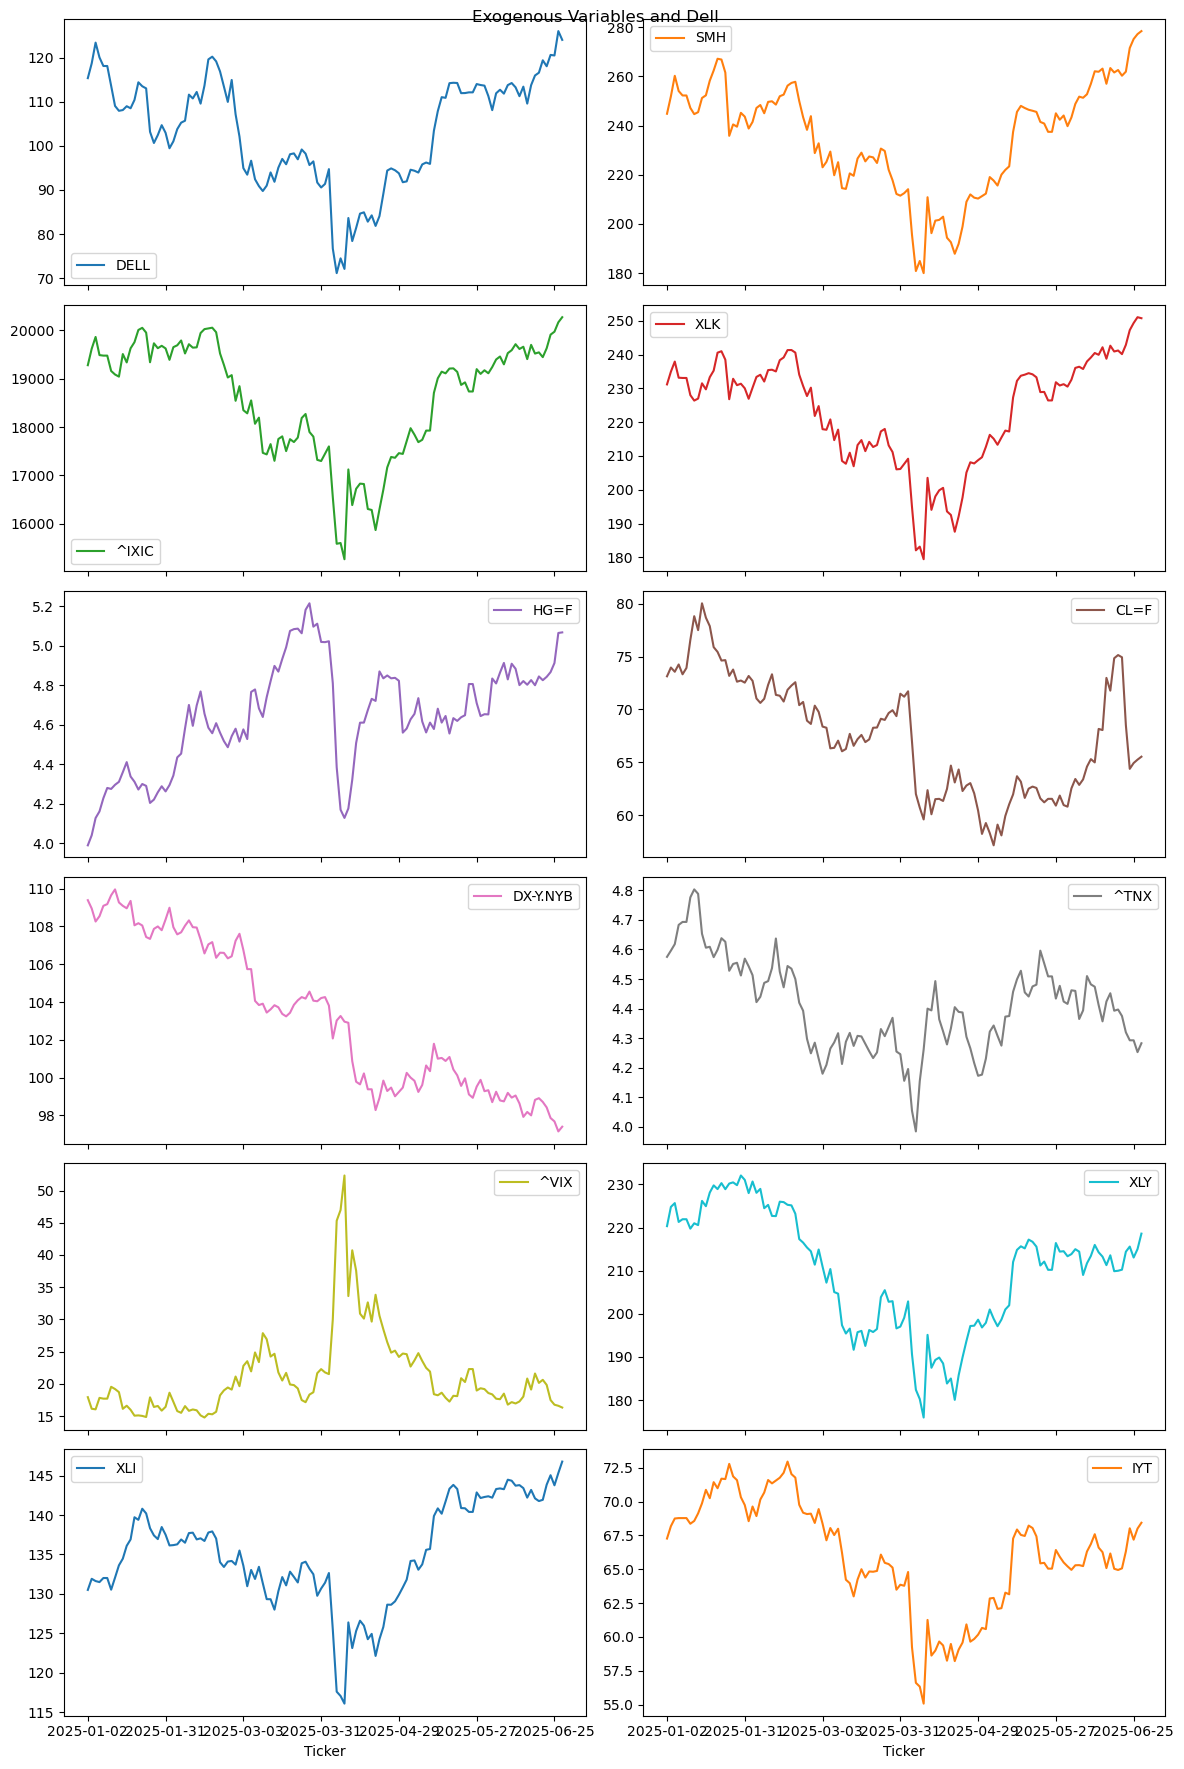

In [54]:
# Basic visual EDA
df.plot(subplots=True, figsize=(12, 18), layout=(6, 2), title="Exogenous Variables and Dell")
plt.tight_layout()
plt.show()

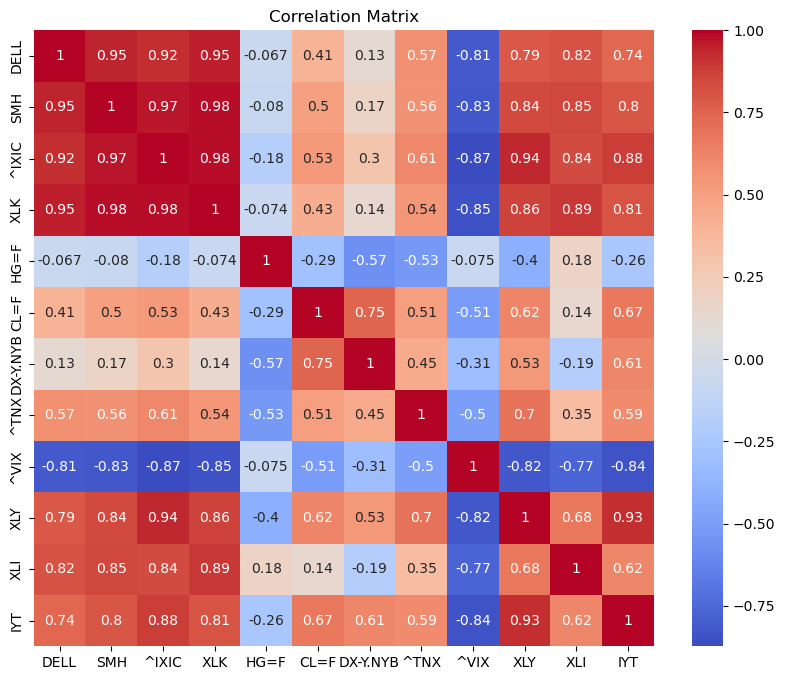

In [55]:
#correlation heatmap
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

These exo variables look promising... Some very different to last time.
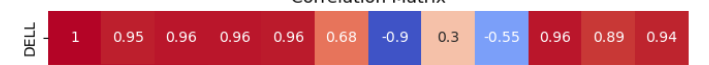

#### Checking for stationality

In [58]:
#ADF tests
#Ho: Time series is non-stationary
#Ha: Time series is stationary 
#for each ticker, if p is less than 0.05 the test was significant and we reject Ho.. thus stationary


# Initialize result list
adf_results = []

# Looping over each column (including Boeing and exogenous variables)
for column in df.columns:
    series = df[column].dropna()
    
    try:
        result = adfuller(series)
        adf_results.append({
            'Variable': column,
            'ADF Statistic': result[0],
            'p-value': result[1],
            'Stationary': 'Yes' if result[1] < 0.05 else 'No'
        })
    except Exception as e:
        adf_results.append({
            'Variable': column,
            'ADF Statistic': None,
            'p-value': None,
            'Stationary': 'Error',
            'Error': str(e)
        })

# converting results to DataFrame
adf_df = pd.DataFrame(adf_results)
print(adf_df)

    Variable  ADF Statistic   p-value Stationary
0       DELL      -1.307268  0.625841         No
1        SMH      -1.043289  0.737150         No
2      ^IXIC      -1.430051  0.567787         No
3        XLK      -1.143062  0.697597         No
4       HG=F      -2.678697  0.077798         No
5       CL=F      -2.173338  0.216064         No
6   DX-Y.NYB      -0.892514  0.790428         No
7       ^TNX      -2.248091  0.189256         No
8       ^VIX      -2.515429  0.111765         No
9        XLY      -1.526756  0.520236         No
10       XLI      -1.225035  0.662735         No
11       IYT      -1.655173  0.454344         No


Need to ensure all are stationary before doing granger tests to avoid getting spurious results, inflated p-values, or invalid inference.

The Granger test assumes:
- Time series are covariance stationary
- constant mean/variance over time


In [61]:
# Getting first difference for all
# making copy of original DataFrame
df_diff = df.copy()

# List of non-stationary series from ADF output
non_stationary = ['DELL', 'SMH', '^IXIC', 'XLK', 'HG=F', 'CL=F', 'DX-Y.NYB', '^TNX','^VIX', 'XLY', 'XLI', 'IYT']
stationary = [] 

# Difference only non-stationary series
df_diff_nonstat = df[non_stationary].diff()

# Drop NaNs from differenced data
df_diff_nonstat = df_diff_nonstat.dropna()

# Slice ^VIX data to match df_diff_nonstat index exactly
df_vix_clean = df.loc[df_diff_nonstat.index, stationary]

# Concatenate differenced and stationary series
df_diff = pd.concat([df_diff_nonstat, df_vix_clean], axis=1)

# Check the final DataFrame
print(df_diff.head())

                DELL       SMH       ^IXIC       XLK    HG=F      CL=F  \
Ticker                                                                   
2025-01-03  3.345070  7.090012  340.890625  3.767136  0.0510  0.830002   
2025-01-06  4.700905  8.350006  243.300781  2.989777  0.0875 -0.400002   
2025-01-07 -3.354973 -6.190018 -375.300781 -4.773682  0.0335  0.690002   
2025-01-08 -1.939743 -1.809998  -10.798828 -0.079727  0.0670 -0.930000   
2025-01-09  0.000000  0.000000    0.000000  0.000000  0.0520  0.599998   

            DX-Y.NYB   ^TNX      ^VIX       XLY       XLI       IYT  
Ticker                                                               
2025-01-03 -0.440002  0.021 -1.800001  4.458221  1.411346  0.914597  
2025-01-06 -0.689995  0.022 -0.089998  0.885681 -0.288239  0.566658  
2025-01-07  0.279999  0.065  1.779999 -4.368652 -0.129196  0.029831  
2025-01-08  0.549995  0.010 -0.119999  0.626923  0.516830  0.000000  
2025-01-09  0.090004  0.000  0.000000  0.000000  0.000000  0.

In [65]:
#checking for stationality again (same hypotheses)

# Initialize result list
adf_results = []

# Using the differenced DataFrame
for column in df_diff.columns:
    series = df_diff[column].dropna()

    try:
        result = adfuller(series)
        adf_results.append({
            'Variable': column,
            'ADF Statistic': result[0],
            'p-value': result[1],
            'Stationary': 'Yes' if result[1] < 0.05 else 'No'
        })
    except Exception as e:
        adf_results.append({
            'Variable': column,
            'ADF Statistic': None,
            'p-value': None,
            'Stationary': 'Error',
            'Error': str(e)
        })

# converting to dataframe and show
adf_df = pd.DataFrame(adf_results)
print(adf_df)

    Variable  ADF Statistic       p-value Stationary
0       DELL     -10.469335  1.296578e-18        Yes
1        SMH      -4.842149  4.513945e-05        Yes
2      ^IXIC      -6.464998  1.412450e-08        Yes
3        XLK      -6.405272  1.950279e-08        Yes
4       HG=F      -8.613728  6.373035e-14        Yes
5       CL=F      -6.168261  6.904913e-08        Yes
6   DX-Y.NYB     -11.605909  2.581509e-21        Yes
7       ^TNX     -10.252717  4.442272e-18        Yes
8       ^VIX     -12.319841  6.790103e-23        Yes
9        XLY     -12.339378  6.168016e-23        Yes
10       XLI      -6.807223  2.161299e-09        Yes
11       IYT     -12.090578  2.127272e-22        Yes


### Granger Causality test 
Looking for strongest candidates for exogeneous variables for this period

In [68]:
# Setting max lag for Granger test
MAX_LAG = 30 #no causality shown for anyvariable at max lag 5

# Initialize result list
granger_results = []

# Looping through each exogenous variable
for exo_var in df_diff.columns:
    if exo_var == 'DELL':
        continue  # skip dell

    try:
        # getting correct part of DataFrame for this test 
        test_data = df_diff[['DELL', exo_var]].dropna()

        # Granger causality test
        result = grangercausalitytests(test_data, maxlag=MAX_LAG, verbose=False)

        # getting p-values for each lag
        p_values = [round(result[i + 1][0]['ssr_ftest'][1], 4) for i in range(MAX_LAG)]

        # storing min p-value and associated variable
        granger_results.append({
            'Exogenous Variable': exo_var,
            'Min p-value': min(p_values),
            'Lag with Min p': p_values.index(min(p_values)) + 1,
            'Causal (p < 0.05)': 'Yes' if min(p_values) < 0.05 else 'No'
        })

    except Exception as e:
        granger_results.append({
            'Exogenous Variable': exo_var,
            'Min p-value': None,
            'Lag with Min p': None,
            'Causal (p < 0.05)': 'Error',
            'Error': str(e)
        })

# Showing results
granger_df = pd.DataFrame(granger_results)
print(granger_df.sort_values("Min p-value"))

   Exogenous Variable  Min p-value  Lag with Min p Causal (p < 0.05)
7                ^VIX       0.1056               1                No
2                 XLK       0.1261              10                No
4                CL=F       0.1369               4                No
6                ^TNX       0.1418               7                No
1               ^IXIC       0.1805              10                No
10                IYT       0.1979               1                No
8                 XLY       0.2149               1                No
0                 SMH       0.2536              10                No
9                 XLI       0.3487               1                No
3                HG=F       0.3543              13                No
5            DX-Y.NYB       0.7191              24                No


In [69]:
#checking plots

# Set higher max lag for Granger test
MAX_LAG = 30

# Initialize result list
granger_results_30 = []

# Loop through each exogenous variable
for exo_var in df_diff.columns:
    if exo_var == 'DELL':
        continue  # Skipping the dependent variable

    try:
        # Prepare input data
        test_data = df_diff[['DELL', exo_var]].dropna()

        # Run Granger causality test
        result = grangercausalitytests(test_data, maxlag=MAX_LAG, verbose=False)

        # Extract p-values across lags
        p_values = [round(result[i + 1][0]['ssr_ftest'][1], 4) for i in range(MAX_LAG)]

        # Store the lowest p-value and associated lag
        granger_results_30.append({
            'Exogenous Variable': exo_var,
            'Min p-value': min(p_values),
            'Lag with Min p': p_values.index(min(p_values)) + 1,
            'Causal (p < 0.05)': 'Yes' if min(p_values) < 0.05 else 'No',
            'All p-values': p_values #storing to plot later
        })

    except Exception as e:
        granger_results_20.append({
            'Exogenous Variable': exo_var,
            'Min p-value': None,
            'Lag with Min p': None,
            'Causal (p < 0.05)': 'Error',
            'Error': str(e)
        })

# Display results
granger_df_30 = pd.DataFrame(granger_results_30)
print(granger_df_30.sort_values("Min p-value"))

   Exogenous Variable  Min p-value  Lag with Min p Causal (p < 0.05)  \
7                ^VIX       0.1056               1                No   
2                 XLK       0.1261              10                No   
4                CL=F       0.1369               4                No   
6                ^TNX       0.1418               7                No   
1               ^IXIC       0.1805              10                No   
10                IYT       0.1979               1                No   
8                 XLY       0.2149               1                No   
0                 SMH       0.2536              10                No   
9                 XLI       0.3487               1                No   
3                HG=F       0.3543              13                No   
5            DX-Y.NYB       0.7191              24                No   

                                         All p-values  
7   [0.1056, 0.2688, 0.3633, 0.527, 0.5875, 0.6926...  
2   [0.9368, 0.6665, 0.

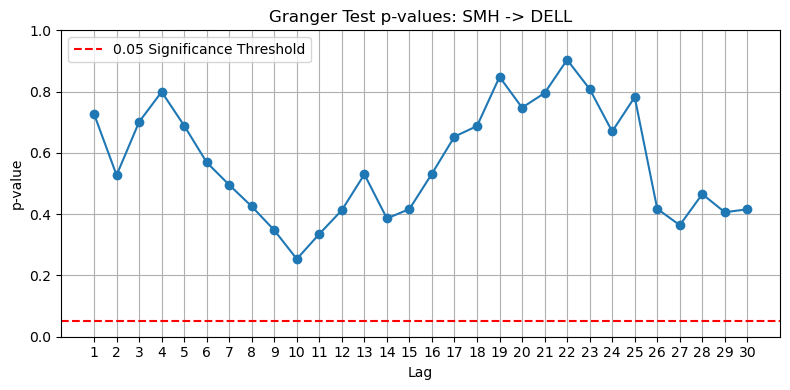

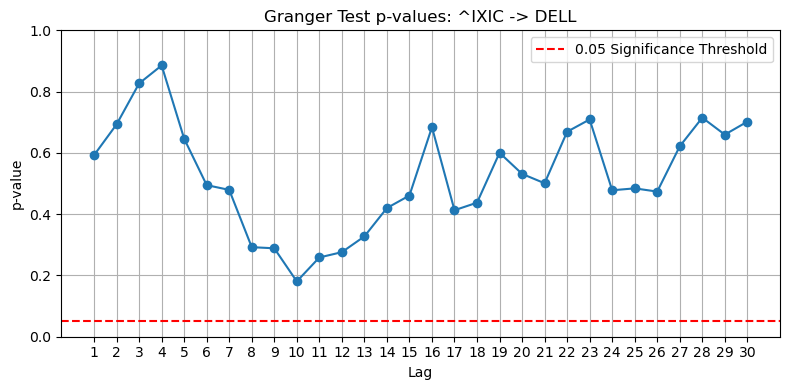

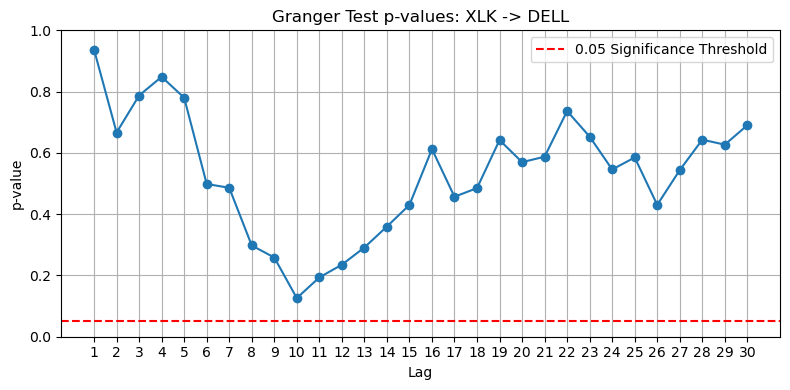

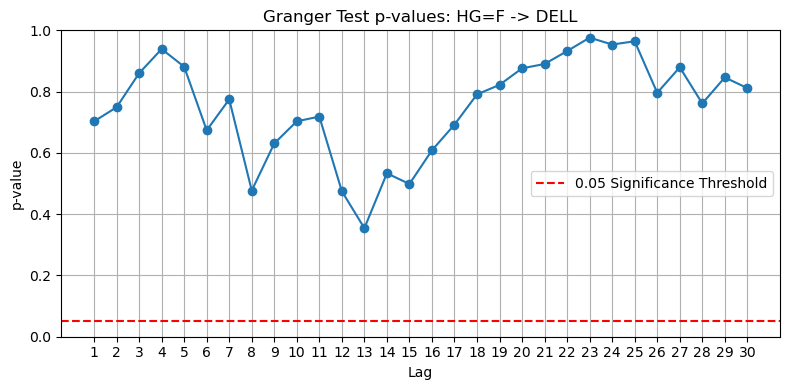

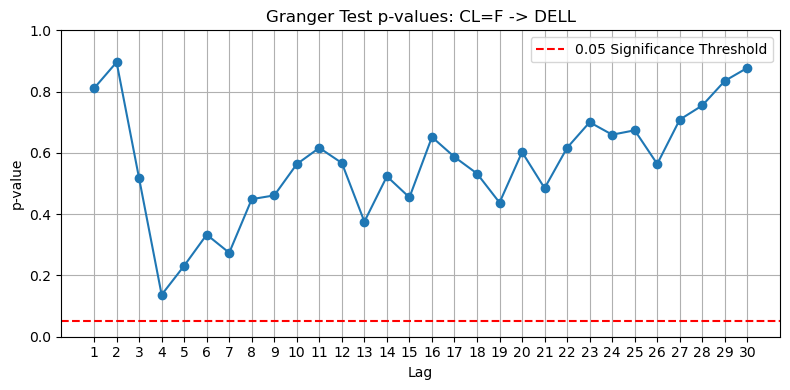

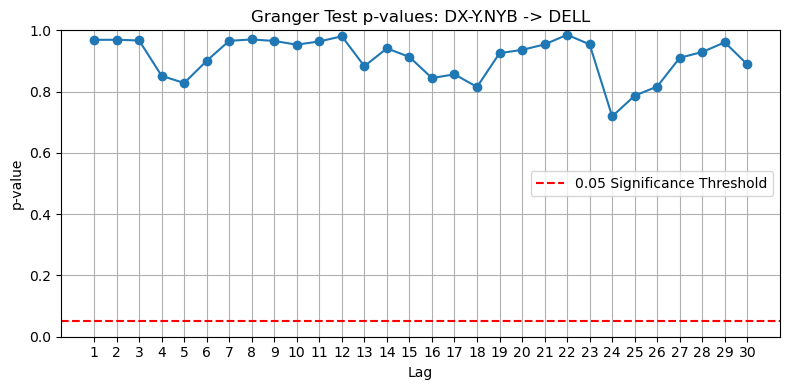

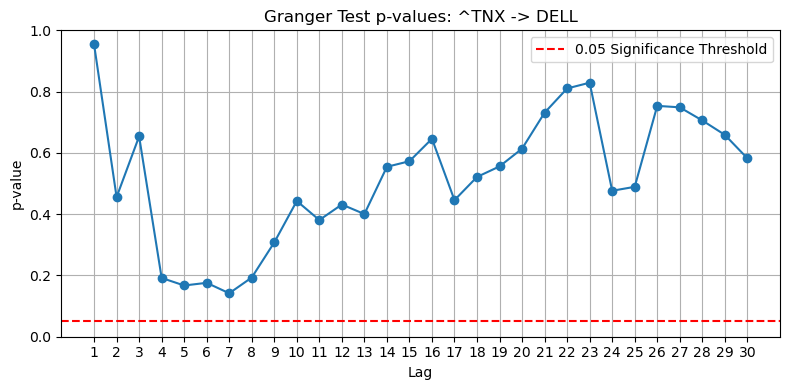

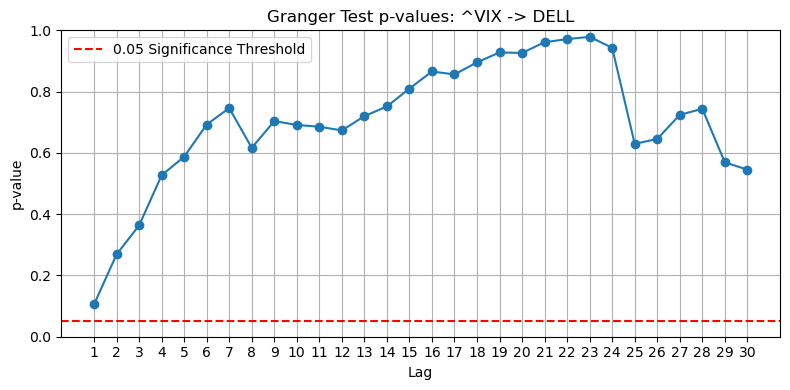

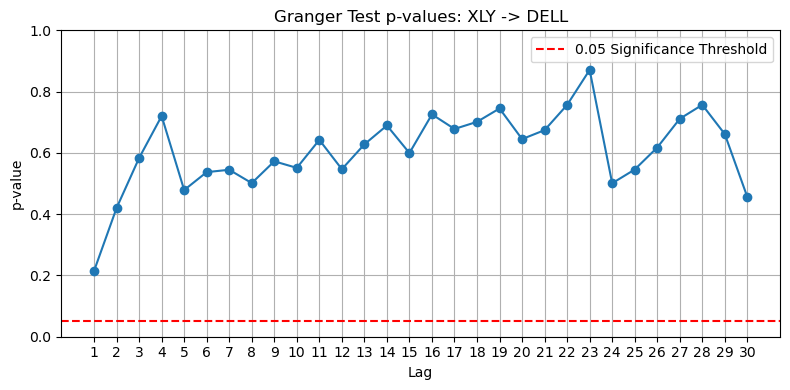

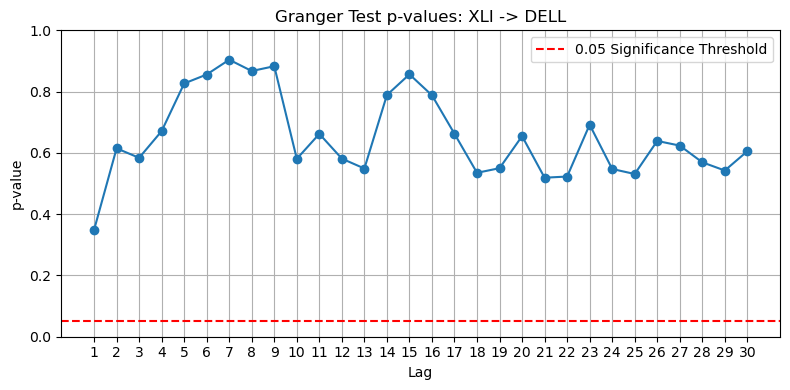

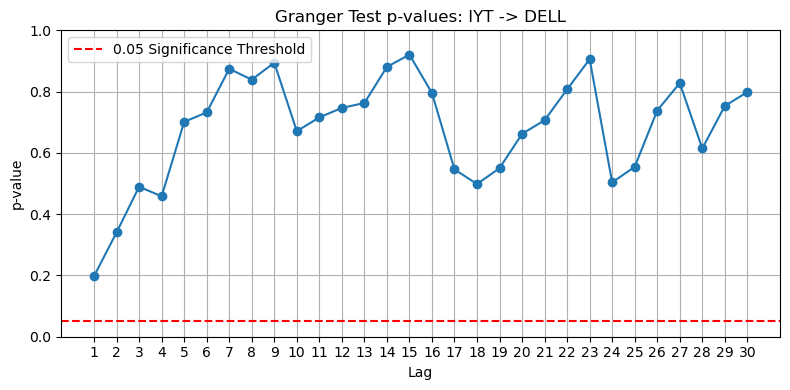

In [71]:
# Plot p-values across lags for each exogenous variable
for result in granger_results_30:
    if 'All p-values' not in result:
        continue  # Skip if p-values not stored due to error

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, MAX_LAG + 1), result['All p-values'], marker='o')
    plt.axhline(y=0.05, color='red', linestyle='--', label='0.05 Significance Threshold')
    plt.title(f"Granger Test p-values: {result['Exogenous Variable']} -> DELL")
    plt.xlabel("Lag")
    plt.ylabel("p-value")
    plt.xticks(range(1, MAX_LAG + 1))
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [72]:
# Print the full p-values from the correct DataFrame
for idx, row in granger_df_30.iterrows():
    print(f"{row['Exogenous Variable']} → p-values: {row.get('All p-values', 'Missing')}")


SMH → p-values: [0.7267, 0.5273, 0.7011, 0.7992, 0.6889, 0.569, 0.4955, 0.4252, 0.3476, 0.2536, 0.3354, 0.4131, 0.53, 0.386, 0.4168, 0.5321, 0.6532, 0.6876, 0.848, 0.7477, 0.7952, 0.9039, 0.8084, 0.6699, 0.7821, 0.4175, 0.3641, 0.4655, 0.4063, 0.4159]
^IXIC → p-values: [0.5926, 0.6931, 0.8267, 0.8854, 0.6462, 0.4948, 0.4792, 0.2923, 0.2886, 0.1805, 0.2587, 0.276, 0.3274, 0.42, 0.4609, 0.6839, 0.4129, 0.4375, 0.6003, 0.5315, 0.5009, 0.669, 0.7091, 0.478, 0.4842, 0.4737, 0.6215, 0.7149, 0.6596, 0.7019]
XLK → p-values: [0.9368, 0.6665, 0.7873, 0.8483, 0.78, 0.4985, 0.4861, 0.2978, 0.2585, 0.1261, 0.1936, 0.235, 0.2912, 0.3596, 0.4302, 0.6123, 0.4569, 0.485, 0.6419, 0.5697, 0.5875, 0.7365, 0.653, 0.5459, 0.585, 0.4303, 0.5438, 0.6431, 0.6269, 0.6903]
HG=F → p-values: [0.7028, 0.749, 0.86, 0.939, 0.8812, 0.6736, 0.7748, 0.477, 0.6309, 0.7031, 0.7185, 0.4748, 0.3543, 0.5334, 0.4985, 0.6085, 0.6923, 0.791, 0.822, 0.876, 0.8902, 0.9323, 0.9761, 0.9537, 0.9643, 0.7961, 0.8795, 0.7613, 0.8463, 0

None of these exo variables are showing significance... but just to keep consistency in my methodology I am going to still include what appear to be the best performing ones in my SARIMAX models 
- CL=F at lag 4 (cluster of low values around lags 4-6)
- ^TNX at lag 7 (some moderately low values around lags 3-8)
- ^VIX at lag 1... lowest across all variables

## Building ARIMA model

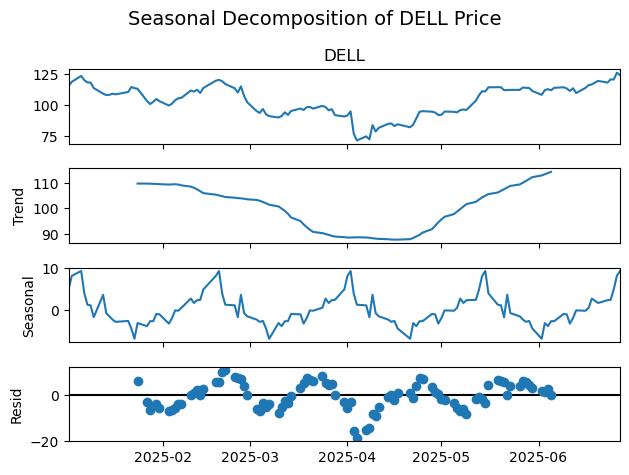

In [76]:
#already know it needs to be differenced once for stationlity
#looking at seasonality

# Extracting DELL price series
dell_series = df['DELL'].dropna()
dell_series.index = pd.to_datetime(dell_series.index)

# Try daily seasonality 
decomposition = seasonal_decompose(dell_series, model='additive', period=30)
decomposition.plot()
plt.suptitle('Seasonal Decomposition of DELL Price', fontsize=14)
plt.tight_layout()
plt.show()

Data’s on business days from Jan to end of June 2025, so we’re looking at ~125 points total. The trend shows a steady drop from Jan through March, followed by a gradual recovery starting in April — so differencing to remove that non-stationarity makes sense (which i’ve already done).

What stands out more here is the seasonality. It’s not textbook smooth, but there’s a reasonably consistent wave, with peaks roughly every 20–25 business days. This aligns with the idea of monthly seasonality, so definitely worth testing SARIMA models with seasonal periods like [21] or [30]. Also worth trialing [5] to cover any weekly structure that might not be visually obvious.

The residuals look fairly noisy and random, which is exactly what we want after decomposition... no obvious structure left behind.

So overall:

- Differencing: Yes - clear non-stationary trend, 1st difference appropriate
- Seasonality: Some repeating signal, not perfect but enough to justify SARIMA with seasonal orders like (P,D,Q)[5], [21], or [30]
- Residuals: Good... no strong leftover structure

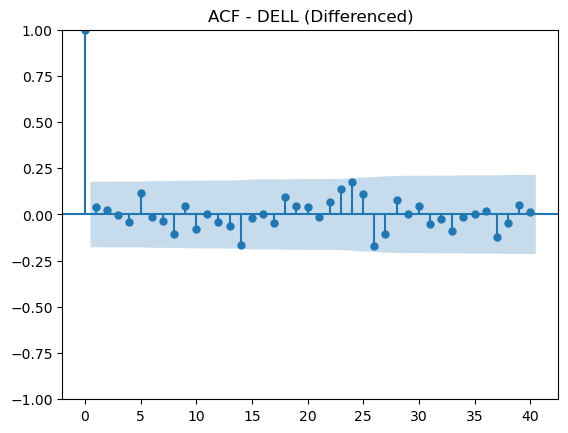

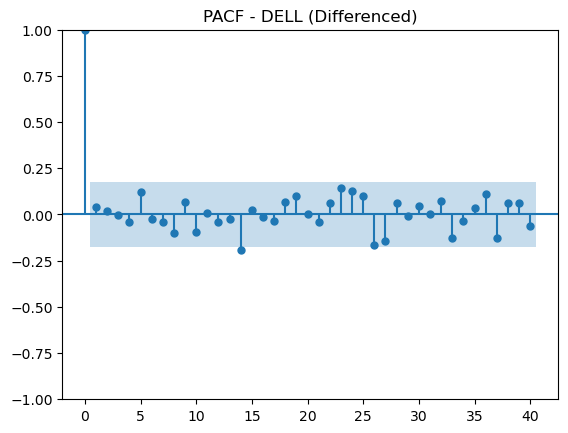

In [78]:
#ACF PACF plots
# First difference
dell_diff = dell_series.diff().dropna()

# Plot ACF & PACF
plot_acf(dell_diff, lags=40)
plt.title('ACF - DELL (Differenced)')
plt.show()

plot_pacf(dell_diff, lags=40)
plt.title('PACF - DELL (Differenced)')
plt.show()

Looks like (1,1,1) could be best. Will use auto arima to see if this is confirmed

In [82]:
auto_model = auto_arima(dell_series, seasonal=True, m=20,
                        stepwise=True, trace=True,
                        suppress_warnings=True, max_order=10)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[20] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(0,1,0)(0,0,0)[20] intercept   : AIC=659.219, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[20] intercept   : AIC=662.793, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[20] intercept   : AIC=662.801, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[20]             : AIC=657.268, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[20] intercept   : AIC=661.008, Time=0.05 sec
 ARIMA(0,1,0)(0,0,1)[20] intercept   : AIC=661.012, Time=0.05 sec
 ARIMA(0,1,0)(1,0,1)[20] intercept   : AIC=662.994, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[20] intercept   : AIC=660.992, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[20] intercept   : AIC=661.001, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[20] intercept   : AIC=662.953, Time=0.37 sec

Best model:  ARIMA(0,1,0)(0,0,0)[20]          
Total fit time: 1.347 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  123

In [83]:
auto_model = auto_arima(dell_series, seasonal=False, m=30,
                        stepwise=True, trace=True,
                        suppress_warnings=True, max_order=10)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.99 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=659.219, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=660.992, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=661.001, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=657.268, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=662.953, Time=0.18 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.235 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  123
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -327.634
Date:                Wed, 06 Aug 2025   AIC                            657.268
Time:                        01:11:14   BIC                            660.072
Sample:                             0   HQIC                           658.407
                    

In [85]:
#trying a grid search to see if any other seasonality is sensile
def evaluate_sarima_configs(y, order_list, seasonal_order_list, seasonal_period, forecast_horizon=7):
    results = []

    train = y.iloc[:-forecast_horizon]
    test = y.iloc[-forecast_horizon:]

    for order in order_list:
        for seasonal in seasonal_order_list:
            seasonal_order = (seasonal[0], seasonal[1], seasonal[2], seasonal_period)
            try:
                model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                                enforce_stationarity=False, enforce_invertibility=False)
                model_fit = model.fit(disp=False)

                forecast = model_fit.forecast(steps=forecast_horizon)

                rmse = np.sqrt(mean_squared_error(test, forecast))
                mae = mean_absolute_error(test, forecast)

                results.append({
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'RMSE': round(rmse, 2),
                    'MAE': round(mae, 2),
                    'AIC': round(model_fit.aic, 2)
                })

            except Exception as e:
                results.append({
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'RMSE': None,
                    'MAE': None,
                    'AIC': None,
                    'Error': str(e)
                })

    return pd.DataFrame(results)

In [87]:
order_list = [(0, 1, 0), (1, 1, 1), (0, 1, 1)]
seasonal_order_list = [(1, 0, 0), (0, 0, 1), (1, 0, 1)]

for m in [5, 20, 21, 22, 30]:
    print(f"Evaluating for seasonal period: {m}")
    results = evaluate_sarima_configs(dell_series, order_list, seasonal_order_list, seasonal_period=m)
    print(results.sort_values('RMSE'))

Evaluating for seasonal period: 5
       order seasonal_order  RMSE   MAE     AIC
4  (1, 1, 1)   (0, 0, 1, 5)  5.26  4.54  587.63
3  (1, 1, 1)   (1, 0, 0, 5)  5.28  4.49  593.72
7  (0, 1, 1)   (0, 0, 1, 5)  5.38  4.64  585.92
6  (0, 1, 1)   (1, 0, 0, 5)  5.41  4.61  599.00
1  (0, 1, 0)   (0, 0, 1, 5)  5.49  4.75  590.32
0  (0, 1, 0)   (1, 0, 0, 5)  5.52  4.73  597.40
5  (1, 1, 1)   (1, 0, 1, 5)  5.55  4.82  587.84
8  (0, 1, 1)   (1, 0, 1, 5)  5.64  4.90  586.63
2  (0, 1, 0)   (1, 0, 1, 5)  5.86  5.11  590.10
Evaluating for seasonal period: 20
       order seasonal_order  RMSE   MAE     AIC
3  (1, 1, 1)  (1, 0, 0, 20)  5.69  4.83  517.42
6  (0, 1, 1)  (1, 0, 0, 20)  5.69  4.82  520.86
0  (0, 1, 0)  (1, 0, 0, 20)  5.71  4.85  518.87
4  (1, 1, 1)  (0, 0, 1, 20)  5.76  4.93  512.54
7  (0, 1, 1)  (0, 0, 1, 20)  5.78  4.94  510.55
1  (0, 1, 0)  (0, 0, 1, 20)  5.81  4.99  513.10
5  (1, 1, 1)  (1, 0, 1, 20)  5.83  5.02  513.97
8  (0, 1, 1)  (1, 0, 1, 20)  5.93  5.13  512.10
2  (0, 1, 0)  (1, 0

Going to use (1,1,1) and (0,1,0) from auto arima... and in seasonality (1,1,1) (1,0,0,21)to compare
May use (0,1,1) and (1,1,0) too

I will choose best model based on evealuations and then continue with that model for my exogeneous variables

## Gettning results for Baseline models (no exo variables)
- No seasonality -ARIMAX- (0, 1, 0), (1,1,1) (0,1,1) (1,1,0)
- With seasonality -SARIMAX- (1, 1, 1) seasonality: (1, 0, 0, 21)

In [90]:
#define models

def mean_absolute_percentage_error(y_true, y_pred):
    """Avoids division by zero issues."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rolling_forecast_baseline_model(
    df,
    model_order,
    forecast_horizons,
    train_end_date,
    test_start_date,
    output_csv_path,
    seasonal_order=None
):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.asfreq('B')
    series = df['DELL'].dropna()

    train = series[series.index <= train_end_date]
    test = series[series.index >= test_start_date]

    all_metrics = []

    for h in forecast_horizons:
        preds, actuals, dates = [], [], []

        for i in range(0, len(test) - h + 1):
            train_series = pd.concat([train, test.iloc[:i]])

            try:
                model = SARIMAX(
                    train_series,
                    order=model_order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                results = model.fit(disp=False)
                forecast = results.get_forecast(steps=h)
                pred = forecast.predicted_mean.iloc[-1]
                actual = test.iloc[i + h - 1]

                if not np.isnan(pred) and not np.isnan(actual):
                    preds.append(pred)
                    actuals.append(actual)
                    dates.append(test.index[i + h - 1])
            except Exception as e:
                continue

        if preds:
            rmse = np.sqrt(mean_squared_error(actuals, preds))
            mae = mean_absolute_error(actuals, preds)
            mape = mean_absolute_percentage_error(actuals, preds)
            model_name = f"SARIMA{model_order}" if seasonal_order else f"ARIMA{model_order}"
            all_metrics.append({
                'model': model_name,
                'seasonal': bool(seasonal_order),
                'horizon': h,
                'rmse': rmse,
                'mae': mae,
                'mape': mape
            })

            # Print results
            print(f"\n{model_name} {'(Seasonal)' if seasonal_order else ''} - Horizon {h}")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE:  {mae:.2f}")
            print(f"  MAPE: {mape:.2f}%")

            # Plot
            plt.figure(figsize=(10, 4))
            plt.plot(dates, actuals, label='Actual')
            plt.plot(dates, preds, label='Forecast')
            plt.title(f"{model_name} {'(Seasonal)' if seasonal_order else ''} - {h}-Day Horizon")
            plt.xlabel('Date')
            plt.ylabel('DELL Close Price')
            plt.legend()
            plt.tight_layout()
            plt.show()

    df_metrics = pd.DataFrame(all_metrics)

    if not df_metrics.empty:
        if not os.path.exists(output_csv_path):
            df_metrics.to_csv(output_csv_path, index=False)
        else:
            df_metrics.to_csv(output_csv_path, mode='a', header=False, index=False)
        print(f"\n Saved metrics to {output_csv_path}")

    return df_metrics


ARIMA(0, 1, 0)  - Horizon 1
  RMSE: 2.44
  MAE:  2.00
  MAPE: 1.74%


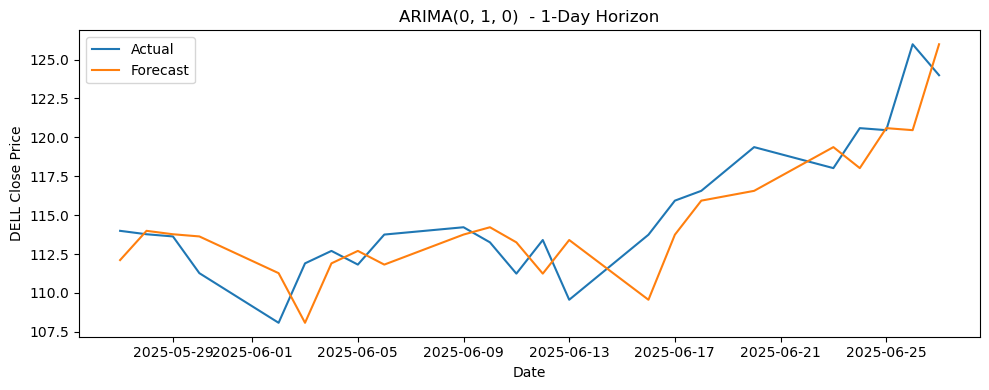


ARIMA(0, 1, 0)  - Horizon 3
  RMSE: 3.65
  MAE:  3.09
  MAPE: 2.66%


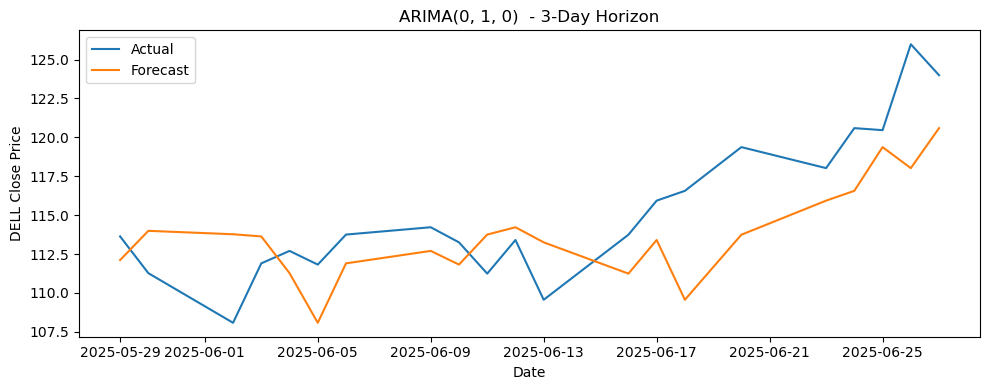


ARIMA(0, 1, 0)  - Horizon 7
  RMSE: 5.50
  MAE:  4.17
  MAPE: 3.50%


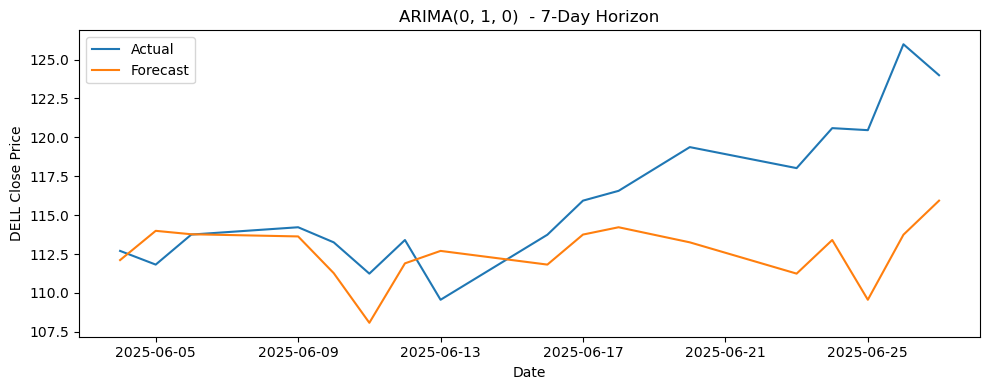


 Saved metrics to baseline_metrics_2025_dell.csv

ARIMA(1, 1, 1)  - Horizon 1
  RMSE: 2.48
  MAE:  2.03
  MAPE: 1.76%


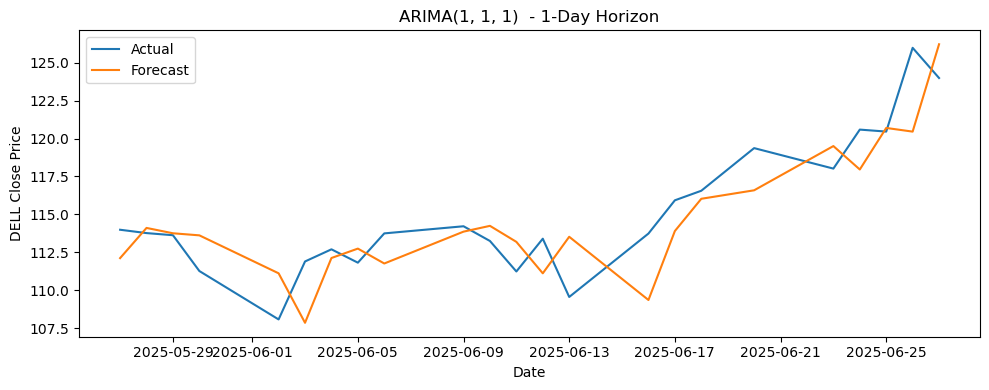


ARIMA(1, 1, 1)  - Horizon 3
  RMSE: 3.67
  MAE:  3.09
  MAPE: 2.67%


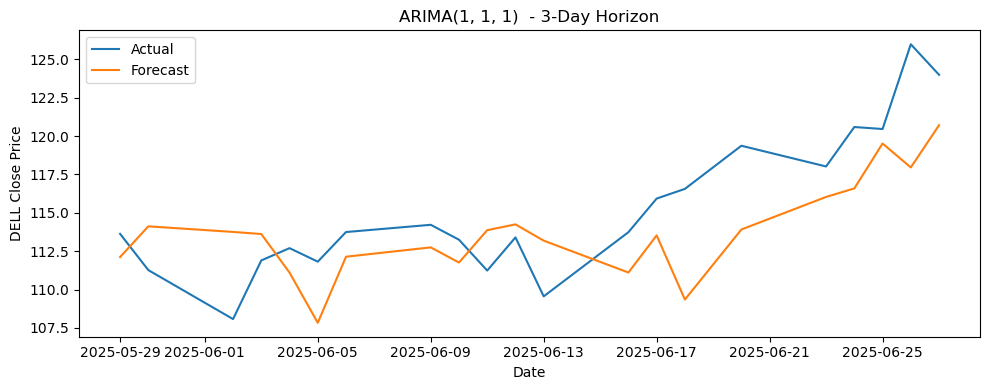


ARIMA(1, 1, 1)  - Horizon 7
  RMSE: 5.51
  MAE:  4.18
  MAPE: 3.51%


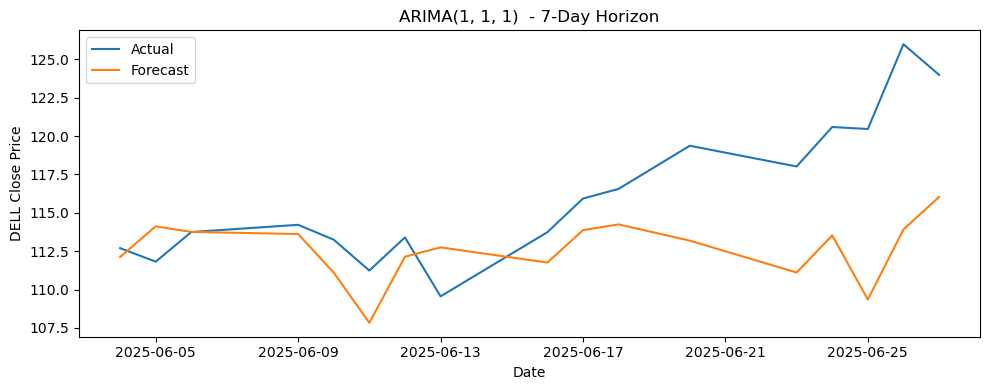


 Saved metrics to baseline_metrics_2025_dell.csv

ARIMA(0, 1, 1)  - Horizon 1
  RMSE: 2.48
  MAE:  2.02
  MAPE: 1.76%


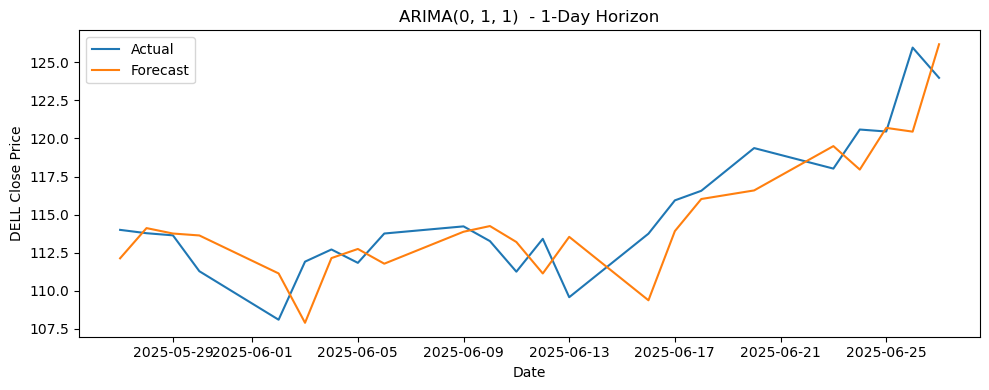


ARIMA(0, 1, 1)  - Horizon 3
  RMSE: 3.66
  MAE:  3.09
  MAPE: 2.67%


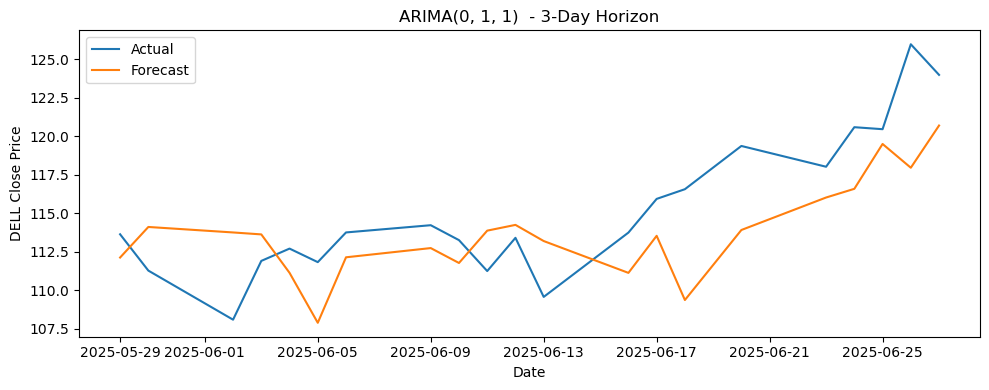


ARIMA(0, 1, 1)  - Horizon 7
  RMSE: 5.50
  MAE:  4.18
  MAPE: 3.51%


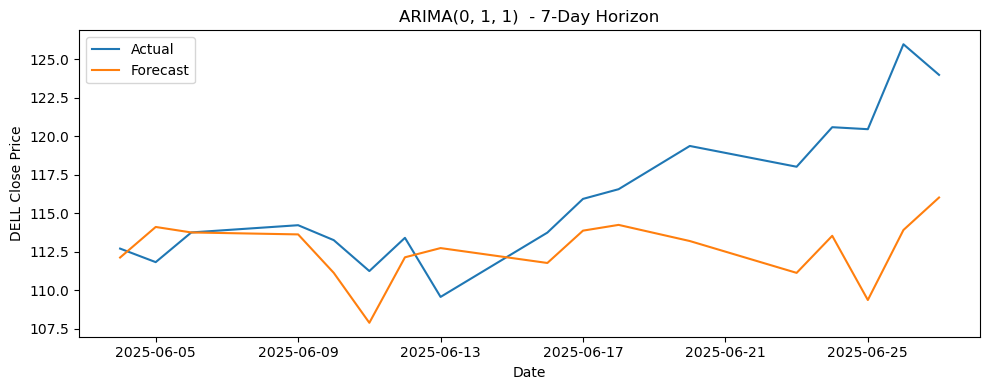


 Saved metrics to baseline_metrics_2025_dell.csv

ARIMA(1, 1, 0)  - Horizon 1
  RMSE: 2.49
  MAE:  2.03
  MAPE: 1.76%


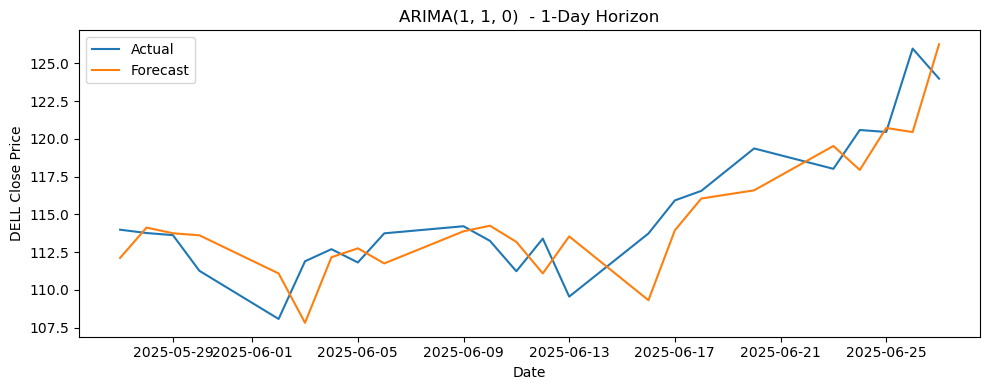


ARIMA(1, 1, 0)  - Horizon 3
  RMSE: 3.67
  MAE:  3.09
  MAPE: 2.67%


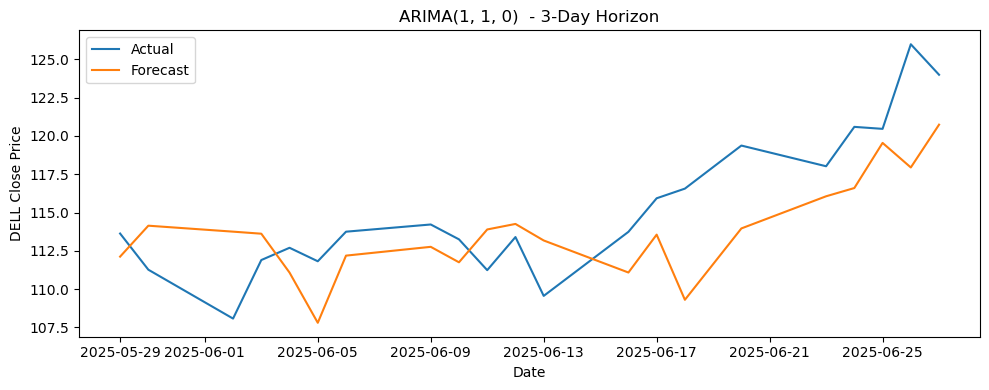


ARIMA(1, 1, 0)  - Horizon 7
  RMSE: 5.51
  MAE:  4.18
  MAPE: 3.51%


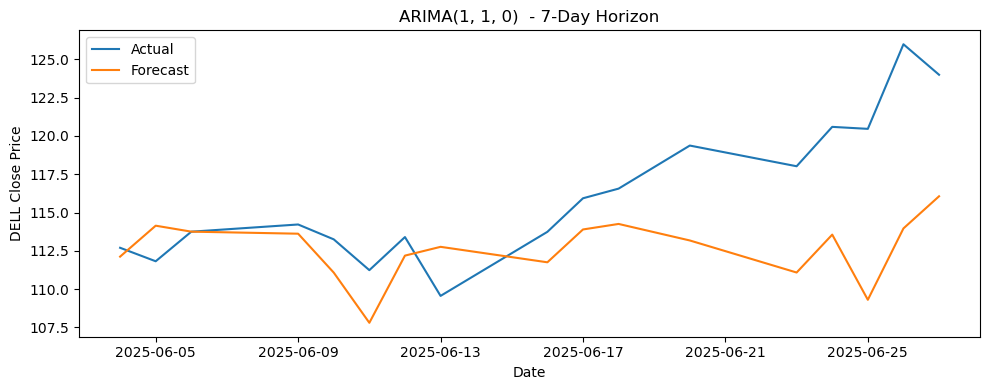


 Saved metrics to baseline_metrics_2025_dell.csv

SARIMA(1, 1, 1) (Seasonal) - Horizon 1
  RMSE: 2.48
  MAE:  2.05
  MAPE: 1.78%


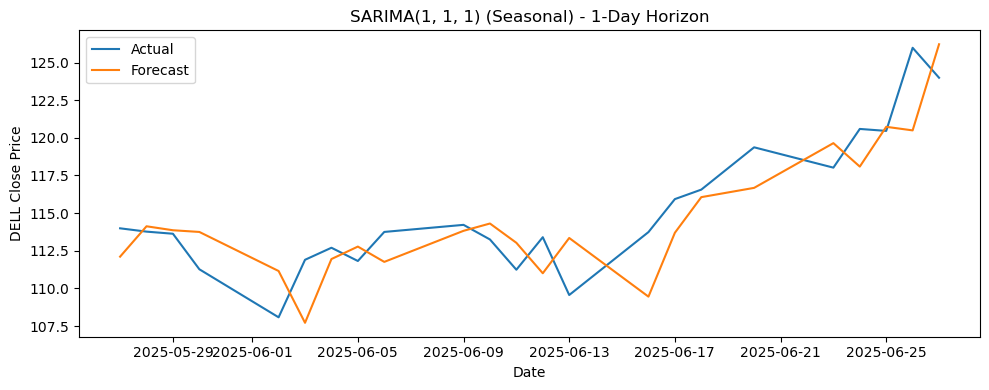


SARIMA(1, 1, 1) (Seasonal) - Horizon 3
  RMSE: 3.69
  MAE:  3.09
  MAPE: 2.67%


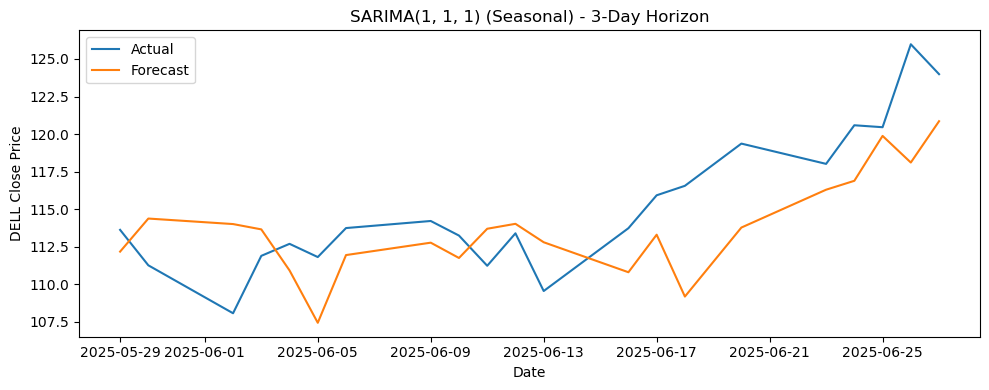


SARIMA(1, 1, 1) (Seasonal) - Horizon 7
  RMSE: 5.66
  MAE:  4.42
  MAPE: 3.71%


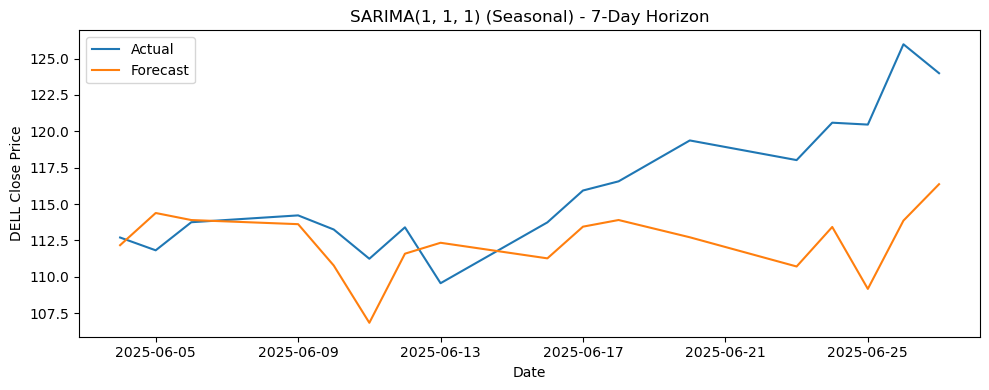


 Saved metrics to baseline_metrics_2025_dell.csv


In [92]:
#running baseline functions
forecast_horizons = [1, 3, 7]
train_end = "2025-05-23"  # 80 20 split
test_start = "2025-05-27" 

# ARIMA(0,1,0) - baseline non-seasonal
baseline_arima_010 = rolling_forecast_baseline_model(
    df=df,
    model_order=(0, 1, 0),
    forecast_horizons=forecast_horizons,
    train_end_date=train_end,
    test_start_date=test_start,
    output_csv_path="baseline_metrics_2025_dell.csv",
    seasonal_order=None
)
# ARIMA(1,1,1) - baseline non-seasonal
baseline_arima_111 = rolling_forecast_baseline_model(
    df=df,
    model_order=(1, 1, 1),
    forecast_horizons=forecast_horizons,
    train_end_date=train_end,
    test_start_date=test_start,
    output_csv_path="baseline_metrics_2025_dell.csv",
    seasonal_order=None
)
# ARIMA(0,1,1) - baseline non-seasonal
baseline_arima_011 = rolling_forecast_baseline_model(
    df=df,
    model_order=(0, 1, 1),
    forecast_horizons=forecast_horizons,
    train_end_date=train_end,
    test_start_date=test_start,
    output_csv_path="baseline_metrics_2025_dell.csv",
    seasonal_order=None
)
# ARIMA(1,1,0) - baseline non-seasonal
baseline_arima_110 = rolling_forecast_baseline_model(
    df=df,
    model_order=(1, 1, 0),
    forecast_horizons=forecast_horizons,
    train_end_date=train_end,
    test_start_date=test_start,
    output_csv_path="baseline_metrics_2025_dell.csv",
    seasonal_order=None
)
# Seasonal ARIMA(1,1,1)(1,0,0)[21] - baseline seasonal
baseline_seasonal = rolling_forecast_baseline_model(
    df=df,
    model_order=(1, 1, 1),
    forecast_horizons=forecast_horizons,
    train_end_date=train_end,
    test_start_date=test_start,
    output_csv_path="baseline_metrics_2025_dell.csv",
    seasonal_order=(1, 0, 0, 21)
)

### Using exo variables with ARIMA
No successful causality but going to still test:
- CL=f, (lag4)
- ^TNX (lag 7)
- ^VIX (lag 1)
to keep up methology consistency and becasue these variables were the "best of a bad lot"

In [96]:
# Define sensible lag choices
exog_lags = {
    'CL=F': 4,
    '^TNX': 7,
    '^VIX': 1,
}

# CHOOSE which to use in this cell
exog_vars = exog_lags  # or exog_lags_best

### Testing grouped variable's impact on ARIMAX model

In [98]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rolling_forecast_sarimax_with_metrics(
    target_df,
    exog_df,
    exog_lags,
    model_order,
    forecast_horizons,
    train_end_date,
    test_start_date,
    output_csv_path,
    seasonal_order=None,
    plot=True,
    append_csv=True
):
    # Align indices
    target_df = target_df.copy()
    target_df.index = pd.to_datetime(target_df.index)
    target_df = target_df.asfreq('B')

    exog_df = exog_df.copy()
    exog_df.index = pd.to_datetime(exog_df.index)
    exog_df = exog_df.asfreq('B')

    # Generate lagged exogenous variables
    for var, lag in exog_lags.items():
        exog_df[f'{var}_lag{lag}'] = exog_df[var].shift(lag)

    exog_df.dropna(inplace=True)

    exog_cols = [f'{var}_lag{lag}' for var, lag in exog_lags.items()]

    # Align target to the lagged exog index
    target = target_df.loc[exog_df.index]
    exog = exog_df[exog_cols]

    train_y = target[target.index <= train_end_date]
    test_y = target[target.index >= test_start_date]
    train_X = exog[exog.index <= train_end_date]
    test_X = exog[exog.index >= test_start_date]

    all_metrics = []

    for h in forecast_horizons:
        preds, actuals, dates = [], [], []

        for i in range(0, len(test_y) - h + 1):
            y_train = pd.concat([train_y, test_y.iloc[:i]])
            X_train = pd.concat([train_X, test_X.iloc[:i]])
            X_forecast = test_X.iloc[i:i + h]

            try:
                model = SARIMAX(
                    y_train,
                    exog=X_train,
                    order=model_order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                results = model.fit(disp=False)
                forecast = results.get_forecast(steps=h, exog=X_forecast)

                pred = forecast.predicted_mean.iloc[-1]
                actual = test_y.iloc[i + h - 1]

                if not np.isnan(pred) and not np.isnan(actual):
                    preds.append(pred)
                    actuals.append(actual)
                    dates.append(test_y.index[i + h - 1])
            except:
                continue

        if preds:
            rmse = np.sqrt(mean_squared_error(actuals, preds))
            mae = mean_absolute_error(actuals, preds)
            mape = mean_absolute_percentage_error(actuals, preds)
            all_metrics.append({
                'model': f"SARIMAX{model_order}" + (f" + Season{seasonal_order}" if seasonal_order else ""),
                'horizon': h,
                'rmse': rmse,
                'mae': mae,
                'mape': mape,
                'exog_vars': ','.join(exog_cols)
            })

            if plot:
                plt.figure(figsize=(10, 4))
                plt.plot(dates, actuals, label='Actual')
                plt.plot(dates, preds, label='Forecast')
                plt.title(f"SARIMAX{model_order}{' + Seasonal' if seasonal_order else ''} Horizon={h}")
                plt.xlabel('Date')
                plt.ylabel('DELL Price')
                plt.legend()
                plt.tight_layout()
                plt.show()

            print(f"Horizon {h}: RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}")

    df_metrics = pd.DataFrame(all_metrics)
    if append_csv and os.path.exists(output_csv_path):
        df_existing = pd.read_csv(output_csv_path)
        df_combined = pd.concat([df_existing, df_metrics], ignore_index=True)
        df_combined.to_csv(output_csv_path, index=False)
    else:
        df_metrics.to_csv(output_csv_path, index=False)

    print(f"\n Metrics saved to: {output_csv_path}")
    return df_metrics

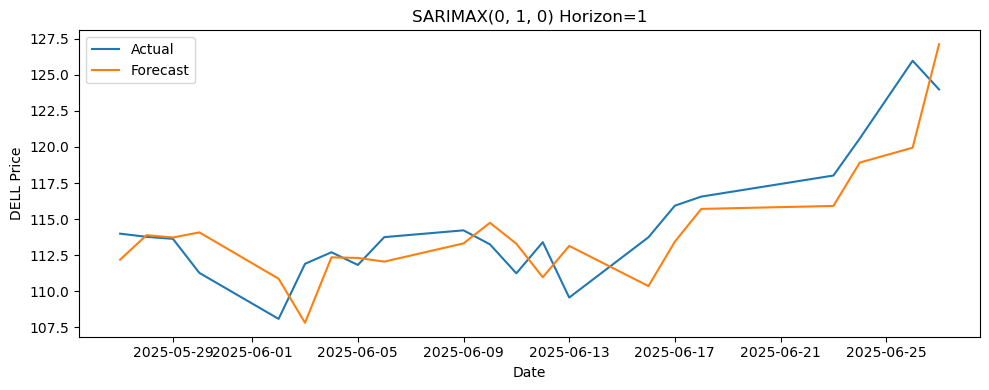

Horizon 1: RMSE=2.55, MAE=2.11, MAPE=1.83


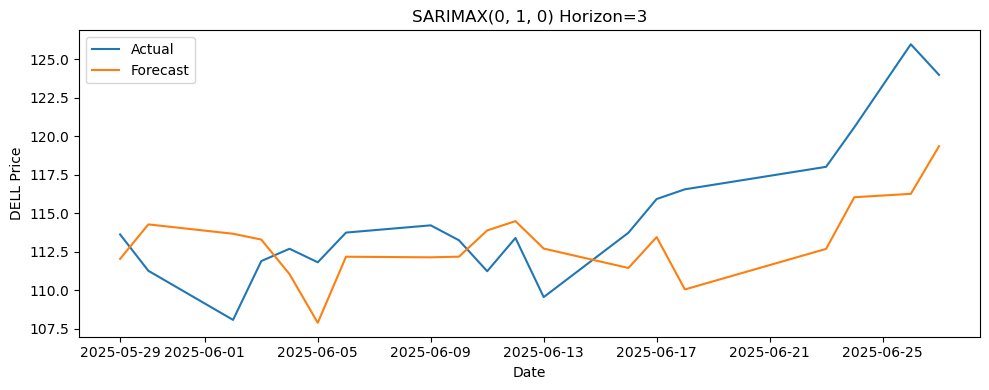

Horizon 3: RMSE=4.02, MAE=3.38, MAPE=2.91


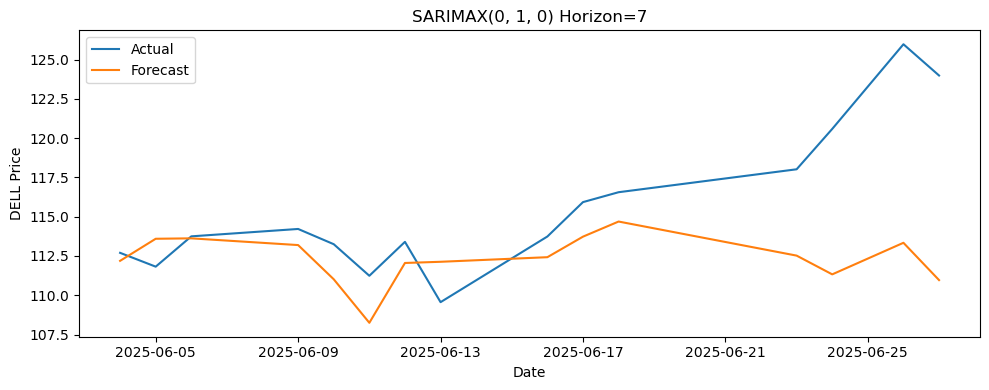

Horizon 7: RMSE=5.67, MAE=3.89, MAPE=3.25

 Metrics saved to: grouped_sarimax_2025_dell.csv


,model,horizon,rmse,mae,mape,exog_vars
0,"SARIMAX(0, 1, 0)",1,2.551611,2.112945,1.832243,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
1,"SARIMAX(0, 1, 0)",3,4.022983,3.381658,2.911324,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
2,"SARIMAX(0, 1, 0)",7,5.670439,3.892486,3.251876,"CL=F_lag4,^TNX_lag7,^VIX_lag1"


In [99]:
# grouped exo variables non-seasonal (sensible lags)
rolling_forecast_sarimax_with_metrics(
    target_df=df['DELL'],           # original data, with raw DELL values
    exog_df=df_diff,        # differenced exogenous variables.. if stationary, not diff-ed 
    exog_lags=exog_lags,
    model_order=(0, 1, 0),
    forecast_horizons=[1, 3, 7],
    train_end_date = "2025-05-23",
    test_start_date = "2025-05-27" ,
    seasonal_order=None,
    output_csv_path="grouped_sarimax_2025_dell.csv",
    plot=True,
    append_csv=False
)

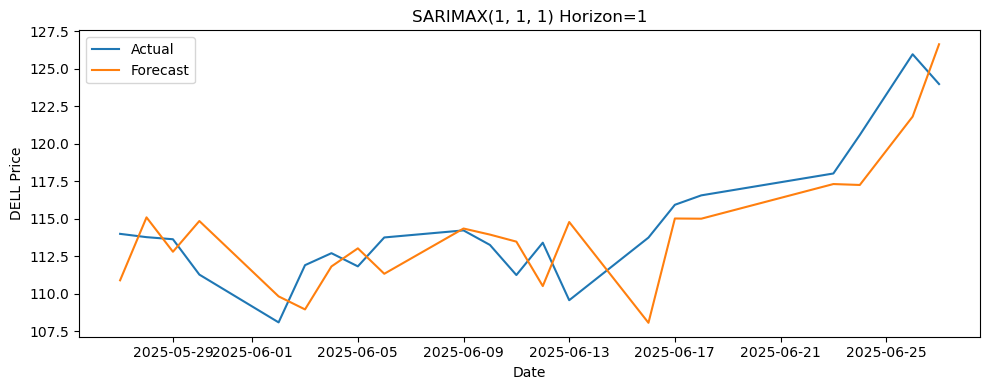

Horizon 1: RMSE=2.74, MAE=2.30, MAPE=2.00


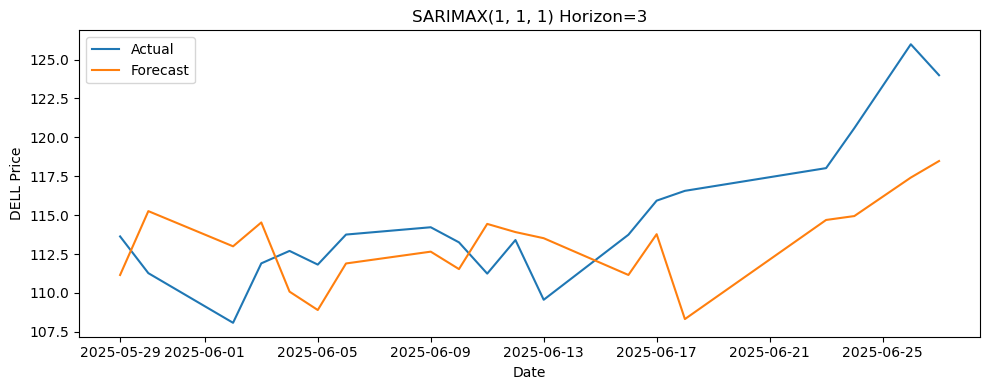

Horizon 3: RMSE=4.16, MAE=3.60, MAPE=3.11


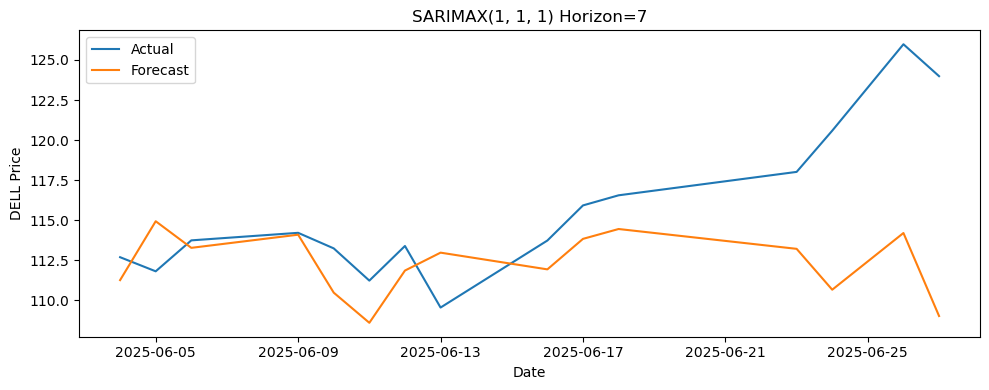

Horizon 7: RMSE=5.98, MAE=4.19, MAPE=3.52

 Metrics saved to: grouped_sarimax_2025_dell.csv


,model,horizon,rmse,mae,mape,exog_vars
0,"SARIMAX(1, 1, 1)",1,2.738047,2.296318,2.002482,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
1,"SARIMAX(1, 1, 1)",3,4.164436,3.599670,3.105628,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
2,"SARIMAX(1, 1, 1)",7,5.979483,4.194346,3.515620,"CL=F_lag4,^TNX_lag7,^VIX_lag1"


In [100]:
# grouped exo variables non-seasonal 
rolling_forecast_sarimax_with_metrics(
    target_df=df['DELL'],           # original, non-differenced target
    exog_df=df_diff,              # differenced/stationary exogenous inputs
    exog_lags=exog_lags,     # best lags configuration
    model_order=(1, 1, 1),
    forecast_horizons=[1, 3, 7],
    train_end_date="2025-05-23" ,
    test_start_date="2025-05-27",
    seasonal_order=None,
    output_csv_path="grouped_sarimax_2025_dell.csv",
    plot=True,
    append_csv=True
)

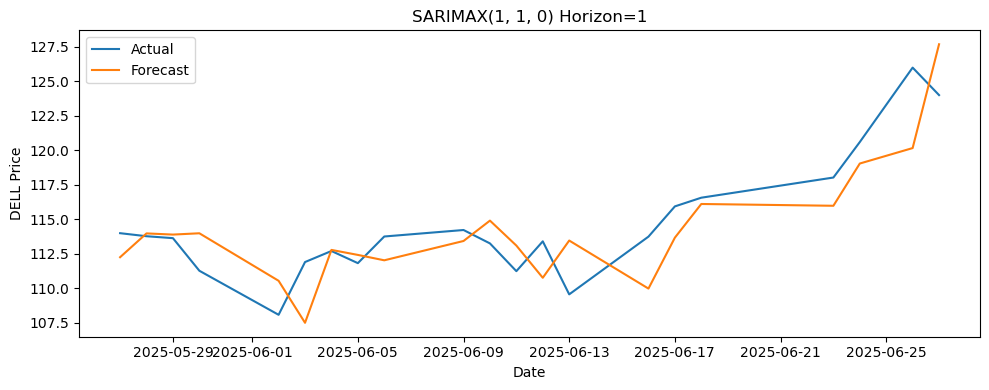

Horizon 1: RMSE=2.60, MAE=2.12, MAPE=1.84


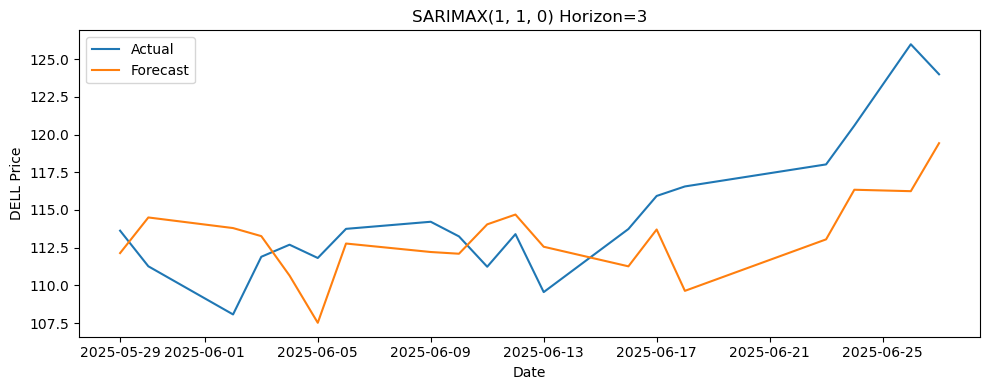

Horizon 3: RMSE=4.05, MAE=3.40, MAPE=2.93


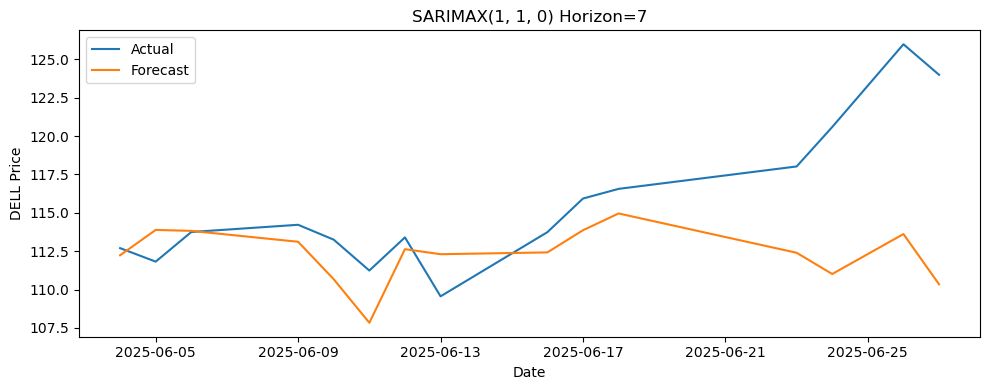

Horizon 7: RMSE=5.79, MAE=3.96, MAPE=3.31

 Metrics saved to: grouped_sarimax_2025_dell.csv


,model,horizon,rmse,mae,mape,exog_vars
0,"SARIMAX(1, 1, 0)",1,2.598255,2.123797,1.841452,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
1,"SARIMAX(1, 1, 0)",3,4.052264,3.395324,2.925573,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
2,"SARIMAX(1, 1, 0)",7,5.791080,3.959918,3.310094,"CL=F_lag4,^TNX_lag7,^VIX_lag1"


In [101]:
# grouped exo variables non-seasonal 
rolling_forecast_sarimax_with_metrics(
    target_df=df['DELL'],           # original, non-differenced target
    exog_df=df_diff,              # differenced/stationary exogenous inputs
    exog_lags=exog_lags,     # best lags configuration
    model_order=(1, 1, 0),
    forecast_horizons=[1, 3, 7],
    train_end_date="2025-05-23" ,
    test_start_date="2025-05-27",
    seasonal_order=None,
    output_csv_path="grouped_sarimax_2025_dell.csv",
    plot=True,
    append_csv=True
)

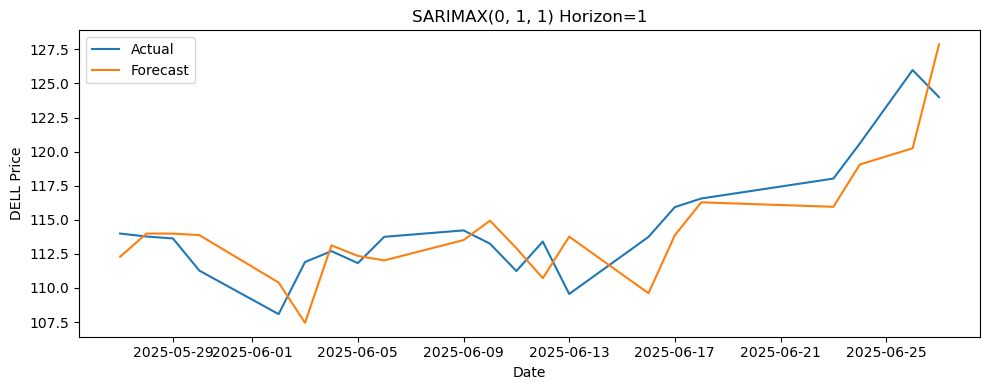

Horizon 1: RMSE=2.63, MAE=2.14, MAPE=1.86


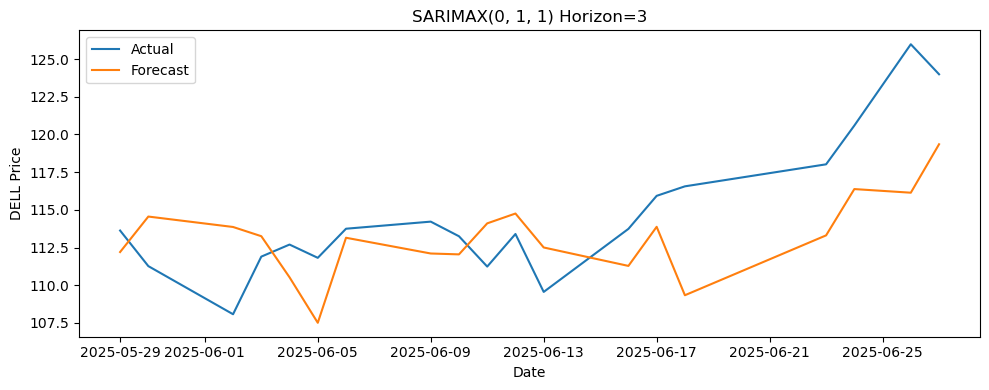

Horizon 3: RMSE=4.09, MAE=3.40, MAPE=2.93


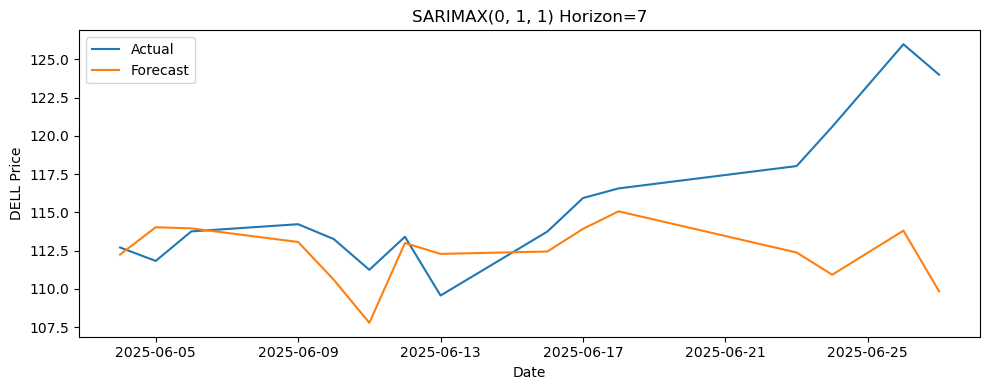

Horizon 7: RMSE=5.86, MAE=3.98, MAPE=3.33

 Metrics saved to: grouped_sarimax_2025_dell.csv


,model,horizon,rmse,mae,mape,exog_vars
0,"SARIMAX(0, 1, 1)",1,2.632336,2.142211,1.857721,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
1,"SARIMAX(0, 1, 1)",3,4.085333,3.397120,2.926925,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
2,"SARIMAX(0, 1, 1)",7,5.860792,3.983112,3.329000,"CL=F_lag4,^TNX_lag7,^VIX_lag1"


In [102]:
# grouped exo variables non-seasonal 
rolling_forecast_sarimax_with_metrics(
    target_df=df['DELL'],           # original, non-differenced target
    exog_df=df_diff,              # differenced/stationary exogenous inputs
    exog_lags=exog_lags,     # best lags configuration
    model_order=(0, 1, 1),
    forecast_horizons=[1, 3, 7],
    train_end_date="2025-05-23" ,
    test_start_date="2025-05-27",
    seasonal_order=None,
    output_csv_path="grouped_sarimax_2025_dell.csv",
    plot=True,
    append_csv=True
)

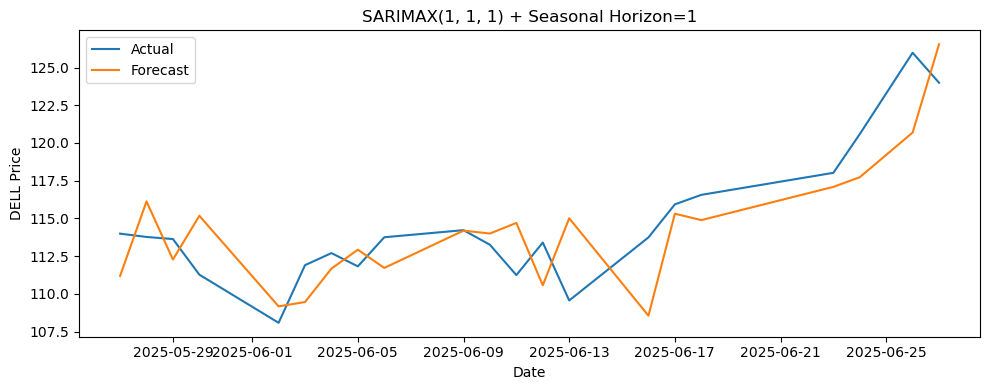

Horizon 1: RMSE=2.83, MAE=2.37, MAPE=2.06


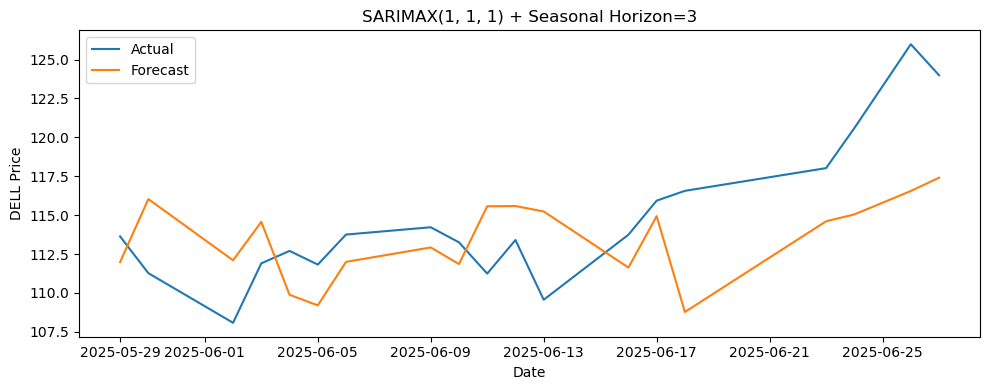

Horizon 3: RMSE=4.39, MAE=3.74, MAPE=3.22


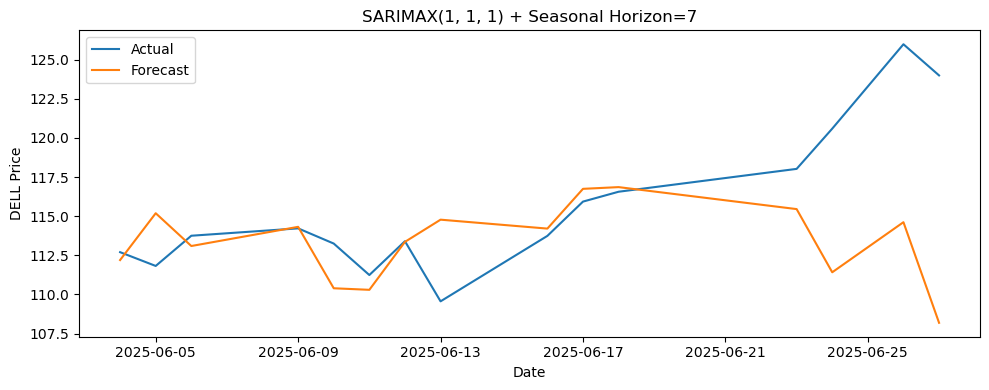

Horizon 7: RMSE=5.88, MAE=3.61, MAPE=3.01

 Metrics saved to: grouped_sarimax_seasonal_2025_dell.csv


,model,horizon,rmse,mae,mape,exog_vars
0,"SARIMAX(1, 1, 1) + Season(1, 0, 0, 21)",1,2.828031,2.369167,2.063318,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
1,"SARIMAX(1, 1, 1) + Season(1, 0, 0, 21)",3,4.392665,3.738330,3.224105,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
2,"SARIMAX(1, 1, 1) + Season(1, 0, 0, 21)",7,5.881358,3.611204,3.013628,"CL=F_lag4,^TNX_lag7,^VIX_lag1"


In [105]:
# grouped exo variables seasonal 
rolling_forecast_sarimax_with_metrics(
    target_df=df['DELL'],                      # original target, not differenced
    exog_df=df_diff,                         # pre-stationarised exogenous variables
    exog_lags=exog_lags,
    model_order=(1, 1, 1),
    forecast_horizons=[1, 3, 7],
    train_end_date="2025-05-23",
    test_start_date="2025-05-27",
    seasonal_order=(1, 0, 0, 21),            # MONTHLYy seasonality
    output_csv_path="grouped_sarimax_seasonal_2025_dell.csv",
    plot=True,
    append_csv=False
)

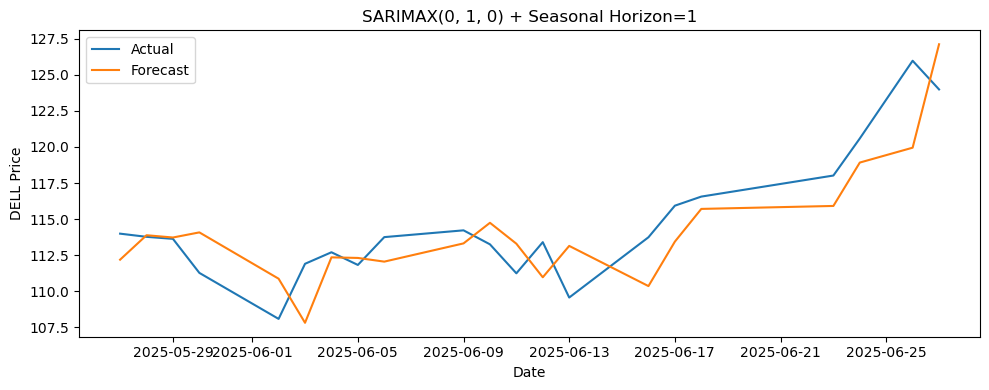

Horizon 1: RMSE=2.55, MAE=2.11, MAPE=1.83


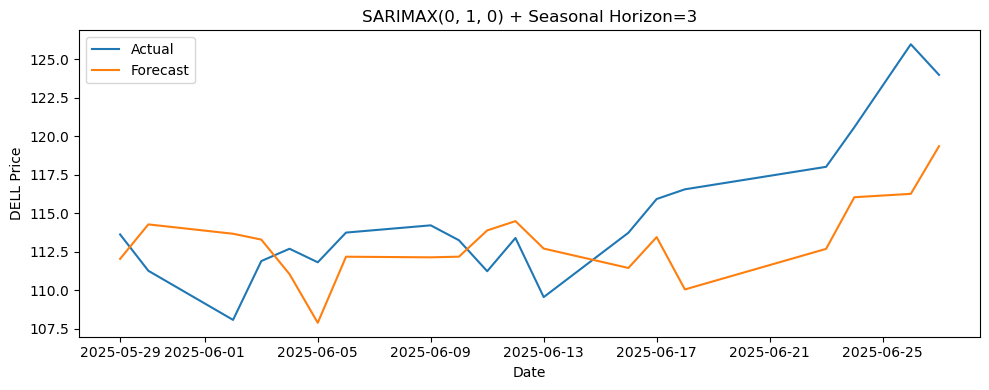

Horizon 3: RMSE=4.02, MAE=3.38, MAPE=2.91


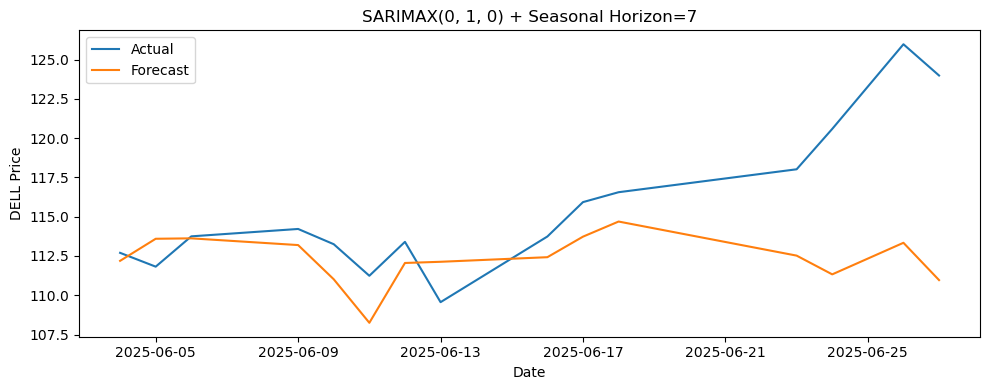

Horizon 7: RMSE=5.67, MAE=3.89, MAPE=3.25

 Metrics saved to: grouped_sarimax_best_seasonal_2025_dell.csv


,model,horizon,rmse,mae,mape,exog_vars
0,"SARIMAX(0, 1, 0) + Season(0, 0, 0, 30)",1,2.551611,2.112945,1.832243,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
1,"SARIMAX(0, 1, 0) + Season(0, 0, 0, 30)",3,4.022983,3.381658,2.911324,"CL=F_lag4,^TNX_lag7,^VIX_lag1"
2,"SARIMAX(0, 1, 0) + Season(0, 0, 0, 30)",7,5.670439,3.892486,3.251876,"CL=F_lag4,^TNX_lag7,^VIX_lag1"


In [119]:
# grouped exo variables seasonal (best lags)
rolling_forecast_sarimax_with_metrics(
    target_df=df['DELL'],                      # original (non-differenced) target
    exog_df=df_diff,                         # differenced/stationary exogenous inputs
    exog_lags=exog_lags,
    model_order=(0, 1, 0),
    forecast_horizons=[1, 3, 7],
    train_end_date="2025-05-23",
    test_start_date="2025-05-27",
    seasonal_order=(0, 0, 0, 30),
    output_csv_path="grouped_sarimax_best_seasonal_2025_dell.csv",
    plot=True,
    append_csv=False
)

### Evaluation exo variables individually

In [122]:
# One-by-one exogenous variable SARIMAX evaluation with metrics + seasonal + plots + CSV
def evaluate_single_exog_var_with_metrics(
    target_df,                  # original data, raw DELL
    exog_df,                    # differenced/stationary exogenous input
    var_name,
    lag,
    model_order,
    forecast_horizons,
    train_end_date,
    test_start_date,
    output_csv_path,
    seasonal_order=None,
    append_csv=True,
    plot=True
):
    target_df = target_df.copy()
    target_df.index = pd.to_datetime(target_df.index)
    target_df = target_df.asfreq('B')

    exog_df = exog_df.copy()
    exog_df.index = pd.to_datetime(exog_df.index)
    exog_df = exog_df.asfreq('B')

    lagged_col = f'{var_name}_lag{lag}'
    exog_df[lagged_col] = exog_df[var_name].shift(lag)
    exog_df.dropna(inplace=True)

    exog = exog_df[[lagged_col]]
    target = target_df['DELL'].loc[exog_df.index]  # align with lagged exog

    train_y = target[target.index <= train_end_date]
    test_y = target[target.index >= test_start_date]
    train_X = exog[exog.index <= train_end_date]
    test_X = exog[exog.index >= test_start_date]

    all_metrics = []

    for h in forecast_horizons:
        preds, actuals, dates = [], [], []

        for i in range(0, len(test_y) - h + 1):
            y_train = pd.concat([train_y, test_y.iloc[:i]])
            X_train = pd.concat([train_X, test_X.iloc[:i]])
            X_forecast = test_X.iloc[i:i + h]

            try:
                model = SARIMAX(
                    y_train,
                    exog=X_train,
                    order=model_order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                results = model.fit(disp=False)
                forecast = results.get_forecast(steps=h, exog=X_forecast)
                pred = forecast.predicted_mean.iloc[-1]
                actual = test_y.iloc[i + h - 1]

                if not np.isnan(pred) and not np.isnan(actual):
                    preds.append(pred)
                    actuals.append(actual)
                    dates.append(test_y.index[i + h - 1])
            except:
                continue

        if preds:
            rmse = np.sqrt(mean_squared_error(actuals, preds))
            mae = mean_absolute_error(actuals, preds)
            mape = mean_absolute_percentage_error(actuals, preds)
            print(f"{var_name} (lag={lag}) - Horizon {h} | RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")

            all_metrics.append({
                'model': f"SARIMAX{model_order}" + (f" + Season{seasonal_order}" if seasonal_order else ""),
                'exog_var': var_name,
                'lag': lag,
                'horizon': h,
                'rmse': rmse,
                'mae': mae,
                'mape': mape
            })

            if plot:
                plt.figure(figsize=(10, 4))
                plt.plot(dates, actuals, label='Actual')
                plt.plot(dates, preds, label='Forecast')
                plt.title(f"{var_name} (lag={lag}) Horizon={h}{' + Seasonal' if seasonal_order else ''}")
                plt.xlabel("Date")
                plt.ylabel("DELL Price")
                plt.legend()
                plt.tight_layout()
                plt.show()

    df_metrics = pd.DataFrame(all_metrics)
    if append_csv and os.path.exists(output_csv_path):
        df_existing = pd.read_csv(output_csv_path)
        df_combined = pd.concat([df_existing, df_metrics], ignore_index=True)
        df_combined.to_csv(output_csv_path, index=False)
    else:
        df_metrics.to_csv(output_csv_path, index=False)

    print(f"\n Metrics for {var_name} saved to: {output_csv_path}")
    return df_metrics

CL=F (lag=4) - Horizon 1 | RMSE: 2.52, MAE: 2.08, MAPE: 1.80%


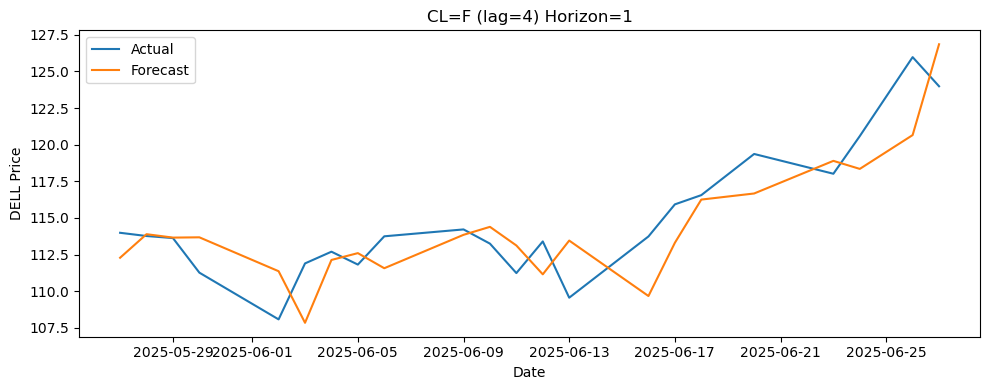

CL=F (lag=4) - Horizon 3 | RMSE: 3.68, MAE: 3.20, MAPE: 2.76%


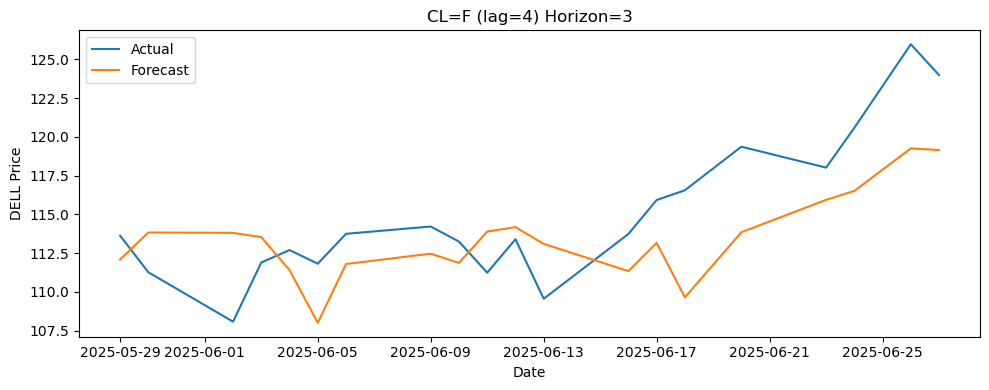

CL=F (lag=4) - Horizon 7 | RMSE: 5.80, MAE: 4.10, MAPE: 3.43%


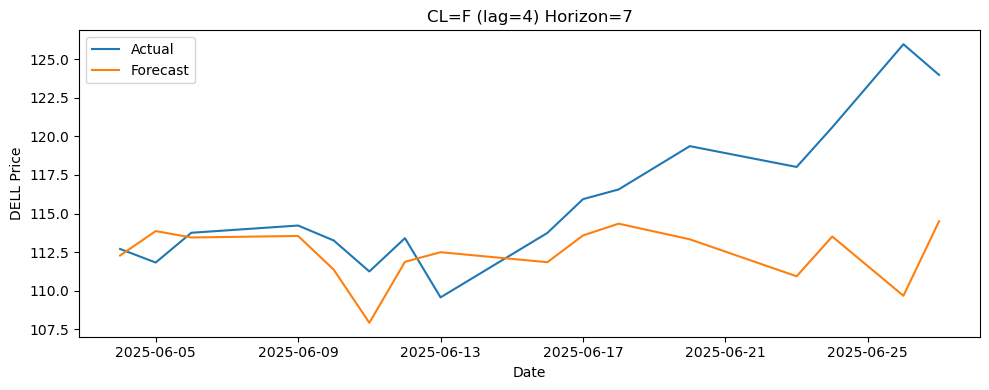


 Metrics for CL=F saved to: exo_eval_2025_dell.csv
^TNX (lag=7) - Horizon 1 | RMSE: 2.43, MAE: 2.00, MAPE: 1.73%


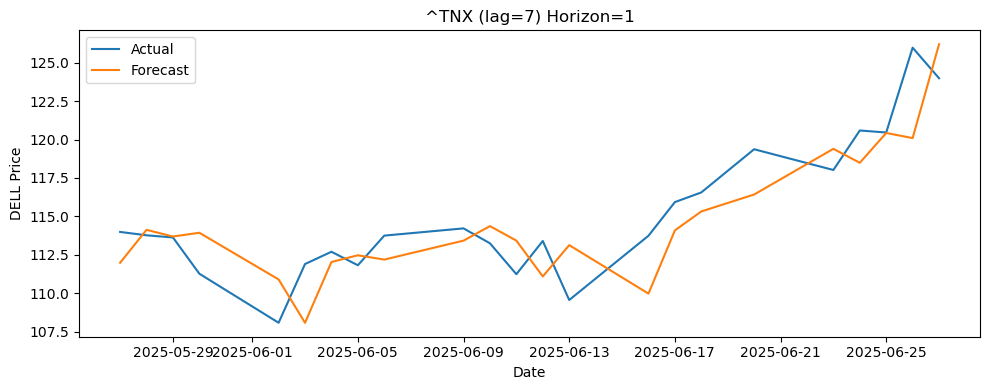

^TNX (lag=7) - Horizon 3 | RMSE: 3.65, MAE: 3.10, MAPE: 2.67%


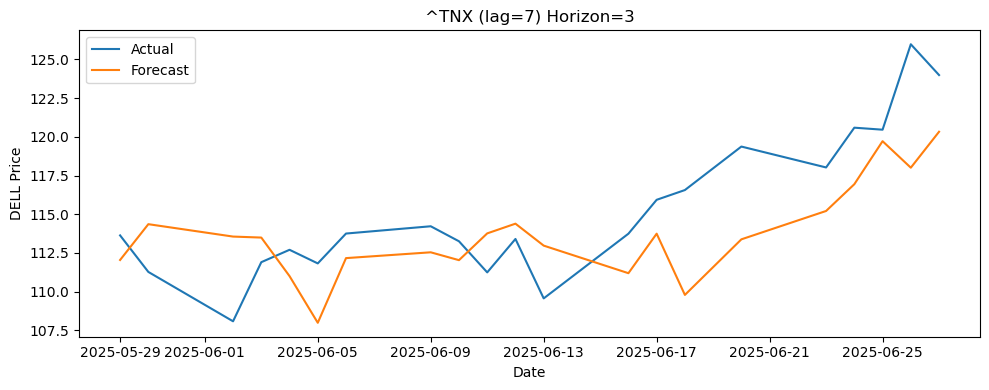

^TNX (lag=7) - Horizon 7 | RMSE: 5.53, MAE: 4.15, MAPE: 3.48%


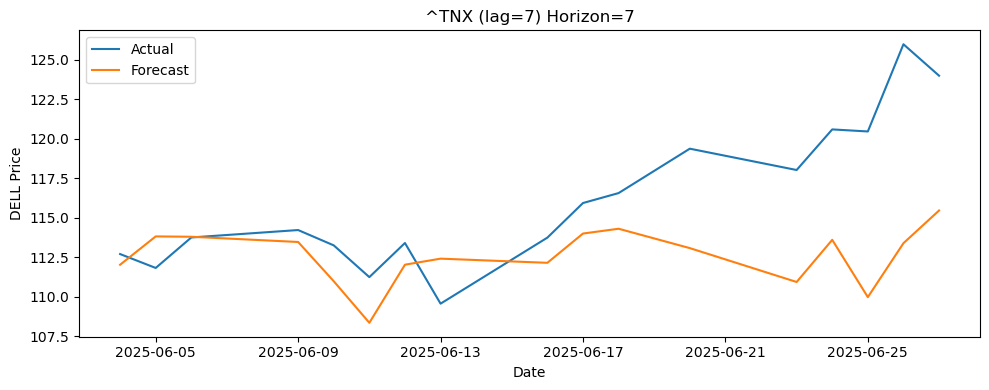


 Metrics for ^TNX saved to: exo_eval_2025_dell.csv
^VIX (lag=1) - Horizon 1 | RMSE: 2.42, MAE: 1.98, MAPE: 1.72%


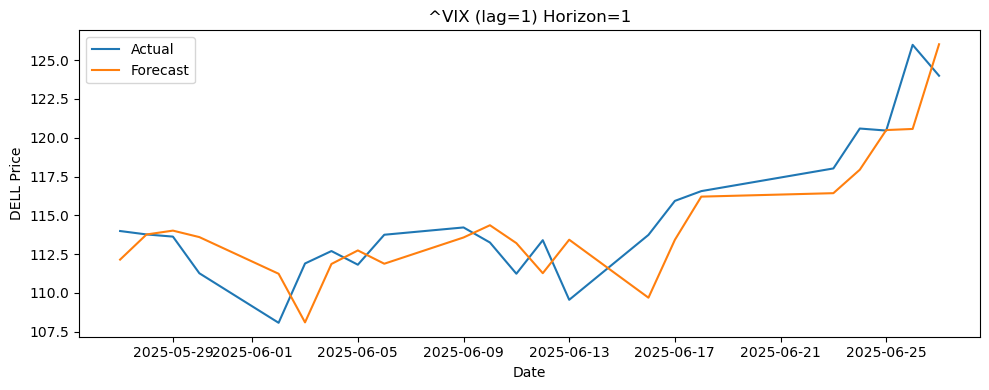

^VIX (lag=1) - Horizon 3 | RMSE: 3.78, MAE: 3.26, MAPE: 2.81%


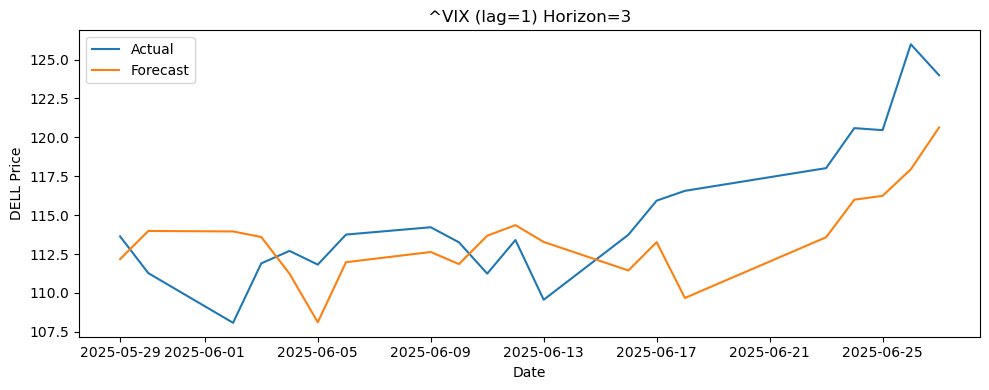

^VIX (lag=1) - Horizon 7 | RMSE: 6.07, MAE: 4.25, MAPE: 3.55%


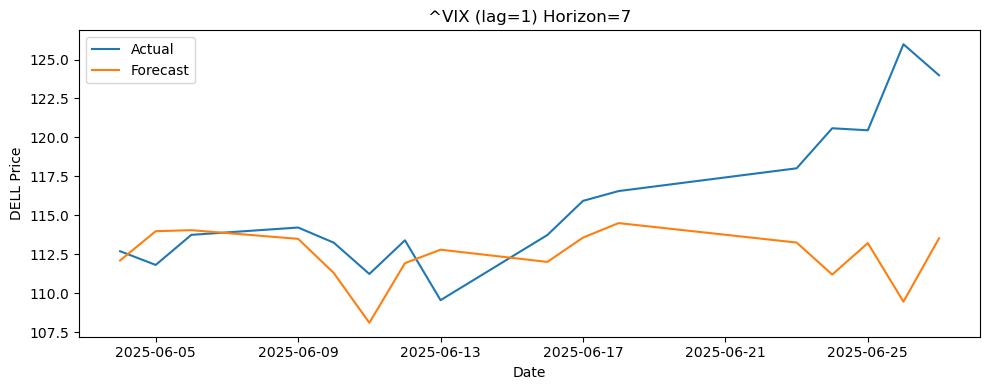


 Metrics for ^VIX saved to: exo_eval_2025_dell.csv


In [124]:
for var, lag in exog_lags.items():
    evaluate_single_exog_var_with_metrics(
        target_df=df,                   # original DELL data
        exog_df=df_diff,                # stationary exog inputs
        var_name=var,
        lag=lag,
        model_order=(0, 1, 0),
        forecast_horizons=[1, 3, 7],
        train_end_date="2025-05-23",
        test_start_date="2025-05-27",
        output_csv_path="exo_eval_2025_dell.csv",
        seasonal_order=None,
        append_csv=True,
        plot=True
    )

CL=F (lag=4) - Horizon 1 | RMSE: 2.54, MAE: 2.08, MAPE: 1.81%


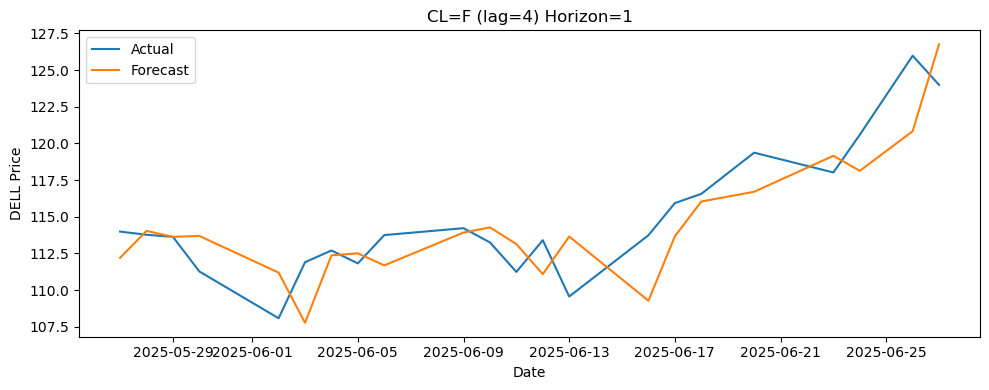

CL=F (lag=4) - Horizon 3 | RMSE: 3.72, MAE: 3.23, MAPE: 2.78%


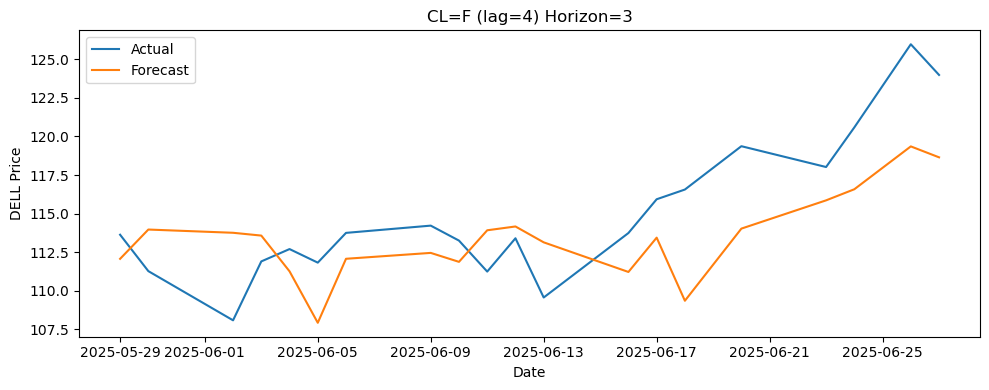

CL=F (lag=4) - Horizon 7 | RMSE: 5.84, MAE: 4.11, MAPE: 3.44%


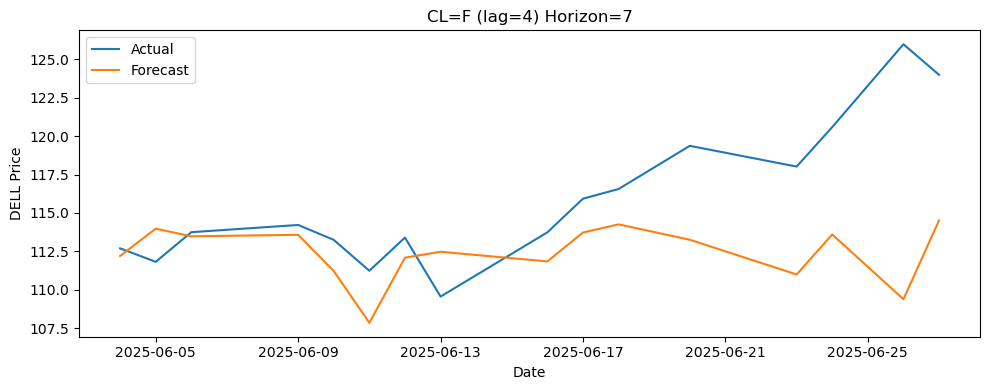


 Metrics for CL=F saved to: exo_eval_2025_dell.csv
^TNX (lag=7) - Horizon 1 | RMSE: 2.55, MAE: 2.10, MAPE: 1.83%


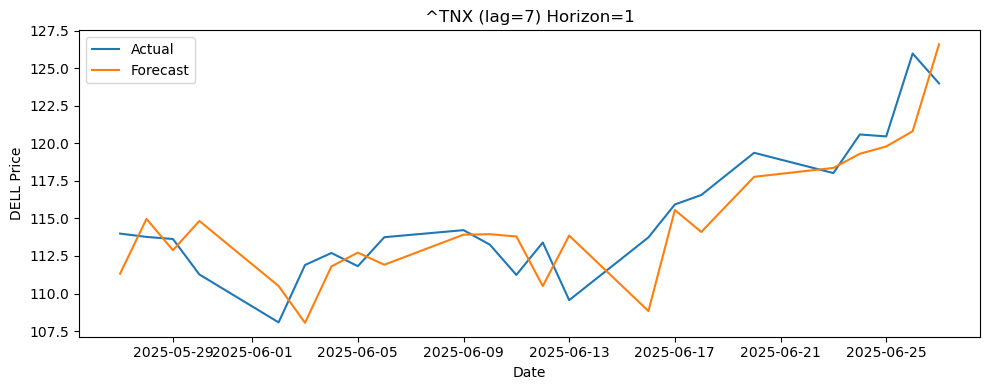

^TNX (lag=7) - Horizon 3 | RMSE: 3.67, MAE: 3.20, MAPE: 2.76%


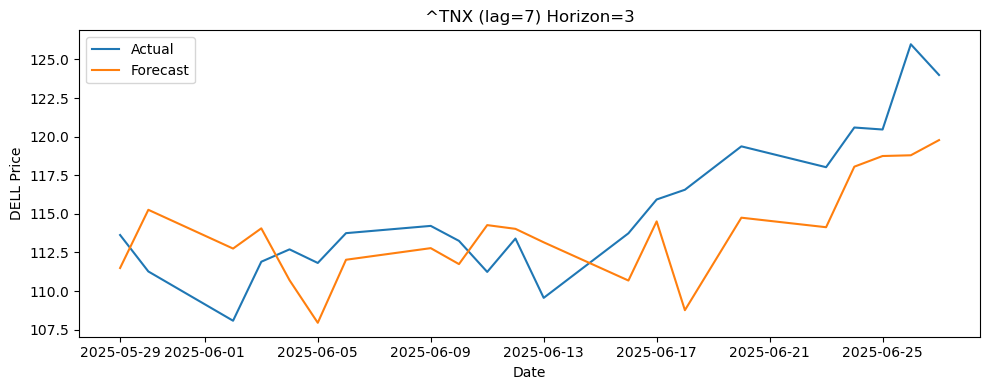

^TNX (lag=7) - Horizon 7 | RMSE: 5.58, MAE: 4.26, MAPE: 3.57%


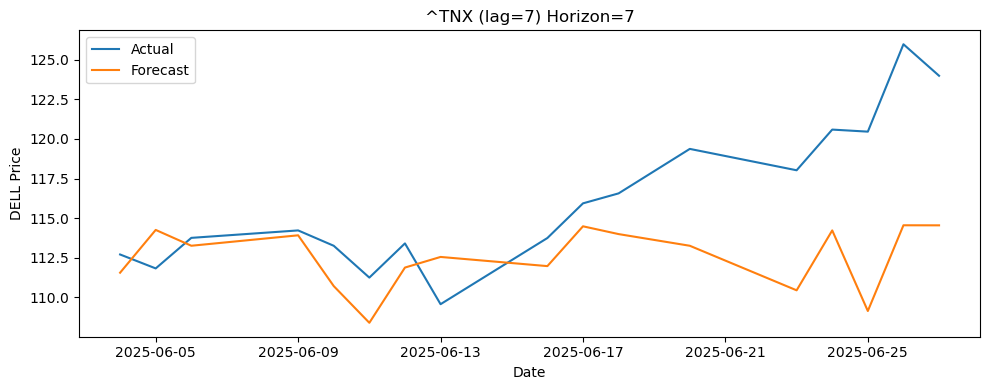


 Metrics for ^TNX saved to: exo_eval_2025_dell.csv
^VIX (lag=1) - Horizon 1 | RMSE: 2.71, MAE: 2.19, MAPE: 1.90%


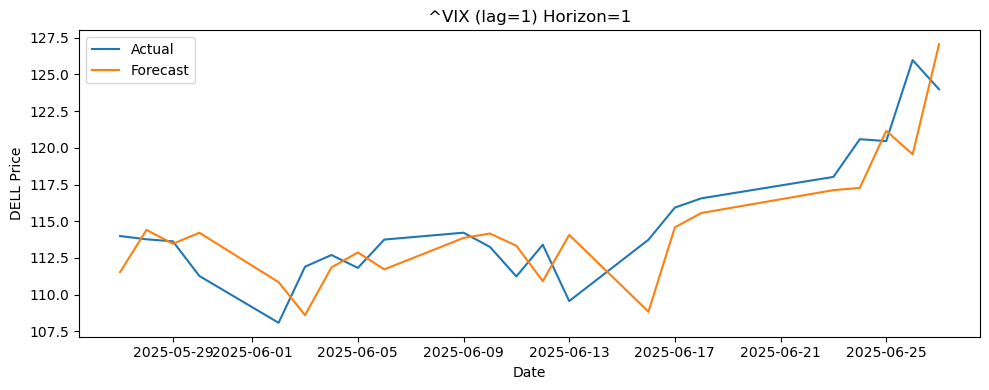

^VIX (lag=1) - Horizon 3 | RMSE: 3.86, MAE: 3.31, MAPE: 2.86%


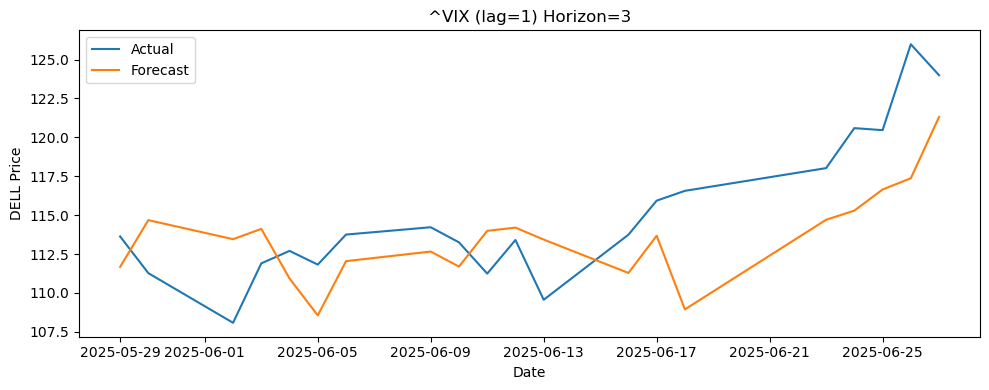

^VIX (lag=1) - Horizon 7 | RMSE: 6.13, MAE: 4.25, MAPE: 3.55%


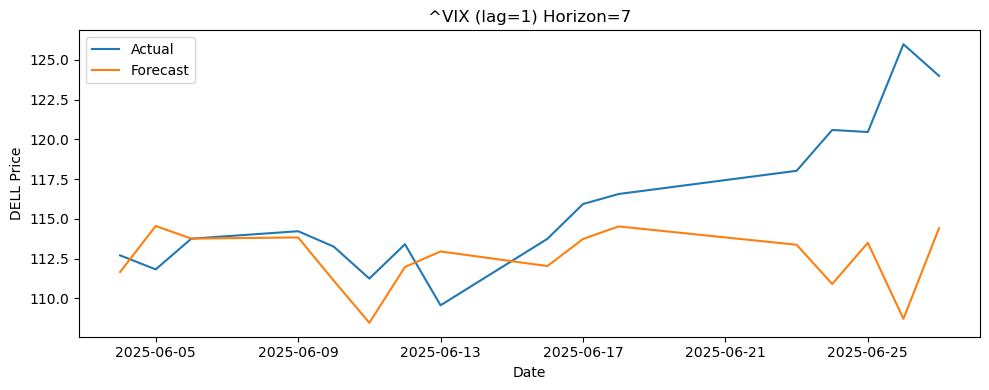


 Metrics for ^VIX saved to: exo_eval_2025_dell.csv


In [125]:
for var, lag in exog_lags.items():
    evaluate_single_exog_var_with_metrics(
        target_df=df,                   # original DELL data
        exog_df=df_diff,                # stationary exog inputs
        var_name=var,
        lag=lag,
        model_order=(1, 1, 1),
        forecast_horizons=[1, 3, 7],
        train_end_date="2025-05-23",
        test_start_date="2025-05-27",
        output_csv_path="exo_eval_2025_dell.csv",
        seasonal_order=None,
        append_csv=True,
        plot=True
    )

CL=F (lag=4) - Horizon 1 | RMSE: 2.56, MAE: 2.09, MAPE: 1.82%


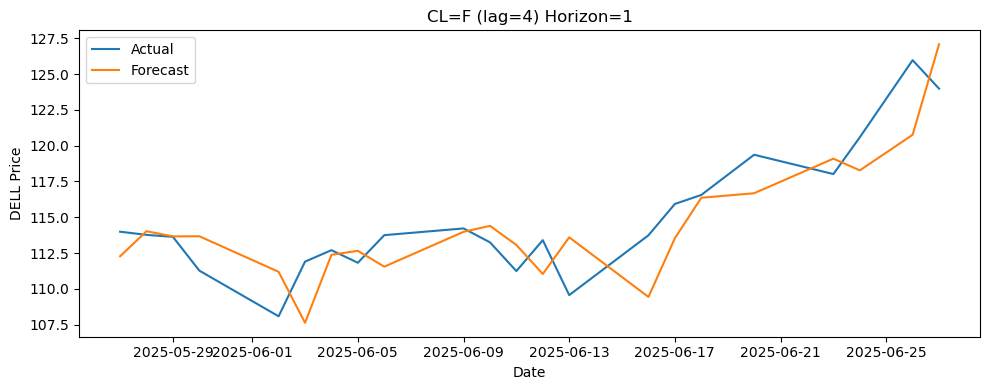

CL=F (lag=4) - Horizon 3 | RMSE: 3.69, MAE: 3.21, MAPE: 2.77%


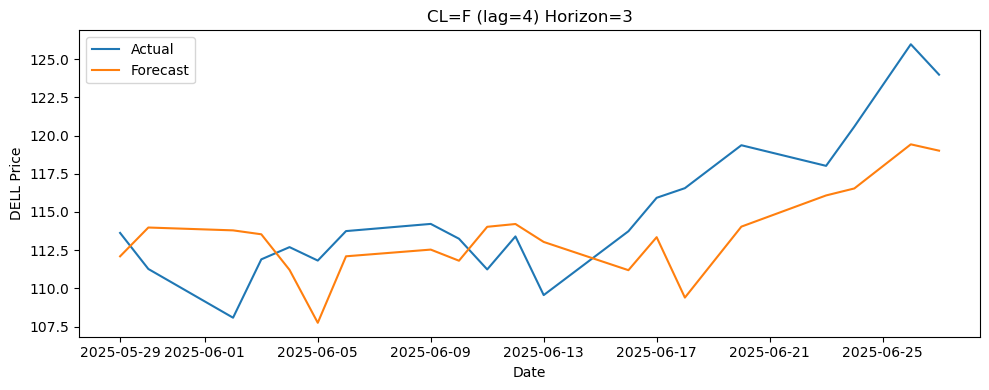

CL=F (lag=4) - Horizon 7 | RMSE: 5.84, MAE: 4.13, MAPE: 3.45%


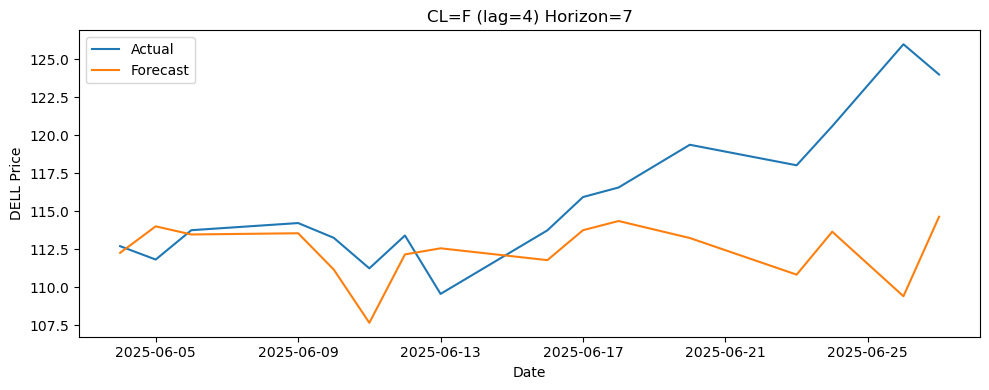


 Metrics for CL=F saved to: exo_eval_2025_dell.csv
^TNX (lag=7) - Horizon 1 | RMSE: 2.48, MAE: 2.03, MAPE: 1.76%


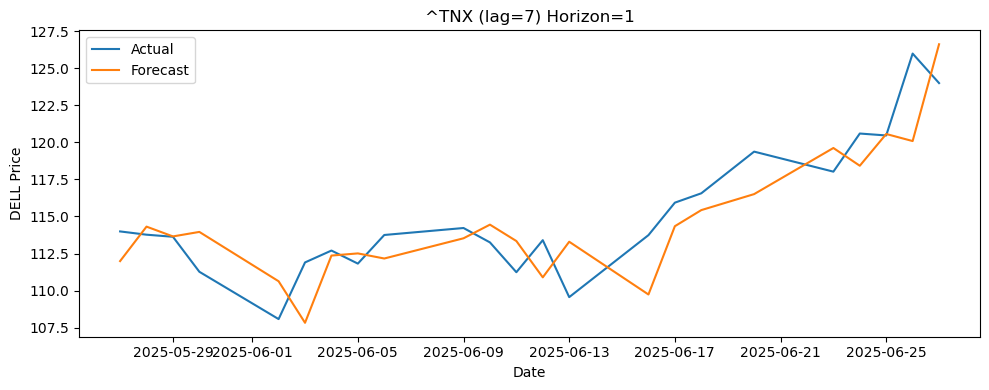

^TNX (lag=7) - Horizon 3 | RMSE: 3.67, MAE: 3.09, MAPE: 2.67%


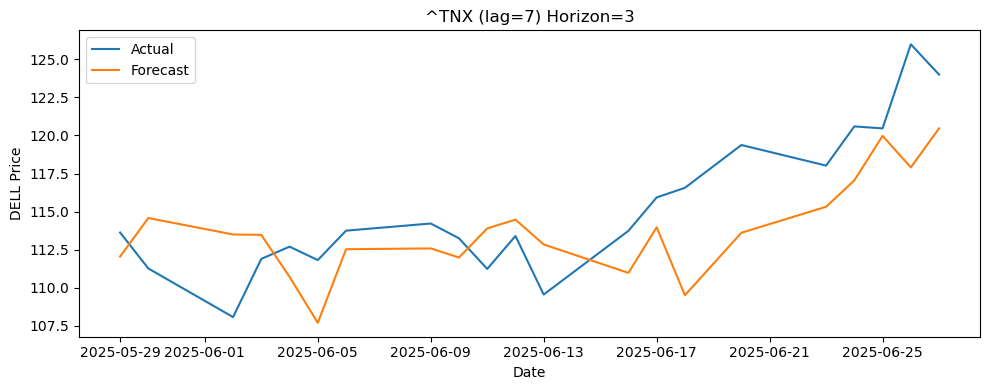

^TNX (lag=7) - Horizon 7 | RMSE: 5.54, MAE: 4.17, MAPE: 3.49%


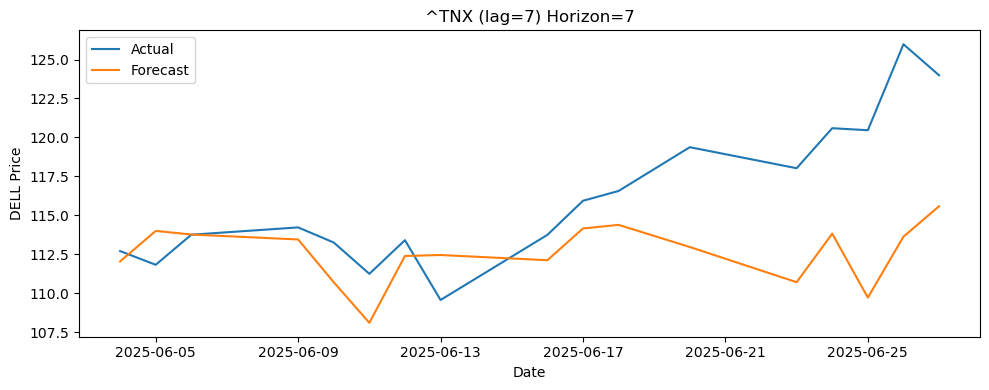


 Metrics for ^TNX saved to: exo_eval_2025_dell.csv
^VIX (lag=1) - Horizon 1 | RMSE: 2.49, MAE: 2.01, MAPE: 1.75%


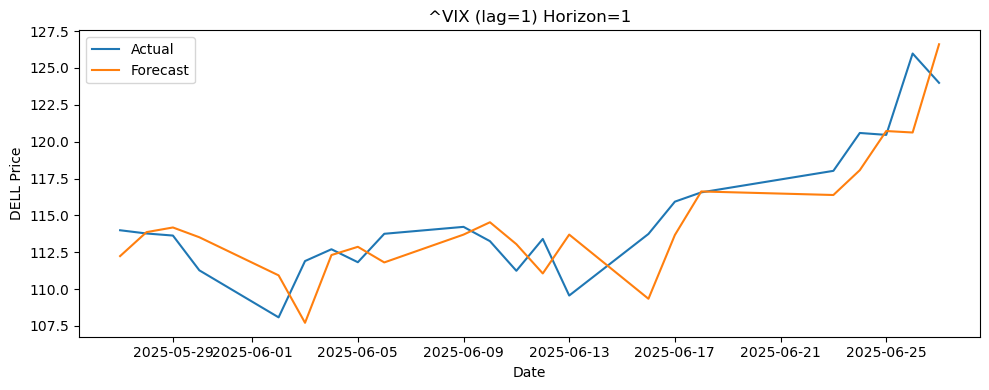

^VIX (lag=1) - Horizon 3 | RMSE: 3.79, MAE: 3.27, MAPE: 2.82%


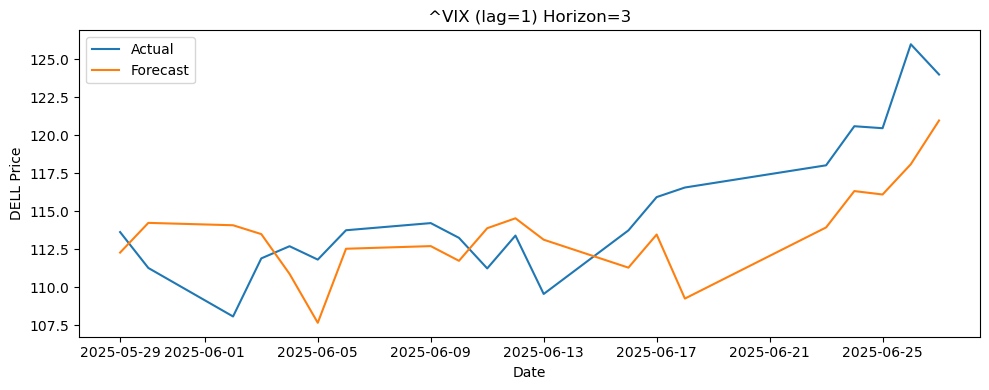

^VIX (lag=1) - Horizon 7 | RMSE: 6.17, MAE: 4.32, MAPE: 3.61%


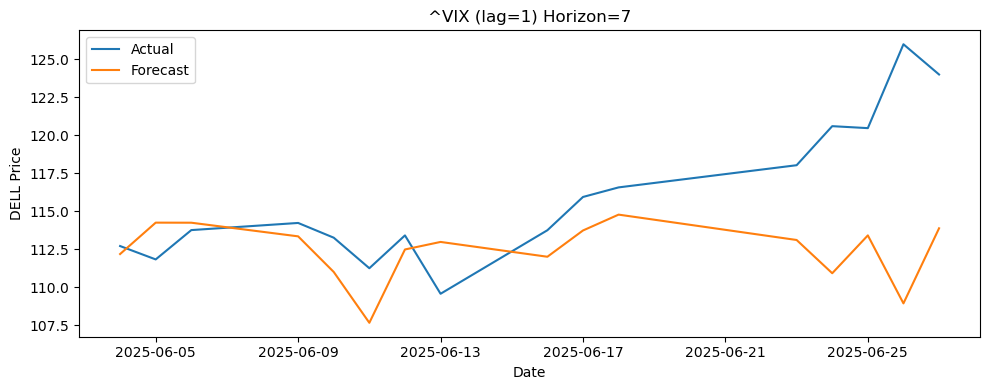


 Metrics for ^VIX saved to: exo_eval_2025_dell.csv


In [126]:
for var, lag in exog_lags.items():
    evaluate_single_exog_var_with_metrics(
        target_df=df,                   # original DELL data
        exog_df=df_diff,                # stationary exog inputs
        var_name=var,
        lag=lag,
        model_order=(1, 1, 0),
        forecast_horizons=[1, 3, 7],
        train_end_date="2025-05-23",
        test_start_date="2025-05-27",
        output_csv_path="exo_eval_2025_dell.csv",
        seasonal_order=None,
        append_csv=True,
        plot=True
    )

CL=F (lag=4) - Horizon 1 | RMSE: 2.55, MAE: 2.09, MAPE: 1.82%


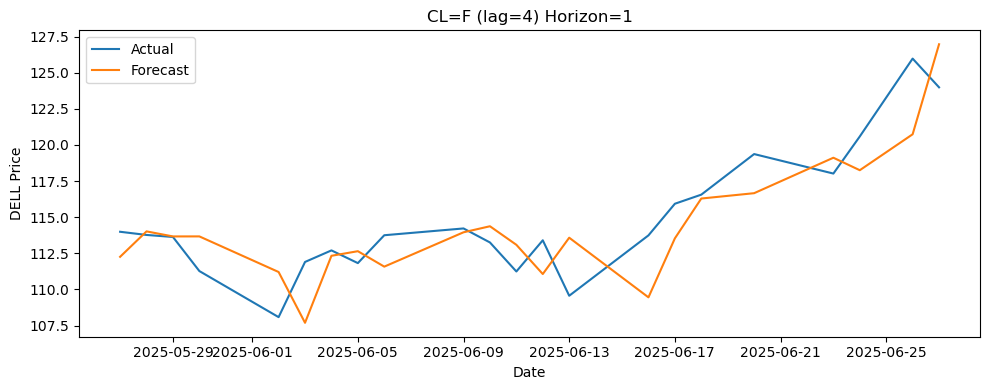

CL=F (lag=4) - Horizon 3 | RMSE: 3.70, MAE: 3.21, MAPE: 2.77%


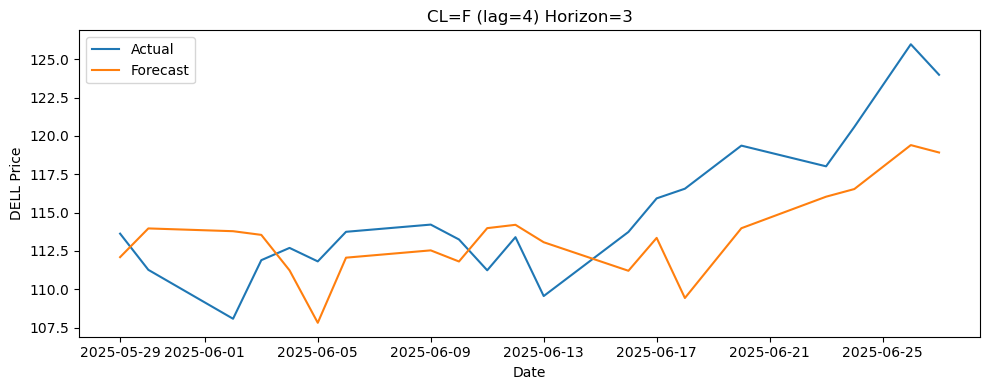

CL=F (lag=4) - Horizon 7 | RMSE: 5.84, MAE: 4.13, MAPE: 3.45%


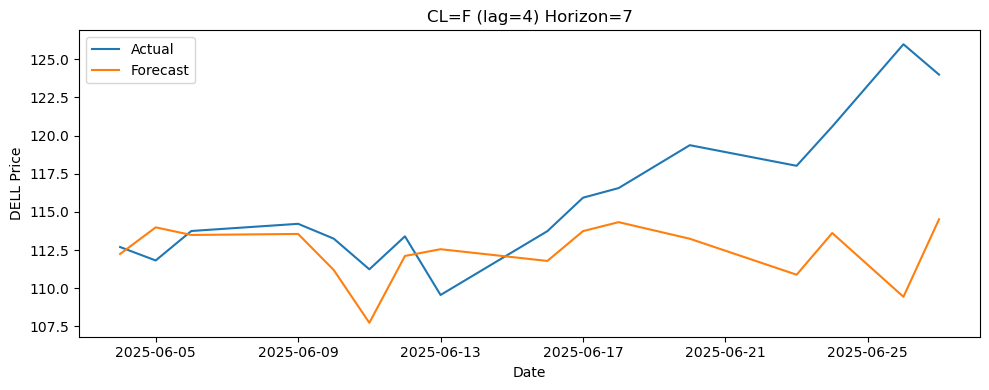


 Metrics for CL=F saved to: exo_eval_2025_dell.csv
^TNX (lag=7) - Horizon 1 | RMSE: 2.48, MAE: 2.03, MAPE: 1.76%


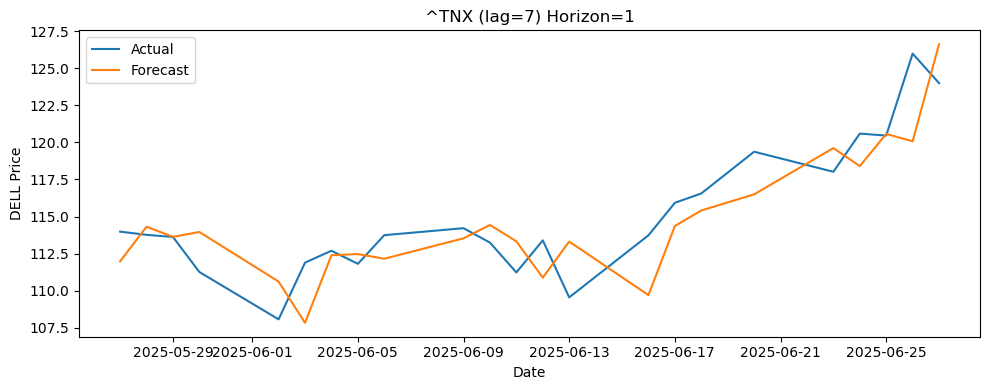

^TNX (lag=7) - Horizon 3 | RMSE: 3.67, MAE: 3.09, MAPE: 2.67%


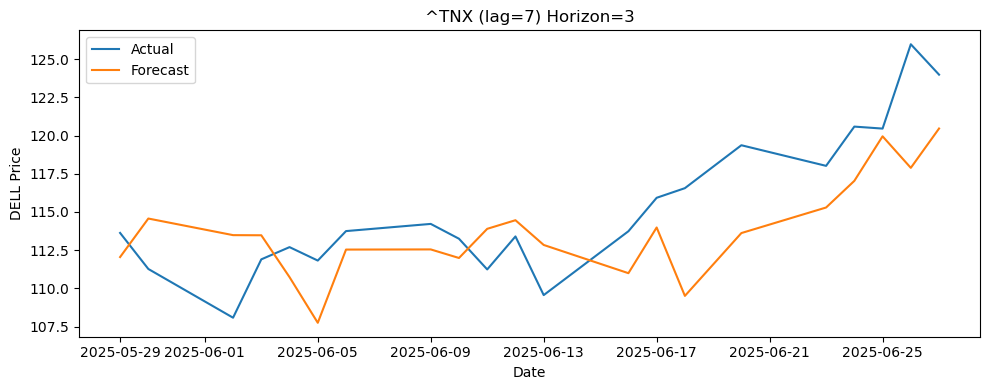

^TNX (lag=7) - Horizon 7 | RMSE: 5.54, MAE: 4.16, MAPE: 3.49%


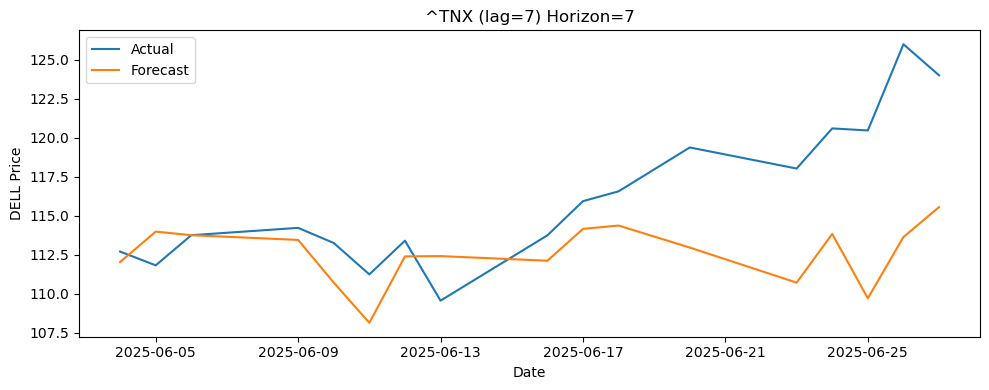


 Metrics for ^TNX saved to: exo_eval_2025_dell.csv
^VIX (lag=1) - Horizon 1 | RMSE: 2.49, MAE: 2.01, MAPE: 1.75%


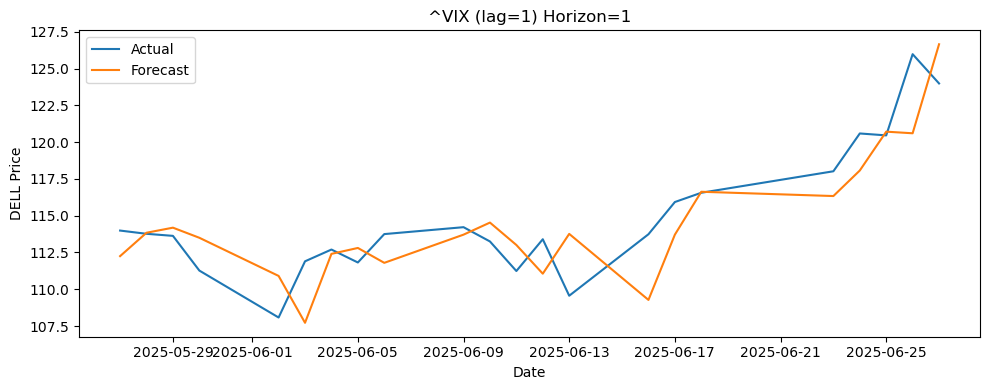

^VIX (lag=1) - Horizon 3 | RMSE: 3.79, MAE: 3.26, MAPE: 2.82%


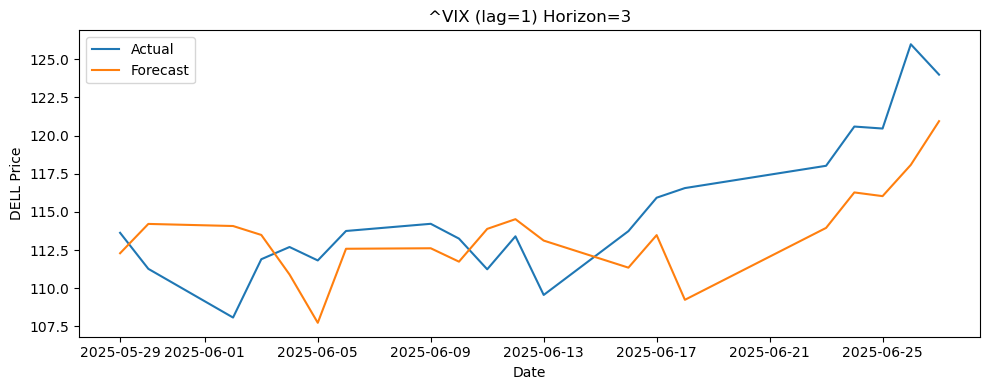

^VIX (lag=1) - Horizon 7 | RMSE: 6.17, MAE: 4.30, MAPE: 3.60%


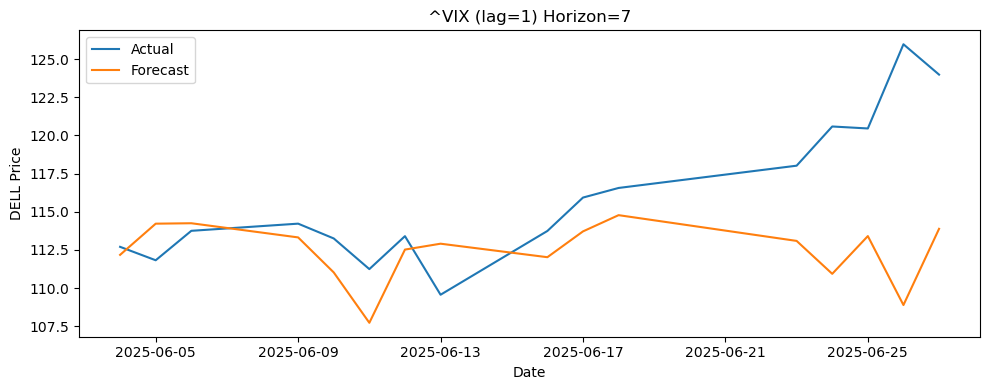


 Metrics for ^VIX saved to: exo_eval_2025_dell.csv


In [127]:
for var, lag in exog_lags.items():
    evaluate_single_exog_var_with_metrics(
        target_df=df,                   # original DELL data
        exog_df=df_diff,                # stationary exog inputs
        var_name=var,
        lag=lag,
        model_order=(0, 1, 1),
        forecast_horizons=[1, 3, 7],
        train_end_date="2025-05-23",
        test_start_date="2025-05-27",
        output_csv_path="exo_eval_2025_dell.csv",
        seasonal_order=None,
        append_csv=True,
        plot=True
    )

### Evaluating individual exo variables SARIMAX

CL=F (lag=4) - Horizon 1 | RMSE: 2.53, MAE: 2.05, MAPE: 1.78%


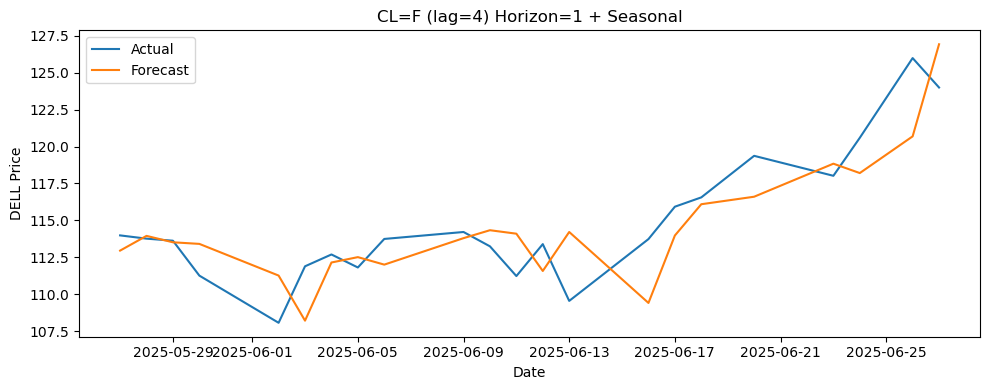

CL=F (lag=4) - Horizon 3 | RMSE: 3.75, MAE: 3.22, MAPE: 2.78%


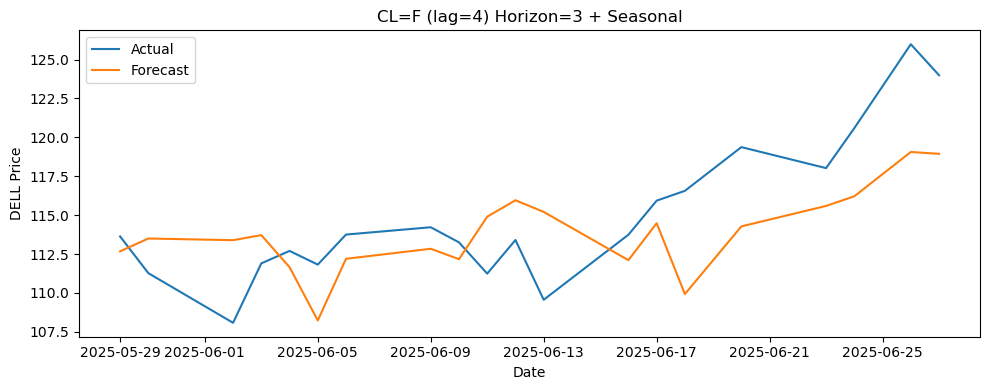

CL=F (lag=4) - Horizon 7 | RMSE: 5.51, MAE: 3.44, MAPE: 2.87%


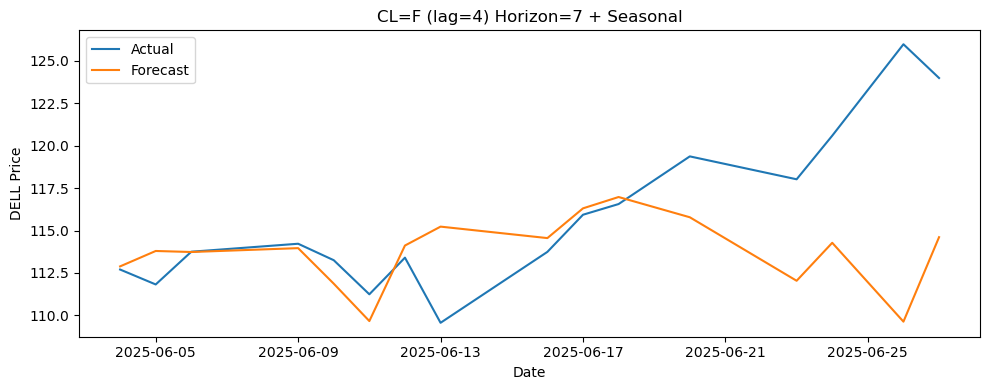


 Metrics for CL=F saved to: exo_eval_seasonal_2025_dell.csv
^TNX (lag=7) - Horizon 1 | RMSE: 2.42, MAE: 1.94, MAPE: 1.68%


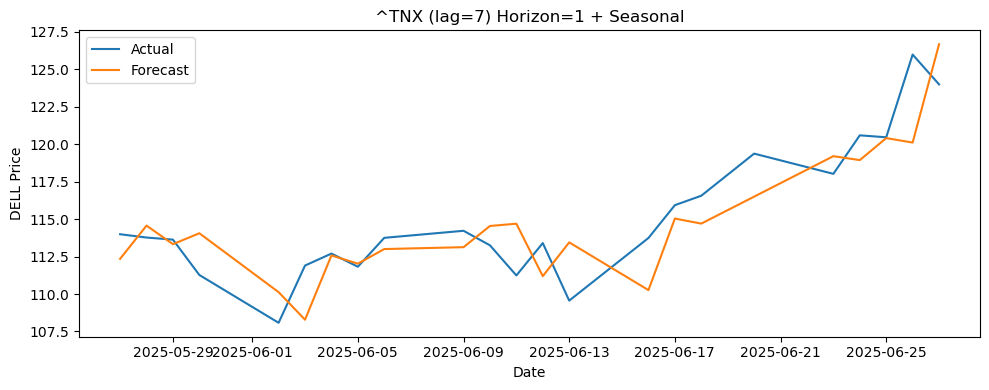

^TNX (lag=7) - Horizon 3 | RMSE: 3.68, MAE: 3.08, MAPE: 2.66%


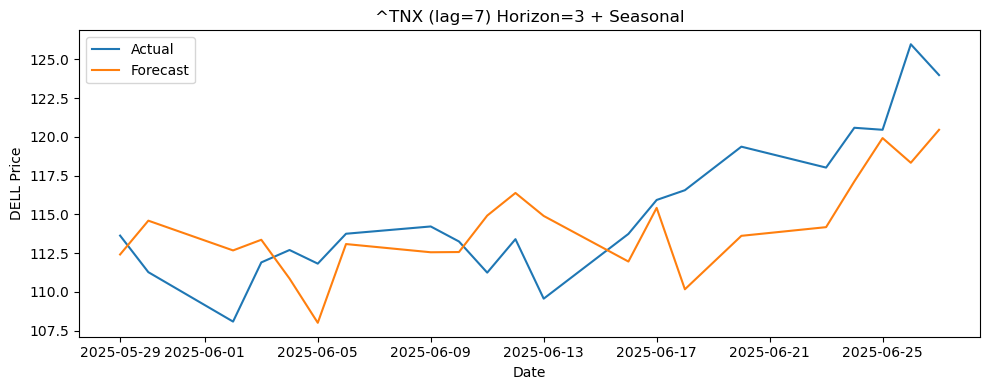

^TNX (lag=7) - Horizon 7 | RMSE: 5.25, MAE: 3.73, MAPE: 3.12%


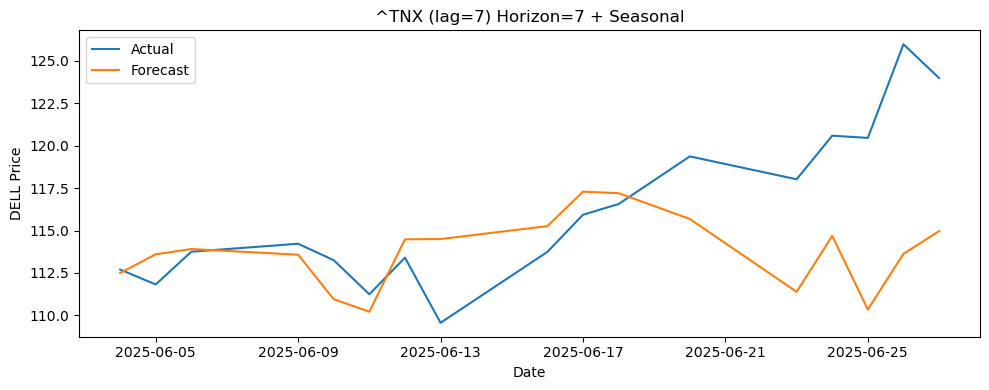


 Metrics for ^TNX saved to: exo_eval_seasonal_2025_dell.csv
^VIX (lag=1) - Horizon 1 | RMSE: 3.04, MAE: 2.41, MAPE: 2.09%


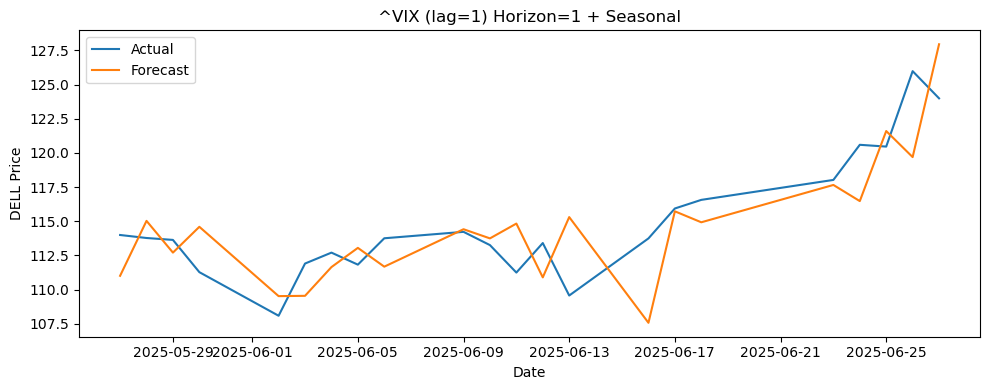

^VIX (lag=1) - Horizon 3 | RMSE: 4.21, MAE: 3.53, MAPE: 3.05%


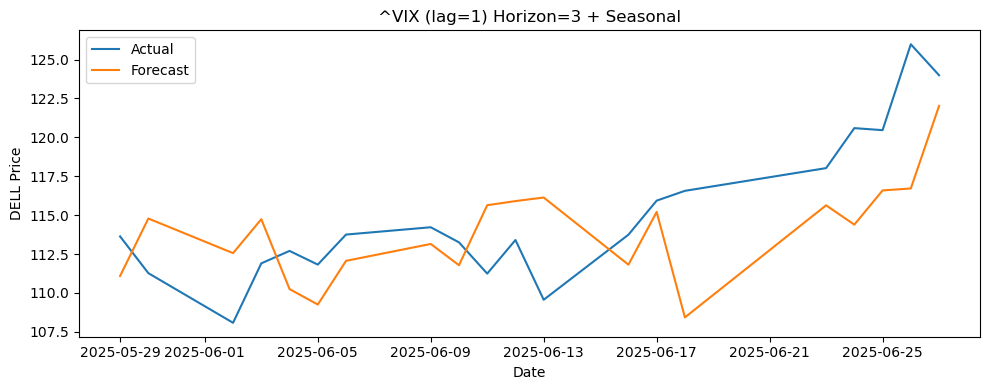

^VIX (lag=1) - Horizon 7 | RMSE: 6.00, MAE: 3.80, MAPE: 3.17%


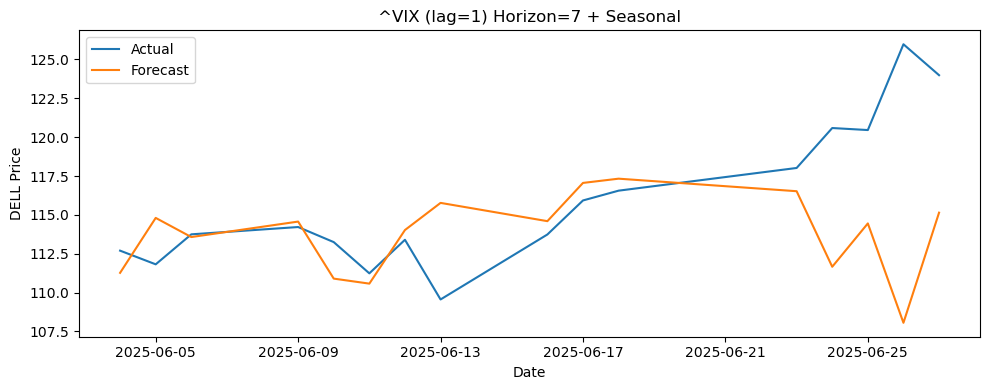


 Metrics for ^VIX saved to: exo_eval_seasonal_2025_dell.csv


In [129]:
#sesonal version
for var, lag in exog_lags.items():
    evaluate_single_exog_var_with_metrics(
        target_df=df,                   # original (non-differenced) BA series
        exog_df=df_diff,                # differenced/stationary exogenous inputs
        var_name=var,
        lag=lag,
        model_order=(1, 1, 1),
        forecast_horizons=[1, 3, 7],
        train_end_date="2025-05-23",
        test_start_date="2025-05-27",
        output_csv_path="exo_eval_seasonal_2025_dell.csv",
        seasonal_order=(1, 0, 0, 21),
        append_csv=False,
        plot=True
    )

### Building LSTM baseline model for BA

Very simple architechture first...
- no dropout, 1 layer
- relu, adam, mse loss 

In [133]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
#initial simple basline model
def create_lstm_baseline_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def evaluate_lstm_baseline(
    df,
    forecast_horizons=[1, 3, 7],
    train_end = "2025-05-23",  
    test_start = "2025-05-27",
    window_size=30,
    epochs=20,
    output_csv_path="lstm_baseline_metrics_2025_dell.csv",
    plot=True
):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.asfreq('B')
    series = df['DELL'].dropna().to_frame()

    # Scale data
    scaler = MinMaxScaler()
    series_scaled = scaler.fit_transform(series)

    # Split into train/test
    split_train = series.index <= train_end
    split_test = series.index >= test_start

    all_metrics = []

    for h in forecast_horizons:
        preds, actuals, dates = [], [], []

        for i in range(window_size, len(series_scaled) - h):
            if not split_test[i + h]:
                continue

            X = series_scaled[i - window_size:i].reshape(1, window_size, 1)
            y = series_scaled[i + h][0]

            # Rebuild model each time to prevent data leakage
            X_train_full = []
            y_train_full = []
            for j in range(window_size, i):
                X_train_full.append(series_scaled[j - window_size:j])
                y_train_full.append(series_scaled[j][0])
            X_train_full = np.array(X_train_full)
            y_train_full = np.array(y_train_full)

            model = create_lstm_baseline_model((window_size, 1))
            model.fit(X_train_full, y_train_full, epochs=epochs, verbose=0)

            pred_scaled = model.predict(X)[0][0]
            pred = scaler.inverse_transform([[pred_scaled]])[0][0]
            actual = series.iloc[i + h][0]

            preds.append(pred)
            actuals.append(actual)
            dates.append(series.index[i + h])

        if preds:
            rmse = np.sqrt(mean_squared_error(actuals, preds))
            mae = mean_absolute_error(actuals, preds)
            mape = mean_absolute_percentage_error(actuals, preds)
            print(f"Horizon {h}: RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}")
            
            all_metrics.append({
                "model": "LSTM (baseline)",
                "horizon": h,
                "rmse": rmse,
                "mae": mae,
                "mape": mape
            })

            if plot:
                plt.figure(figsize=(10, 4))
                plt.plot(dates, actuals, label="Actual")
                plt.plot(dates, preds, label="Forecast")
                plt.title(f"LSTM Baseline Forecast - {h}-Day Horizon")
                plt.xlabel("Date")
                plt.ylabel("DELL Price")
                plt.legend()
                plt.tight_layout()
                plt.show()

    df_metrics = pd.DataFrame(all_metrics)
    df_metrics.to_csv(output_csv_path, index=False)
    print(f" Saved baseline LSTM metrics to {output_csv_path}")
    return df_metrics

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Horizon 1: RMSE=6.61, MAE=5.77, MAPE=4.94


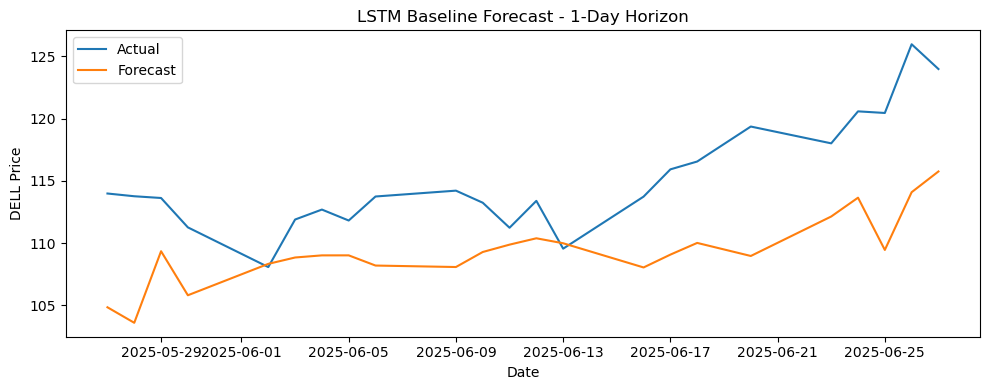

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Horizon 3: RMSE=7.27, MAE=6.47, MAPE=5.54


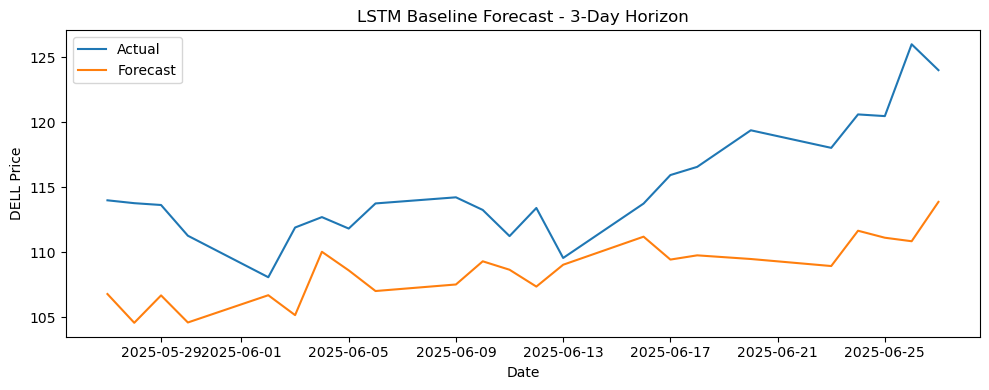

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Horizon 7: RMSE=10.27, MAE=9.00, MAPE=7.75


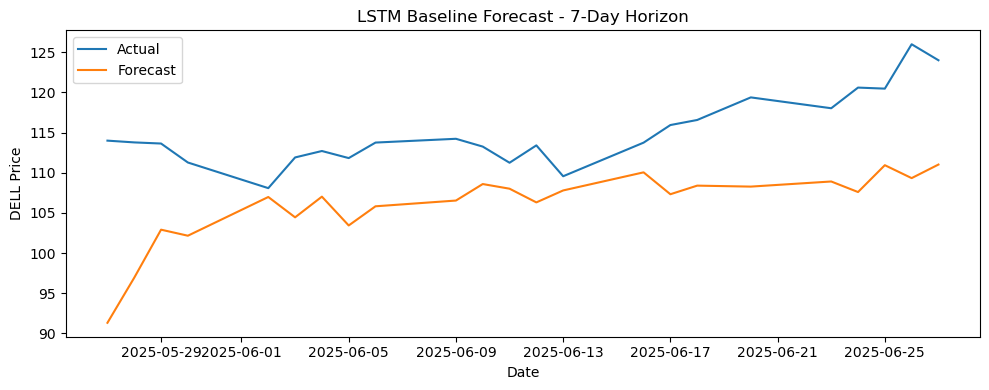

 Saved baseline LSTM metrics to lstm_baseline_metrics_2025_dell.csv


In [134]:
lstm_baseline_results = evaluate_lstm_baseline(
    df=df,
    forecast_horizons=[1, 3, 7],
    train_end="2025-05-23",  
    test_start = "2025-05-27",
    window_size=30,
    epochs=20,
    output_csv_path="lstm_baseline_metrics_2025_dell.csv",
    plot=True
)

Function to evealuate more complex models and model tweaks

In [136]:
def evaluate_lstm_model(
    df,
    model_fn,
    forecast_horizons=[1, 3, 7],
    train_end="2025-05-23",
    test_start="2025-05-27",
    window_size=30,
    epochs=20,
    output_csv_path="lstm_metrics_2025_dell.csv",
    plot=True,
    callbacks=None
):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.asfreq('B')
    series = df['DELL'].dropna().to_frame()

    scaler = MinMaxScaler()
    series_scaled = scaler.fit_transform(series)

    split_train = series.index <= train_end
    split_test = series.index >= test_start

    all_metrics = []

    for h in forecast_horizons:
        preds, actuals, dates = [], [], []

        for i in range(window_size, len(series_scaled) - h):
            if not split_test[i + h]:
                continue

            X = series_scaled[i - window_size:i].reshape(1, window_size, 1)
            y = series_scaled[i + h][0]

            X_train_full, y_train_full = [], []
            for j in range(window_size, i):
                X_train_full.append(series_scaled[j - window_size:j])
                y_train_full.append(series_scaled[j][0])
            X_train_full = np.array(X_train_full)
            y_train_full = np.array(y_train_full)

            model = model_fn((window_size, 1))
            model.fit(X_train_full, y_train_full, epochs=epochs, verbose=0, callbacks=callbacks)

            pred_scaled = model.predict(X)[0][0]
            pred = scaler.inverse_transform([[pred_scaled]])[0][0]
            actual = series.iloc[i + h][0]

            preds.append(pred)
            actuals.append(actual)
            dates.append(series.index[i + h])

        if preds:
            rmse = np.sqrt(mean_squared_error(actuals, preds))
            mae = mean_absolute_error(actuals, preds)
            mape = mean_absolute_percentage_error(actuals, preds)
            print(f"Horizon {h}: RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}")

            all_metrics.append({
                "model": model_fn.__name__,
                "horizon": h,
                "rmse": rmse,
                "mae": mae,
                "mape": mape
            })

            if plot:
                plt.figure(figsize=(10, 4))
                plt.plot(dates, actuals, label="Actual")
                plt.plot(dates, preds, label="Forecast")
                plt.title(f"{model_fn.__name__} - {h}-Day Horizon")
                plt.xlabel("Date")
                plt.ylabel("DELL Price")
                plt.legend()
                plt.tight_layout()
                plt.show()

    df_metrics = pd.DataFrame(all_metrics)
    df_metrics.to_csv(output_csv_path, index=False)
    print(f"\n Saved metrics to {output_csv_path}")
    return df_metrics

Slightly more complex model for baseline
- using tanh instead of relu
- adding in dropout
- adding in early stopping

In [139]:
def create_lstm_tanh_dropout_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, activation='tanh', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Horizon 1: RMSE=32.43, MAE=31.60, MAPE=27.40


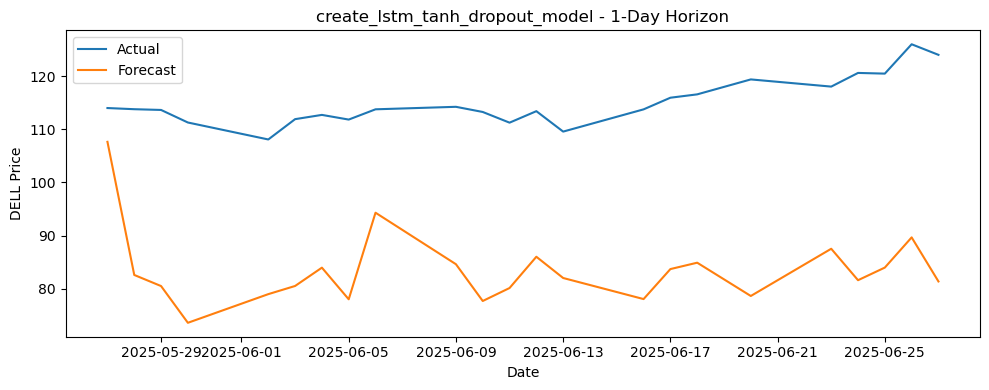

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Horizon 3: RMSE=32.96, MAE=32.31, MAPE=28.05


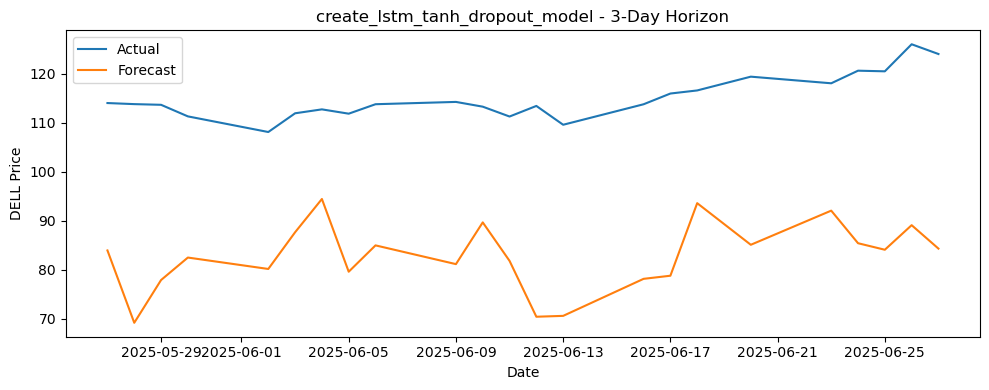

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Horizon 7: RMSE=33.05, MAE=32.46, MAPE=28.13


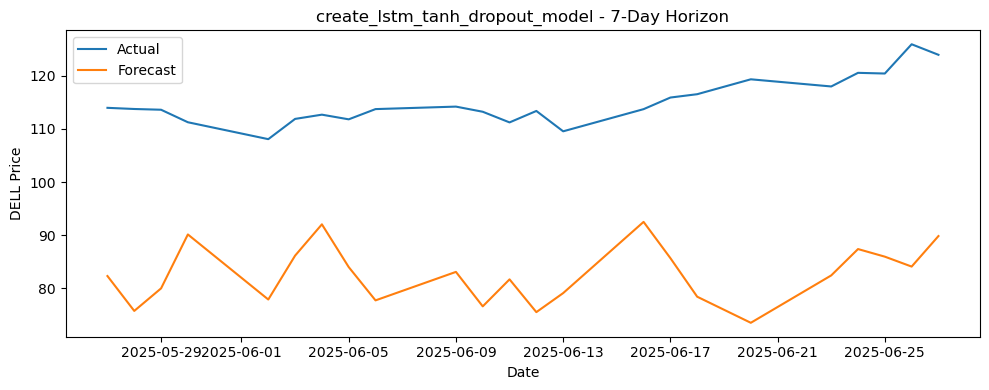


 Saved metrics to lstm_tanh_dropout_2025_dell.csv


,model,horizon,rmse,mae,mape
0,create_lstm_tanh_dropout_model,1,32.431209,31.602400,27.398327
1,create_lstm_tanh_dropout_model,3,32.959787,32.305261,28.047421
2,create_lstm_tanh_dropout_model,7,33.051825,32.456177,28.130131


In [140]:
#call this model with early stopping
early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

evaluate_lstm_model(
    df=df,
    model_fn=create_lstm_tanh_dropout_model,
    forecast_horizons=[1, 3, 7],
    output_csv_path="lstm_tanh_dropout_2025_dell.csv",
    callbacks=[early_stop]
)

This model proving worse that prvious despite dropout etc. Going to try same model architecture again...but just swap back in relu for tanh

In [143]:
def create_lstm_relu_dropout_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Horizon 1: RMSE=40.71, MAE=39.90, MAPE=34.57


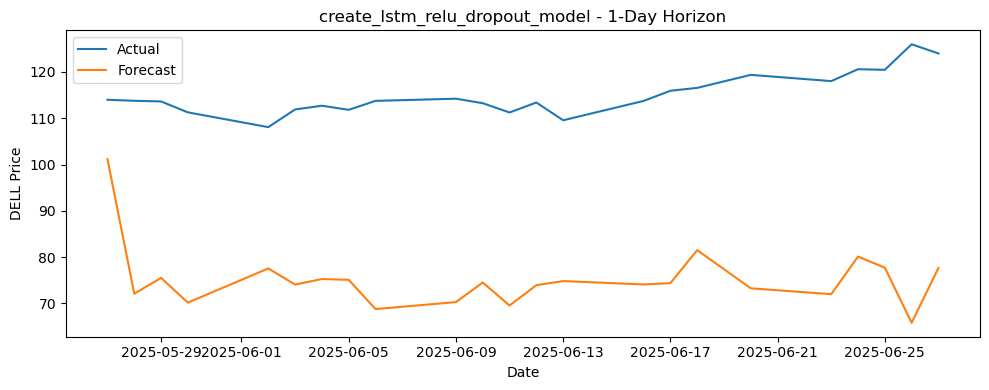

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Horizon 3: RMSE=40.97, MAE=40.66, MAPE=35.25


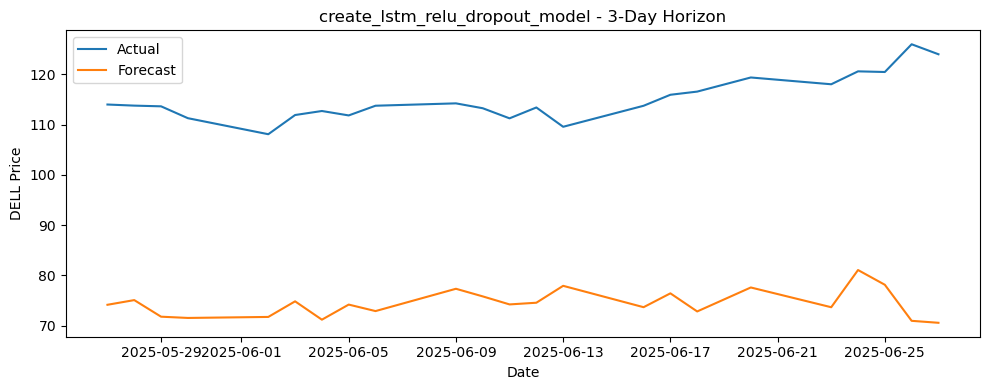

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Horizon 7: RMSE=41.94, MAE=41.49, MAPE=35.94


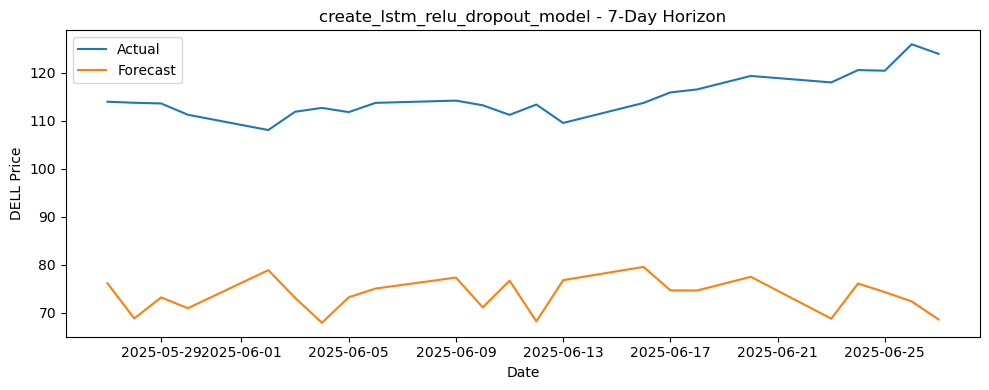


 Saved metrics to lstm_relu_dropout_2025_dell.csv


,model,horizon,rmse,mae,mape
0,create_lstm_relu_dropout_model,1,40.705705,39.903710,34.572215
1,create_lstm_relu_dropout_model,3,40.967930,40.664175,35.246206
2,create_lstm_relu_dropout_model,7,41.936742,41.489429,35.935137


In [144]:
#call this model with early stopping
early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

evaluate_lstm_model(
    df=df,
    model_fn=create_lstm_relu_dropout_model,
    forecast_horizons=[1, 3, 7],
    output_csv_path="lstm_relu_dropout_2025_dell.csv",
    callbacks=[early_stop]
)

Removing dropout and just swapping out relu for tanh in baseline
- trying without early stopping, then with (commenting out)

Without early stopping metrics:
- LSTM (baseline)	1	13.08928465	9.426040136	4.101541786
- LSTM (baseline)	3	14.55810478	10.75792063	4.655816478
- LSTM (baseline)	7	19.38965701	14.05542444	6.030511182

In [147]:
def create_lstm_baseline_model_tanh(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='tanh', input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Horizon 1: RMSE=35.02, MAE=33.97, MAPE=29.54


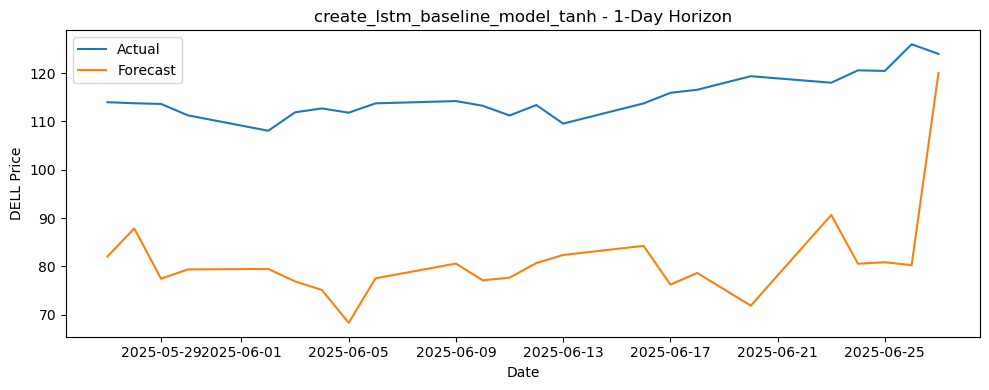

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Horizon 3: RMSE=36.81, MAE=36.09, MAPE=31.25


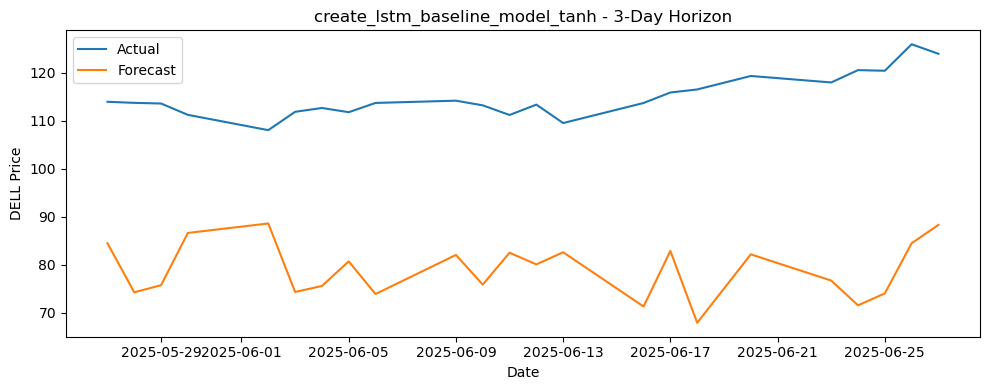

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Horizon 7: RMSE=36.29, MAE=35.31, MAPE=30.65


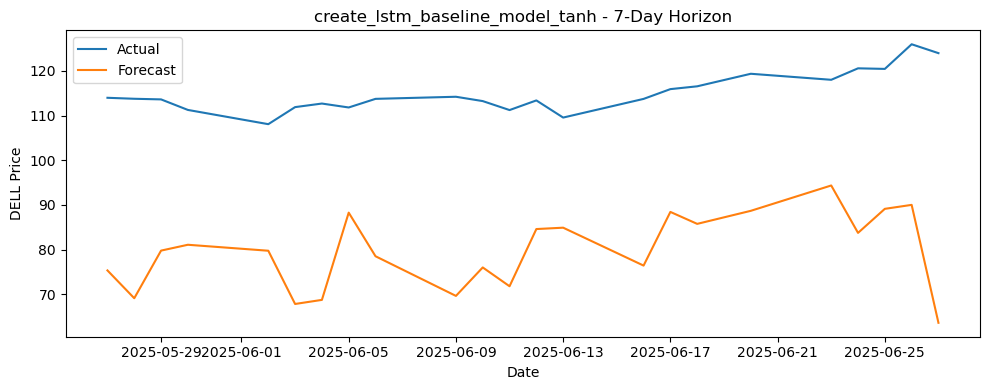


 Saved metrics to lstm_tanh_2025_dell.csv


,model,horizon,rmse,mae,mape
0,create_lstm_baseline_model_tanh,1,35.018707,33.965961,29.541002
1,create_lstm_baseline_model_tanh,3,36.808423,36.086672,31.246240
2,create_lstm_baseline_model_tanh,7,36.291325,35.308052,30.645570


In [148]:
#call this model with early stopping
#early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
#early stopping had better metrics for 7 day forecast but worse for others
evaluate_lstm_model(
    df=df,
    model_fn=create_lstm_baseline_model_tanh,
    forecast_horizons=[1, 3, 7],
    output_csv_path="lstm_tanh_2025_dell.csv",
    callbacks=[early_stop]
)

Trying a deeper model 

In [150]:
"""def create_lstm_deep_model_relu(input_shape):
    model = Sequential()
    model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model"""

"def create_lstm_deep_model_relu(input_shape):\n    model = Sequential()\n    model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=input_shape))\n    model.add(Dropout(0.2))\n    model.add(LSTM(32, activation='relu'))\n    model.add(Dense(1))\n    model.compile(optimizer='adam', loss='mse')\n    return model"

In [151]:
"""early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

evaluate_lstm_model(
    df=df,
    model_fn=create_lstm_deep_model_relu,  
    forecast_horizons=[1, 3, 7],
    output_csv_path="lstm_deep_relu_2025_dell.csv",
    callbacks=[early_stop]
)"""

'early_stop = EarlyStopping(monitor=\'loss\', patience=5, restore_best_weights=True)\n\nevaluate_lstm_model(\n    df=df,\n    model_fn=create_lstm_deep_model_relu,  \n    forecast_horizons=[1, 3, 7],\n    output_csv_path="lstm_deep_relu_2025_dell.csv",\n    callbacks=[early_stop]\n)'

This deeper model in underperfoming compared to the simpler ones i've worked with so far...
I'm going to try it without eary stopping and also
I'm going to swap out relu for tanh and reduce complexity slightly to see if that helps.

In [153]:
"""#early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

evaluate_lstm_model(
    df=df,
    model_fn=create_lstm_deep_model_relu,  
    forecast_horizons=[1, 3, 7],
    output_csv_path="lstm_deep_relu_2025_dell.csv",
    #callbacks=[early_stop]
)"""

'#early_stop = EarlyStopping(monitor=\'loss\', patience=5, restore_best_weights=True)\n\nevaluate_lstm_model(\n    df=df,\n    model_fn=create_lstm_deep_model_relu,  \n    forecast_horizons=[1, 3, 7],\n    output_csv_path="lstm_deep_relu_2025_dell.csv",\n    #callbacks=[early_stop]\n)'

In [154]:
"""def create_lstm_deep_model_small_tanh(input_shape):
    model = Sequential()
    model.add(LSTM(32, activation='tanh', return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.1))
    model.add(LSTM(16, activation='tanh'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model"""

"def create_lstm_deep_model_small_tanh(input_shape):\n    model = Sequential()\n    model.add(LSTM(32, activation='tanh', return_sequences=True, input_shape=input_shape))\n    model.add(Dropout(0.1))\n    model.add(LSTM(16, activation='tanh'))\n    model.add(Dense(1))\n    model.compile(optimizer='adam', loss='mse')\n    return model"

In [155]:
"""early_stop = EarlyStopping(monitor='loss', patience=7, restore_best_weights=True)

evaluate_lstm_model(
    df=df,
    model_fn=create_lstm_deep_model_small_tanh,  
    forecast_horizons=[1, 3, 7],
    output_csv_path="lstm_deep_model_small_tanh_2025_dell.csv",
    callbacks=[early_stop]
)"""

'early_stop = EarlyStopping(monitor=\'loss\', patience=7, restore_best_weights=True)\n\nevaluate_lstm_model(\n    df=df,\n    model_fn=create_lstm_deep_model_small_tanh,  \n    forecast_horizons=[1, 3, 7],\n    output_csv_path="lstm_deep_model_small_tanh_2025_dell.csv",\n    callbacks=[early_stop]\n)'

trying to use keras tuner to speed up process...

In [157]:
#defining tunable model
class LSTMHyperModel(HyperModel):
    def __init__(self, input_shape):
        self.input_shape = input_shape

    def build(self, hp):
        model = Sequential()
        model.add(
            LSTM(
                units=hp.Int("units_1", min_value=16, max_value=128, step=16),
                activation=hp.Choice("activation_1", ["relu", "tanh"]),
                return_sequences=hp.Boolean("return_seq"),
                input_shape=self.input_shape
            )
        )
        if hp.Boolean("add_second_layer"):
            model.add(Dropout(hp.Float("dropout_1", 0.0, 0.4, step=0.1)))
            model.add(
                LSTM(
                    units=hp.Int("units_2", min_value=16, max_value=64, step=16),
                    activation=hp.Choice("activation_2", ["relu", "tanh"]),
                )
            )
        model.add(Dense(1))
        model.compile(
            optimizer="adam",
            loss="mse",
            metrics=["mae"]
        )
        return model

In [158]:
#wrappper for keras tuning

def tune_lstm_model(input_shape):
    tuner = RandomSearch(
        LSTMHyperModel(input_shape),
        objective='val_loss',
        max_trials=10,
        executions_per_trial=1,
        directory='tuning',
        project_name='lstm_tuning',
        seed = seed
    )

    # Dummy data to tune on (required)
    X_dummy = np.random.rand(100, input_shape[0], input_shape[1])
    y_dummy = np.random.rand(100)

    tuner.search(X_dummy, y_dummy, epochs=5, validation_split=0.2, verbose=1)
    
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_model = tuner.hypermodel.build(best_hp)
    return best_model, best_hp

Reloading Tuner from tuning\lstm_tuning\tuner0.json
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Horizon 1: RMSE=4.47, MAE=3.80, MAPE=3.30


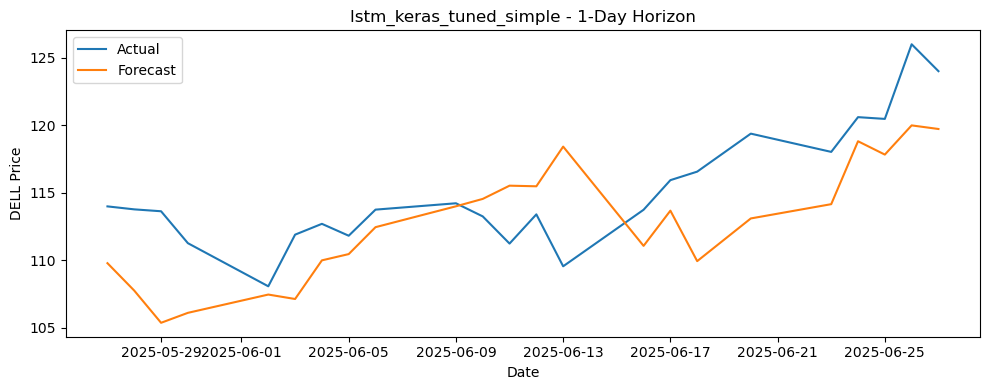

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Horizon 3: RMSE=4.81, MAE=4.09, MAPE=3.50


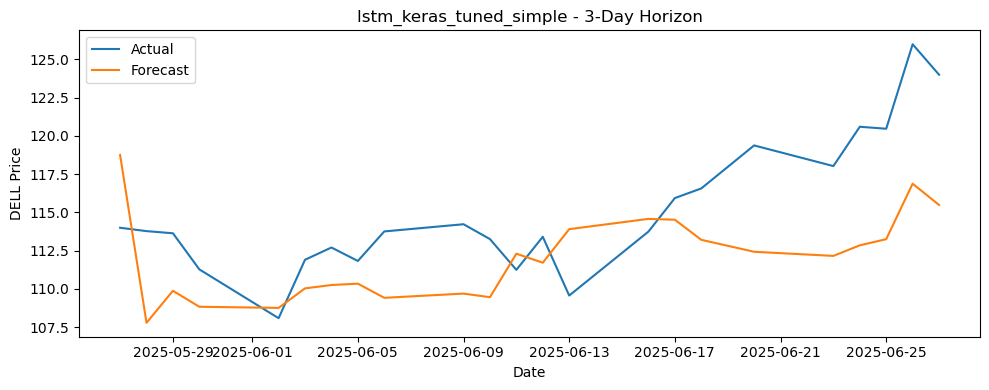

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Horizon 7: RMSE=6.12, MAE=4.99, MAPE=4.26


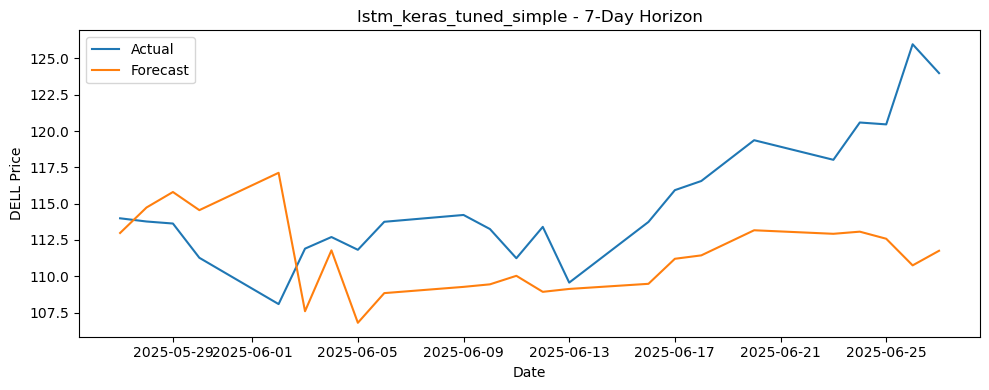


 Saved metrics to lstm_keras_tuner_metrics_2025_dell.csv


,model,horizon,rmse,mae,mape
0,lstm_keras_tuned_simple,1,4.470341,3.801858,3.300196
1,lstm_keras_tuned_simple,3,4.807317,4.094893,3.495919
2,lstm_keras_tuned_simple,7,6.116540,4.991871,4.263289


In [159]:
#adapting evaluating function to accept a pre built model
input_shape = (30, 1)  
best_model_simple, best_hp_simple = tune_lstm_model(input_shape)

#wrapper for passing to evaluator
def lstm_keras_tuned_simple(input_shape):
    return best_model_simple  # Use tuned simple model directly
    
evaluate_lstm_model(
    df=df,
    model_fn=lstm_keras_tuned_simple,  
    forecast_horizons=[1, 3, 7],
    output_csv_path="lstm_keras_tuner_metrics_2025_dell.csv",
    callbacks=[EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)]
)

In [162]:
#defining hypermodel for keras tuner

class LSTMHyperModel(HyperModel):
    def __init__(self, input_shape):
        self.input_shape = input_shape

    def build(self, hp):
        model = Sequential()

        # First LSTM layer
        activation_1 = hp.Choice("activation_1", ["relu", "tanh", "leaky_relu"])
        units_1 = hp.Int("units_1", min_value=16, max_value=128, step=16)
        return_seq = hp.Boolean("return_seq_1")

        if activation_1 == "leaky_relu":
            model.add(LSTM(units_1, activation=None, return_sequences=return_seq, input_shape=self.input_shape))
            model.add(LeakyReLU(alpha=hp.Float("leaky_relu_alpha_1", 0.01, 0.3, step=0.05)))
        else:
            model.add(LSTM(units_1, activation=activation_1, return_sequences=return_seq, input_shape=self.input_shape))

        # second LSTM layer (optional - only if first returns sequences)
        if return_seq and hp.Boolean("add_second_lstm"):
            model.add(Dropout(hp.Float("dropout_1", 0.0, 0.4, step=0.1)))
            units_2 = hp.Int("units_2", min_value=16, max_value=64, step=16)
            activation_2 = hp.Choice("activation_2", ["relu", "tanh", "leaky_relu"])
            if activation_2 == "leaky_relu":
                model.add(LSTM(units_2, activation=None))
                model.add(LeakyReLU(alpha=hp.Float("leaky_relu_alpha_2", 0.01, 0.3, step=0.05)))
            else:
                model.add(LSTM(units_2, activation=activation_2))

        # final dropout (optional)
        if hp.Boolean("add_final_dropout"):
            model.add(Dropout(hp.Float("final_dropout", 0.0, 0.3, step=0.1)))

        #output layer
        model.add(Dense(1))  # Avoided activation=None/linear choice to keep tuner stable

        # Optimizer
        optimizer_name = hp.Choice("optimizer", ["adam", "rmsprop"])
        learning_rate = hp.Float("learning_rate", 1e-5, 1e-2, sampling="log")
        optimizer = optimizers.Adam(learning_rate) if optimizer_name == "adam" else optimizers.RMSprop(learning_rate)

        model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
        return model

In [163]:
#preparing input data
# defining window size
window_size = 30
input_shape = (window_size, 1)

#preparing scaled BA series
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.asfreq("B")
series = df["DELL"].dropna().to_frame()

scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)

# Generate training sequences
X_train, y_train = [], []
for i in range(window_size, int(len(series_scaled) * 0.8)):
    X_train.append(series_scaled[i - window_size:i])
    y_train.append(series_scaled[i][0])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [164]:
# Setup tuner
tuner = RandomSearch(
    LSTMHyperModel(input_shape=(window_size, 1)),
    objective="val_loss",
    max_trials=20,
    executions_per_trial=1,
    directory="lstm_tuning",
    project_name="baseline_tune",
    seed = seed
)

# Run tuning
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
tuner.search(X_train, y_train, validation_split=0.2, epochs=20, callbacks=[early_stop])

# Get best model + hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.hypermodel.build(best_hp)

# Display best config
print("\n Best Hyperparameter Configuration:")
for k, v in best_hp.values.items():
    print(f"{k}: {v}")

Reloading Tuner from lstm_tuning\baseline_tune\tuner0.json

 Best Hyperparameter Configuration:
activation_1: tanh
units_1: 64
return_seq_1: False
add_second_lstm: False
add_final_dropout: True
output_activation: linear
optimizer: adam
learning_rate: 0.006571970090025509
dropout_1: 0.4
units_2: 64
activation_2: relu
leaky_relu_alpha_1: 0.11
final_dropout: 0.2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Horizon 1: RMSE=4.79, MAE=4.04, MAPE=3.46


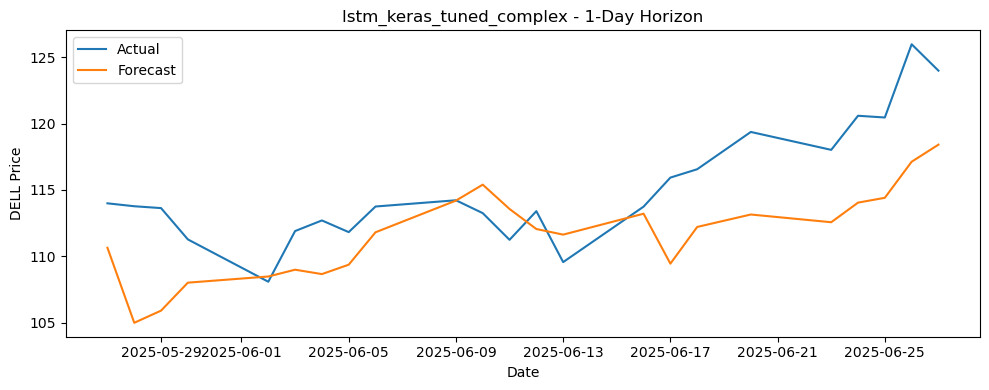

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Horizon 3: RMSE=4.80, MAE=3.67, MAPE=3.12


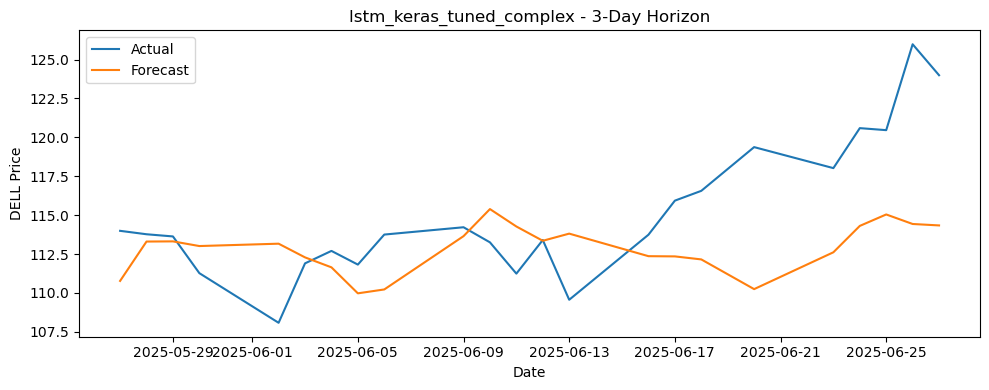

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Horizon 7: RMSE=5.46, MAE=3.75, MAPE=3.16


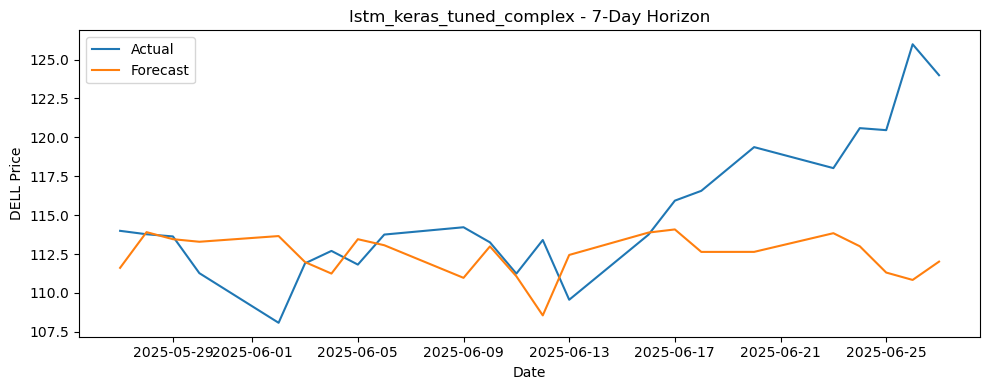


 Saved metrics to lstm_keras_tuned_metrics_2025_dell.csv


,model,horizon,rmse,mae,mape
0,lstm_keras_tuned_complex,1,4.793666,4.037963,3.458896
1,lstm_keras_tuned_complex,3,4.804501,3.673483,3.122785
2,lstm_keras_tuned_complex,7,5.455114,3.749548,3.162328


In [167]:
best_model_complex = tuner.hypermodel.build(best_hp)

# defining model wrapper for evaluator
def lstm_keras_tuned_complex(input_shape):
    return best_model_complex

#evaluate
evaluate_lstm_model(
    df=df,
    model_fn=lstm_keras_tuned_complex,
    forecast_horizons=[1, 3, 7],
    output_csv_path="lstm_keras_tuned_metrics_2025_dell.csv",
    callbacks=[early_stop]
)

In [168]:
#saving best model for use with exo variables later
best_hp = tuner.get_best_hyperparameters(1)[0]

def best_model_fn(input_shape):
    model = LSTMHyperModel(input_shape).build(best_hp)
    return model

In [169]:
# adapting evaluation function to handle exo variables
def evaluate_lstm_model_with_exo(
    df,
    exo_var=None,
    model_fn=None,
    forecast_horizons=[1, 3, 7],
    train_end="2025-05-23",
    test_start="2025-05-27",
    
    window_size=30,
    epochs=20,
    output_csv_path="metrics_2025_dell.csv",
    plot=False, #for now to save memory
    callbacks=None
):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.asfreq("B")
    
    # Subset and drop NA
    features = ["DELL"] + (exo_var if isinstance(exo_var, list) else [exo_var] if exo_var else [])
    df = df[features].dropna()

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(df)

    split_train = df.index <= train_end
    split_test = df.index >= test_start

    all_metrics = []

    for h in forecast_horizons:
        preds, actuals, dates = [], [], []

        for i in range(window_size, len(data_scaled) - h):
            if not split_test[i + h]:
                continue

            X = data_scaled[i - window_size:i].reshape(1, window_size, len(features))
            y = data_scaled[i + h][0]  # BA is target

            X_train_full, y_train_full = [], []
            for j in range(window_size, i):
                X_train_full.append(data_scaled[j - window_size:j])
                y_train_full.append(data_scaled[j][0])  # target is DELL
            X_train_full = np.array(X_train_full)
            y_train_full = np.array(y_train_full)

            model = model_fn((window_size, len(features)))
            model.fit(X_train_full, y_train_full, epochs=epochs, verbose=0, callbacks=callbacks)

            pred_scaled = model.predict(X)[0][0]
            pred = scaler.inverse_transform([[pred_scaled] + [0] * (len(features) - 1)])[0][0]
            actual = df.iloc[i + h]["DELL"]

            preds.append(pred)
            actuals.append(actual)
            dates.append(df.index[i + h])

            # memory cleanup
            del model, X, X_train_full, y_train_full
            K.clear_session()
            gc.collect()
            
        if preds:
            rmse = np.sqrt(mean_squared_error(actuals, preds))
            mae = mean_absolute_error(actuals, preds)
            mape = mean_absolute_percentage_error(actuals, preds)
            print(f"Exo: {exo_var or 'None'} - Horizon {h} -> RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}")

            all_metrics.append({
                "model": model_fn.__name__,
                "exo_var": exo_var or "None",
                "horizon": h,
                "rmse": rmse,
                "mae": mae,
                "mape": mape
            })

            if plot:
                plt.figure(figsize=(10, 4))
                plt.plot(dates, actuals, label="Actual")
                plt.plot(dates, preds, label="Forecast")
                plt.title(f"{exo_var or 'No Exo'} - {h}-Day Horizon")
                plt.xlabel("Date")
                plt.ylabel("DELL Price")
                plt.legend()
                plt.tight_layout()
                plt.show()

    df_metrics = pd.DataFrame(all_metrics)
    df_metrics.to_csv(output_csv_path, index=False)
    print(f"\n Saved metrics to {output_csv_path}")
    return df_metrics

In [170]:
# loop over exo variables one at a time
exo_vars = ['SMH', '^IXIC', 'XLK', 'HG=F', 'CL=F', 'DX-Y.NYB', '^TNX', 'XLY', 'XLI', 'IYT','^VIX']

for var in exo_vars:
    print(f"\n Evaluating with exogenous variable: {var}")
    evaluate_lstm_model_with_exo(
        df=df.copy(),
        exo_var=var,
        model_fn=best_model_fn,
        forecast_horizons=[1, 3, 7],
        output_csv_path=f"metrics_lstm_exo_{var.replace('=', '').replace('^', '').replace('-', '')}_2025_dell.csv",
        callbacks=[early_stop]
    )


 Evaluating with exogenous variable: SMH
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Exo: SMH - Horizon 1 -> RMSE=4.40, MAE=3.61, MAPE=3.13
1/1 ━

In [171]:
#grouping exo variables by type
grouped_exo_vars = {
    "sectoral": ["SMH", "^IXIC", "XLK"],
    "macroeconomic": ["DX-Y.NYB", "^TNX", "^VIX", "XLY", "XLI"],
    "supply_chain_and_commodities": ["HG=F", "CL=F", "IYT"]
}

In [172]:
#loop for evauating grouped variables
for group_name, var_list in grouped_exo_vars.items():
    print(f"\n Evaluating group: {group_name} with variables: {var_list}")
    
    evaluate_lstm_model_with_exo(
        df=df.copy(),
        exo_var=var_list,  # List of multiple variables
        model_fn=best_model_fn,
        forecast_horizons=[1], #trying one horizon at a time to deal with memory error
        output_csv_path=f"metrics_lstm_group_{group_name}_horizon_1_2025_dell.csv",
        callbacks=[early_stop]
    )


 Evaluating group: sectoral with variables: ['SMH', '^IXIC', 'XLK']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
Exo: ['SMH', '^IXIC', 'XLK'] - Hor

In [173]:
#loop for evauating grouped variables
for group_name, var_list in grouped_exo_vars.items():
    print(f"\n Evaluating group: {group_name} with variables: {var_list}")
    
    evaluate_lstm_model_with_exo(
        df=df.copy(),
        exo_var=var_list,  # List of multiple variables
        model_fn=best_model_fn,
        forecast_horizons=[3],
        output_csv_path=f"metrics_lstm_group_{group_name}_horizon_3_2025_dell.csv",
        callbacks=[early_stop]
    )


 Evaluating group: sectoral with variables: ['SMH', '^IXIC', 'XLK']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
Exo: ['SMH', '^IXIC', 'XLK'] - Hor

In [174]:
#loop for evauating grouped variables
for group_name, var_list in grouped_exo_vars.items():
    print(f"\n Evaluating group: {group_name} with variables: {var_list}")
    
    evaluate_lstm_model_with_exo(
        df=df.copy(),
        exo_var=var_list,  # List of multiple variables
        model_fn=best_model_fn,
        forecast_horizons=[7],
        output_csv_path=f"metrics_lstm_group_{group_name}_horizon_7_2025_dell.csv",
        callbacks=[early_stop]
    )


 Evaluating group: sectoral with variables: ['SMH', '^IXIC', 'XLK']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
Exo: ['SMH', '^IXIC', 'XLK'] - Hor

### Getting best score from each exo variable type to include as exo variables 

In [176]:
# Defining the variables again to loop through
exo_vars = ['SMH', '^IXIC', 'XLK', 'HG=F', 'CL=F', 'DX-Y.NYB', '^TNX', 'XLY', 'XLI', 'IYT','^VIX']

combined_dfs = []

for var in exo_vars:
    safe_var = var.replace("=", "").replace("^", "").replace("-", "")
    filename = f"metrics_lstm_exo_{safe_var}_2025_dell.csv"

    if os.path.exists(filename):
        df_temp = pd.read_csv(filename)
        df_temp["exo_var"] = var  # adding the original exogenous variable name
        combined_dfs.append(df_temp)
    else:
        print(f"Missing: {filename}")

# Combine and save
if combined_dfs:
    df_all = pd.concat(combined_dfs, ignore_index=True)
    df_all.to_csv("metrics_lstm_all_exo_combined_2025_dell.csv", index=False) 
    print("Combined results saved to: metrics_lstm_all_exo_combined_2025_dell.csv")
else:
    print("No data to combine.")

Combined results saved to: metrics_lstm_all_exo_combined_2025_dell.csv


In [177]:
df_all = df_all.drop_duplicates(subset=["exo_var", "horizon"])

#print best inputs
df_all.sort_values(by="mape").groupby("horizon").first()

,model,exo_var,rmse,mae,mape
horizon,,,,,
1,best_model_fn,DX-Y.NYB,3.420290,3.003857,2.597004
3,best_model_fn,DX-Y.NYB,4.507129,3.543805,3.029947
7,best_model_fn,DX-Y.NYB,5.292317,4.044586,3.424494


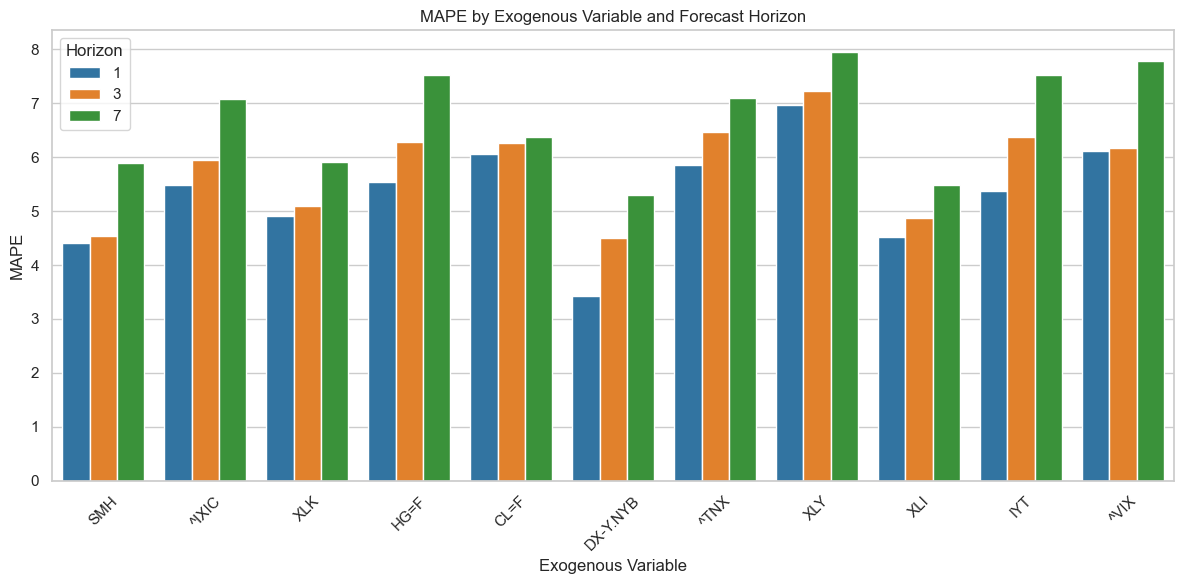

In [196]:
#plotting to compare across multiple horizons

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_all,
    x="exo_var",
    y="rmse",
    hue="horizon",
    palette="tab10"
)
plt.title("MAPE by Exogenous Variable and Forecast Horizon")
plt.xlabel("Exogenous Variable")
plt.ylabel("MAPE")
plt.legend(title="Horizon")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

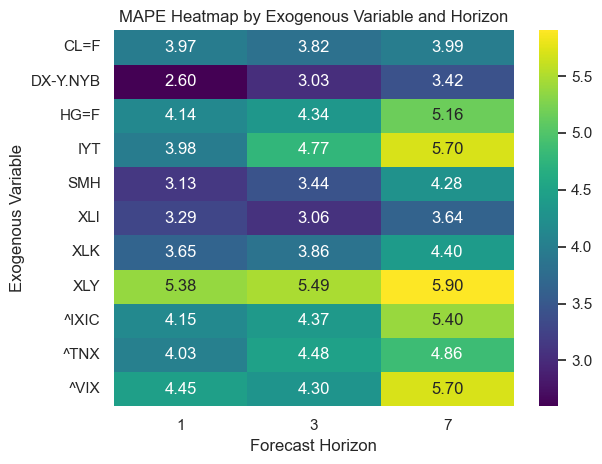

In [198]:
#heatmap
pivot = df_all.pivot(index="exo_var", columns="horizon", values="mape")
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title("MAPE Heatmap by Exogenous Variable and Horizon")
plt.ylabel("Exogenous Variable")
plt.xlabel("Forecast Horizon")
plt.tight_layout()
plt.show()

In [200]:
# mapping labels to tickers
label_mapping = {
    "sectoral": ["SMH", "^IXIC", "XLK"],
    "macroeconomic": ["DX-Y.NYB", "^TNX", "^VIX", "XLY", "XLI"],
    "supply_chain_and_commodities": ["HG=F", "CL=F", "IYT"]
}

# inverting the mapping to map each ticker to its category
ticker_to_category = {ticker: label for label, tickers in label_mapping.items() for ticker in tickers}

# assigning the category to each row
df_all["category"] = df_all["exo_var"].map(ticker_to_category)

# Save the updated DataFrame with category column to a new CSV
df_all.to_csv("metrics_with_categories_2025_dell.csv", index=False)

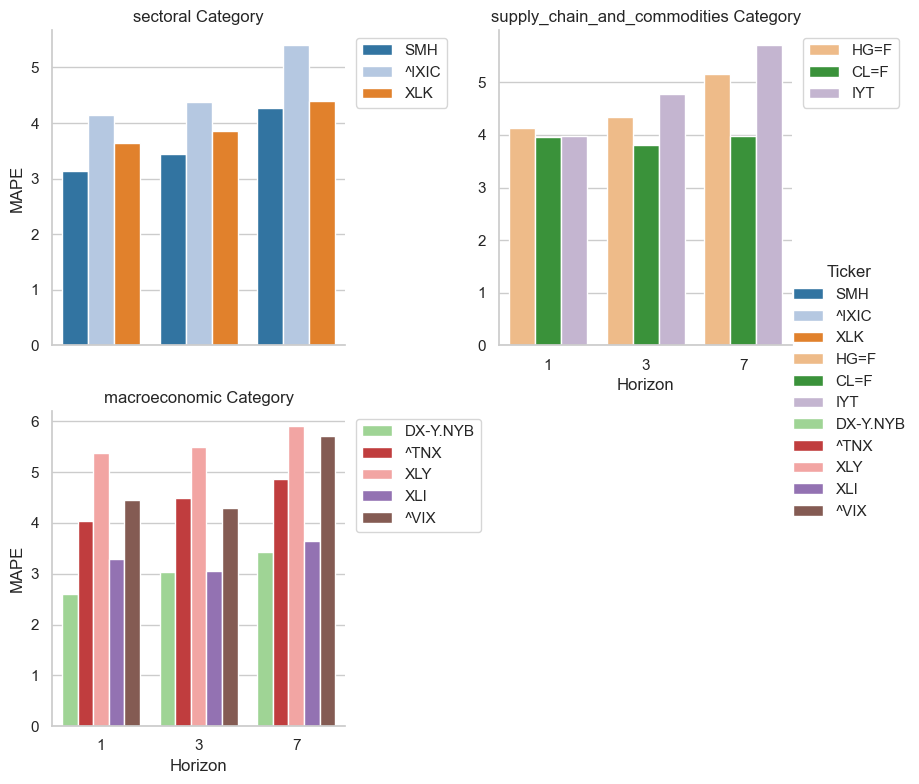

In [202]:
# setting style
sns.set(style="whitegrid")

# using unique color for each ticker
unique_tickers = df_all["exo_var"].unique()
palette = sns.color_palette("tab20", n_colors=len(unique_tickers))
color_map = dict(zip(unique_tickers, palette))

# FacetGrid creation
g = sns.FacetGrid(df_all, col="category", col_wrap=2, height=4, sharey=False)

# plot
g.map_dataframe(
    sns.barplot,
    x="horizon", y="mape", hue="exo_var",
    palette=color_map,
    errorbar=None
)

# key
g.add_legend(title="Ticker")
for ax in g.axes.flatten():
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

# Set axis labels and titles
g.set_axis_labels("Horizon", "MAPE")
g.set_titles(col_template="{col_name} Category")
plt.tight_layout()
plt.show()


## Choose best of

In [204]:
# best from each category identified - defining list to use in model
best_exo_by_horizon = {
    1: ["SMH", "CL=F", "DX-Y.NYB"],
    3: ["SMH", "CL=F", "DX-Y.NYB"],
    7: ["SMH", "CL=F", "DX-Y.NYB"]
}

In [206]:
#loop for evauating best of each categories variables combined
for group_name, var_list in grouped_exo_vars.items():
    print(f"\n Evaluating best exogenous variables for horizon 1 with variables: SMH, CL=F, DX-Y.NYB")
    
    evaluate_lstm_model_with_exo(
        df=df.copy(),
        exo_var=["SMH", "CL=F", "DX-Y.NYB"],  # List of multiple variables
        model_fn=best_model_fn,
        forecast_horizons=[1], #trying one horizon at a time to deal with memory error
        output_csv_path=f"metrics_lstm_bestof_horizon_1_2025_dell.csv",
        callbacks=[early_stop]
    )


 Evaluating best exogenous variables for horizon 1 with variables: SMH, CL=F, DX-Y.NYB
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
Exo: ['SMH', 'C

In [207]:
#horizon 3
for group_name, var_list in grouped_exo_vars.items():
    print(f"\n Evaluating best exogenous variables for horizon 3 with variables: SMH, CL=F, DXY.NYB ")
    
    evaluate_lstm_model_with_exo(
        df=df.copy(),
        exo_var=["SMH", "CL=F", "DX-Y.NYB"],  # List of multiple variables
        model_fn=best_model_fn,
        forecast_horizons=[3], #trying one horizon at a time to deal with memory error
        output_csv_path=f"metrics_lstm_bestof_horizon_3_2025_dell.csv",
        callbacks=[early_stop]
    )


 Evaluating best exogenous variables for horizon 3 with variables: SMH, CL=F, DXY.NYB 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
Exo: ['SMH', 'C

In [208]:
for group_name, var_list in grouped_exo_vars.items():
    print(f"\n Evaluating best exogenous variables for horizon 7 with variables: SMH, CL=F, DX-Y.NYB")
    
    evaluate_lstm_model_with_exo(
        df=df.copy(),
        exo_var=["SMH", "CL=F", "DX-Y.NYB"],  # List of multiple variables
        model_fn=best_model_fn,
        forecast_horizons=[7], #trying one horizon at a time to deal with memory error
        output_csv_path=f"metrics_lstm_bestof_horizon_7_2025_dell.csv",
        callbacks=[early_stop]
    )


 Evaluating best exogenous variables for horizon 7 with variables: SMH, CL=F, DX-Y.NYB
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
Exo: ['SMH', 'C

should've removed the for loop at the start of the "best of" run, just ran the same thing three times unnecessarily